<a href="https://colab.research.google.com/github/Mohanbabu82/Uncertainty-Governed-Agentic-AI-for-Safety-Critical-Predictive-Maintenance/blob/main/notebooks/FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

bishals098_nasa_turbofan_engine_degradation_simulation_path = kagglehub.dataset_download('bishals098/nasa-turbofan-engine-degradation-simulation')
mohanbabu28_maintenance_of_naval_propulsion_plants_data_set1_path = kagglehub.dataset_download('mohanbabu28/maintenance-of-naval-propulsion-plants-data-set1')
elikplim_maintenance_of_naval_propulsion_plants_data_set_path = kagglehub.dataset_download('elikplim/maintenance-of-naval-propulsion-plants-data-set')

print('Data source import complete.')


In [ ]:

import os
import glob
import numpy as np
import pandas as pd

# ============================================================
# 1. PATHS
# ============================================================

NASA_PATH = (
    "/kaggle/input/datasets/"
    "bishals098/nasa-turbofan-engine-degradation-simulation"
)

OUTPUT_PATH = "/kaggle/working/Unified_Propulsion_Dataset.csv"

# ============================================================
# 2. NASA C-MAPSS COLUMNS
# ============================================================

CMAPSS_COLUMNS = [
    "unit",
    "cycle",
    "setting1",
    "setting2",
    "setting3"
]

CMAPSS_COLUMNS += [
    f"sensor{i}"
    for i in range(1, 22)
]


# ============================================================
# 3. LOAD C-MAPSS
# ============================================================

def load_cmapss(path):

    return pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=CMAPSS_COLUMNS,
        engine="python"
    )


# ============================================================
# 4. ADD RUL TO TRAINING DATA
# ============================================================

def add_training_rul(df):

    df = df.copy()

    max_cycle = (
        df.groupby("unit")["cycle"]
        .max()
        .reset_index()
    )

    max_cycle.columns = [
        "unit",
        "max_cycle"
    ]

    df = df.merge(
        max_cycle,
        on="unit",
        how="left"
    )

    df["RUL"] = (
        df["max_cycle"]
        - df["cycle"]
    )

    df.drop(
        columns=["max_cycle"],
        inplace=True
    )

    return df


# ============================================================
# 5. LOAD NASA DATA
# ============================================================

print("Loading NASA C-MAPSS...")

train_fd001 = load_cmapss(
    os.path.join(
        NASA_PATH,
        "train_FD001.txt"
    )
)

train_fd003 = load_cmapss(
    os.path.join(
        NASA_PATH,
        "train_FD003.txt"
    )
)

train_fd001 = add_training_rul(
    train_fd001
)

train_fd003 = add_training_rul(
    train_fd003
)


# ============================================================
# 6. NASA DOMAIN INFORMATION
# ============================================================

train_fd001["source_dataset"] = (
    "NASA_CMAPSS_FD001"
)

train_fd001["domain"] = "SOURCE"

train_fd003["source_dataset"] = (
    "NASA_CMAPSS_FD003"
)

train_fd003["domain"] = "TARGET"


# ============================================================
# 7. STANDARDIZE NASA IDENTIFICATION
# ============================================================

train_fd001["engine_id"] = (
    "FD001_" +
    train_fd001["unit"].astype(str)
)

train_fd003["engine_id"] = (
    "FD003_" +
    train_fd003["unit"].astype(str)
)


# ============================================================
# 8. CREATE COMMON NASA ATTRIBUTES
# ============================================================

def prepare_nasa(df):

    df = df.copy()

    # Common identification
    df["timestamp"] = pd.NaT

    # Operating information
    df["rpm"] = np.nan
    df["torque"] = np.nan
    df["load"] = np.nan

    df["mission_profile"] = (
        "C-MAPSS"
    )

    df["operating_condition"] = (
        df["setting1"].astype(str)
        + "_"
        + df["setting2"].astype(str)
        + "_"
        + df["setting3"].astype(str)
    )

    # Vibration
    df["vibration_x"] = np.nan
    df["vibration_y"] = np.nan
    df["vibration_z"] = np.nan

    # Temperature
    df["ambient_temperature"] = np.nan
    df["compressor_temperature"] = np.nan
    df["turbine_temperature"] = np.nan
    df["exhaust_temperature"] = np.nan

    # Pressure
    df["inlet_pressure"] = np.nan
    df["compressor_pressure"] = np.nan
    df["turbine_pressure"] = np.nan

    # Flow
    df["fuel_flow"] = np.nan
    df["lube_oil_flow"] = np.nan
    df["lube_oil_temperature"] = np.nan

    # Degradation
    df["compressor_decay"] = np.nan
    df["turbine_decay"] = np.nan

    # Maintenance
    df["maintenance_event"] = (
        "UNKNOWN"
    )

    df["maintenance_type"] = (
        "UNKNOWN"
    )

    # Failure
    df["failure_flag"] = (
        df["RUL"] <= 0
    ).astype(int)

    df["failure_type"] = (
        "END_OF_LIFE"
    )

    df["failure_history"] = np.nan

    # Health
    df["health_index"] = (
        df["RUL"] /
        (df["RUL"].max() + 1e-8)
    )

    # Degradation stage
    df["degradation_stage"] = (
        df["RUL"].apply(
            lambda x:
            "HEALTHY"
            if x > 100
            else
            "EARLY_DEGRADATION"
            if x > 50
            else
            "DEGRADATION"
            if x > 20
            else
            "CRITICAL"
        )
    )

    # Fault class
    df["fault_class"] = (
        df["degradation_stage"]
        .map({
            "HEALTHY":
                "NORMAL_OPERATION",

            "EARLY_DEGRADATION":
                "DEGRADATION",

            "DEGRADATION":
                "DEGRADATION",

            "CRITICAL":
                "CRITICAL_DEGRADATION"
        })
    )

    return df


train_fd001 = prepare_nasa(
    train_fd001
)

train_fd003 = prepare_nasa(
    train_fd003
)


# ============================================================
# 9. FIND UCI DATASET
# ============================================================

print("\nSearching for UCI Naval Propulsion dataset...")

possible_files = []

for root, dirs, files in os.walk(
    "/kaggle/input"
):

    for file in files:

        lower = file.lower()

        if (
            lower.endswith(".csv")
            or lower.endswith(".txt")
            or lower.endswith(".xlsx")
        ):

            if (
                "naval" in lower
                or "propulsion" in lower
                or "condition" in lower
            ):

                possible_files.append(
                    os.path.join(
                        root,
                        file
                    )
                )


print(
    "\nPossible UCI files:"
)

for file in possible_files:

    print(file)


# ============================================================
# 10. LOAD UCI DATASET
# ============================================================

if len(possible_files) == 0:

    print(
        "\nWARNING:"
    )

    print(
        "UCI Naval Propulsion dataset "
        "was not found."
    )

    print(
        "Upload/add the UCI dataset to "
        "Kaggle and run this cell again."
    )

    uci = pd.DataFrame()

else:

    UCI_FILE = possible_files[0]

    print(
        "\nUsing UCI file:"
    )

    print(UCI_FILE)

    if UCI_FILE.endswith(".csv"):

        uci = pd.read_csv(
            UCI_FILE
        )

    elif UCI_FILE.endswith(".xlsx"):

        uci = pd.read_excel(
            UCI_FILE
        )

    else:

        uci = pd.read_csv(
            UCI_FILE,
            sep=None,
            engine="python"
        )

    print(
        "\nUCI shape:",
        uci.shape
    )

    print(
        "\nUCI columns:"
    )

    print(
        uci.columns.tolist()
    )


# ============================================================
# 11. STANDARDIZE UCI COLUMN NAMES
# ============================================================

if not uci.empty:

    uci.columns = [
        str(c)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        for c in uci.columns
    ]


# ============================================================
# 12. CREATE COMMON UCI SCHEMA
# ============================================================

if not uci.empty:

    common = pd.DataFrame(
        index=uci.index
    )

    # --------------------------------------------------------
    # Identification
    # --------------------------------------------------------

    common["engine_id"] = (
        "UCI_" +
        uci.index.astype(str)
    )

    common["timestamp"] = pd.NaT

    common["cycle"] = (
        np.arange(
            len(uci)
        )
    )

    # --------------------------------------------------------
    # Helper for finding columns
    # --------------------------------------------------------

    def find_column(
        keywords
    ):

        for col in uci.columns:

            for keyword in keywords:

                if keyword in col:

                    return uci[col]

        return pd.Series(
            np.nan,
            index=uci.index
        )

    # --------------------------------------------------------
    # Vibration
    # --------------------------------------------------------

    common["vibration_x"] = (
        find_column(
            [
                "vibration",
                "vib"
            ]
        )
    )

    common["vibration_y"] = np.nan
    common["vibration_z"] = np.nan

    # --------------------------------------------------------
    # Temperature
    # --------------------------------------------------------

    common["ambient_temperature"] = (
        find_column(
            [
                "ambient",
                "environment"
            ]
        )
    )

    common["compressor_temperature"] = (
        find_column(
            [
                "compressor_temp",
                "compressor_temperature"
            ]
        )
    )

    common["turbine_temperature"] = (
        find_column(
            [
                "turbine_temp",
                "turbine_temperature"
            ]
        )
    )

    common["exhaust_temperature"] = (
        find_column(
            [
                "exhaust_temp",
                "exhaust_temperature"
            ]
        )
    )

    # --------------------------------------------------------
    # Pressure
    # --------------------------------------------------------

    common["inlet_pressure"] = (
        find_column(
            [
                "inlet_pressure",
                "inlet_press"
            ]
        )
    )

    common["compressor_pressure"] = (
        find_column(
            [
                "compressor_pressure",
                "compressor_press"
            ]
        )
    )

    common["turbine_pressure"] = (
        find_column(
            [
                "turbine_pressure",
                "turbine_press"
            ]
        )
    )

    # --------------------------------------------------------
    # RPM
    # --------------------------------------------------------

    common["rpm"] = (
        find_column(
            [
                "rpm",
                "speed",
                "shaft_speed"
            ]
        )
    )

    # --------------------------------------------------------
    # Torque
    # --------------------------------------------------------

    common["torque"] = (
        find_column(
            [
                "torque"
            ]
        )
    )

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    common["load"] = (
        find_column(
            [
                "load"
            ]
        )
    )

    # --------------------------------------------------------
    # Fuel flow
    # --------------------------------------------------------

    common["fuel_flow"] = (
        find_column(
            [
                "fuel_flow",
                "fuel"
            ]
        )
    )

    # --------------------------------------------------------
    # Lube oil
    # --------------------------------------------------------

    common["lube_oil_flow"] = (
        find_column(
            [
                "lube_oil_flow",
                "oil_flow",
                "lubricant"
            ]
        )
    )

    common["lube_oil_temperature"] = (
        find_column(
            [
                "lube_oil_temperature",
                "oil_temperature"
            ]
        )
    )

    # --------------------------------------------------------
    # Compressor / turbine degradation
    # --------------------------------------------------------

    common["compressor_decay"] = (
        find_column(
            [
                "compressor_decay",
                "compressor_decay_coefficient",
                "compressor"
            ]
        )
    )

    common["turbine_decay"] = (
        find_column(
            [
                "turbine_decay",
                "turbine_decay_coefficient",
                "turbine"
            ]
        )
    )

    # --------------------------------------------------------
    # Operating profile
    # --------------------------------------------------------

    common["mission_profile"] = (
        "UCI_NAVAL"
    )

    common["operating_condition"] = (
        find_column(
            [
                "operating_condition",
                "condition"
            ]
        )
    )

    # --------------------------------------------------------
    # Maintenance
    # --------------------------------------------------------

    common["maintenance_event"] = (
        find_column(
            [
                "maintenance_event",
                "maintenance"
            ]
        )
    )

    common["maintenance_type"] = (
        find_column(
            [
                "maintenance_type"
            ]
        )
    )

    # --------------------------------------------------------
    # Failure
    # --------------------------------------------------------

    common["failure_flag"] = (
        find_column(
            [
                "failure_flag",
                "failure"
            ]
        )
    )

    common["failure_type"] = (
        find_column(
            [
                "failure_type"
            ]
        )
    )

    common["failure_history"] = (
        find_column(
            [
                "failure_history"
            ]
        )
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    common["RUL"] = (
        find_column(
            [
                "rul",
                "remaining_useful_life"
            ]
        )
    )

    common["health_index"] = (
        find_column(
            [
                "health_index",
                "health"
            ]
        )
    )

    common["degradation_stage"] = (
        find_column(
            [
                "degradation_stage",
                "degradation"
            ]
        )
    )

    common["fault_class"] = (
        find_column(
            [
                "fault_class",
                "fault"
            ]
        )
    )

    # --------------------------------------------------------
    # Source
    # --------------------------------------------------------

    common["source_dataset"] = (
        "UCI_NAVAL"
    )

    common["domain"] = (
        "TARGET"
    )

    # --------------------------------------------------------
    # NASA sensors don't directly exist
    # --------------------------------------------------------

    for i in range(1, 22):

        common[
            f"sensor{i}"
        ] = np.nan

    uci_common = common

else:

    uci_common = pd.DataFrame()


# ============================================================
# 13. SELECT NASA COMMON COLUMNS
# ============================================================

COMMON_COLUMNS = [

    "engine_id",
    "timestamp",
    "cycle",

    "rpm",
    "torque",
    "load",

    "vibration_x",
    "vibration_y",
    "vibration_z",

    "ambient_temperature",
    "compressor_temperature",
    "turbine_temperature",
    "exhaust_temperature",

    "inlet_pressure",
    "compressor_pressure",
    "turbine_pressure",

    "fuel_flow",
    "lube_oil_flow",
    "lube_oil_temperature",

    "compressor_decay",
    "turbine_decay",

    "mission_profile",
    "operating_condition",

    "maintenance_event",
    "maintenance_type",

    "failure_flag",
    "failure_type",
    "failure_history",

    "health_index",
    "degradation_stage",
    "fault_class",

    "RUL",

    "source_dataset",
    "domain"
]


for i in range(1, 22):

    COMMON_COLUMNS.append(
        f"sensor{i}"
    )


# ============================================================
# 14. PREPARE NASA COMMON DATA
# ============================================================

def select_common_columns(df):

    output = pd.DataFrame()

    for col in COMMON_COLUMNS:

        if col in df.columns:

            output[col] = df[col]

        else:

            output[col] = np.nan

    return output


nasa_fd001_common = (
    select_common_columns(
        train_fd001
    )
)

nasa_fd003_common = (
    select_common_columns(
        train_fd003
    )
)


# ============================================================
# 15. MERGE NASA + UCI
# ============================================================

print(
    "\nCreating unified dataset..."
)

datasets = [
    nasa_fd001_common,
    nasa_fd003_common
]

if not uci_common.empty:

    uci_common = (
        select_common_columns(
            uci_common
        )
    )

    datasets.append(
        uci_common
    )


unified_dataset = pd.concat(
    datasets,
    ignore_index=True
)


# ============================================================
# 16. SORT DATA
# ============================================================

unified_dataset = (
    unified_dataset
    .reset_index(drop=True)
)


# ============================================================
# 17. NUMERIC CLEANING
# ============================================================

numeric_columns = (
    unified_dataset
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

for col in numeric_columns:

    unified_dataset[col] = (
        pd.to_numeric(
            unified_dataset[col],
            errors="coerce"
        )
    )


# ============================================================
# 18. REMOVE DUPLICATES
# ============================================================

unified_dataset = (
    unified_dataset
    .drop_duplicates()
    .reset_index(drop=True)
)


# ============================================================
# 19. SAVE CSV
# ============================================================

unified_dataset.to_csv(
    OUTPUT_PATH,
    index=False
)


# ============================================================
# 20. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("UNIFIED DATASET CREATED")
print("=" * 70)

print(
    "\nFile:"
)

print(
    OUTPUT_PATH
)

print(
    "\nShape:"
)

print(
    unified_dataset.shape
)

print(
    "\nSource distribution:"
)

print(
    unified_dataset[
        "source_dataset"
    ].value_counts()
)

print(
    "\nDomain distribution:"
)

print(
    unified_dataset[
        "domain"
    ].value_counts()
)

print(
    "\nColumns:"
)

for col in unified_dataset.columns:

    print(
        " -",
        col
    )

print(
    "\nFirst 10 rows:"
)

display(
    unified_dataset.head(10)
)

print(
    "\nCSV successfully created!"
)

Loading NASA C-MAPSS...

Searching for UCI Naval Propulsion dataset...

Possible UCI files:
/kaggle/input/datasets/mohanbabu28/maintenance-of-naval-propulsion-plants-data-set1/navalplantmaintenance.csv

Using UCI file:
/kaggle/input/datasets/mohanbabu28/maintenance-of-naval-propulsion-plants-data-set1/navalplantmaintenance.csv

UCI shape: (11933, 1)

UCI columns:
['   1.1380000e+00   3.0000000e+00   2.8996400e+02   1.3494890e+03   6.6773800e+03   7.5840000e+00   7.5840000e+00   4.6400600e+02   2.8800000e+02   5.5056300e+02   1.0960000e+00   9.9800000e-01   5.9470000e+00   1.0190000e+00   7.1370000e+00   8.2000000e-02   9.5000000e-01   9.7500000e-01']

Creating unified dataset...

UNIFIED DATASET CREATED

File:
/kaggle/working/Unified_Propulsion_Dataset.csv

Shape:
(57284, 55)

Source distribution:
source_dataset
NASA_CMAPSS_FD003    24720
NASA_CMAPSS_FD001    20631
UCI_NAVAL            11933
Name: count, dtype: int64

Domain distribution:
domain
TARGET    36653
SOURCE    20631
Name: co

,engine_id,timestamp,cycle,rpm,torque,load,vibration_x,vibration_y,vibration_z,ambient_temperature,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,FD001_1,NaT,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,521.66,2388.02,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190
1,FD001_1,NaT,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,522.28,2388.07,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236
2,FD001_1,NaT,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,522.42,2388.03,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442
3,FD001_1,NaT,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,522.86,2388.08,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739
4,FD001_1,NaT,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,522.19,2388.04,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044
5,FD001_1,NaT,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,521.68,2388.03,8132.85,8.4108,0.03,391.0,2388.0,100.0,38.98,23.3669
6,FD001_1,NaT,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,522.32,2388.03,8132.32,8.3974,0.03,392.0,2388.0,100.0,39.10,23.3774
7,FD001_1,NaT,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,522.47,2388.03,8131.07,8.4076,0.03,391.0,2388.0,100.0,38.97,23.3106
8,FD001_1,NaT,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,521.79,2388.05,8125.69,8.3728,0.03,392.0,2388.0,100.0,39.05,23.4066
9,FD001_1,NaT,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,521.79,2388.06,8129.38,8.4286,0.03,393.0,2388.0,100.0,38.95,23.4694



CSV successfully created!


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bishals098/nasa-turbofan-engine-degradation-simulation")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation


In [ ]:
# ============================================================
# NASA C-MAPSS + UCI NAVAL
# AUTOMATIC PATH VERSION
# ============================================================

import os
import glob
import pandas as pd
import numpy as np

print("=" * 70)
print("SEARCHING KAGGLE DATASET FILES")
print("=" * 70)

# ============================================================
# 1. AUTOMATICALLY FIND FILE
# ============================================================

def find_file(filename):

    matches = glob.glob(
        f"/kaggle/input/**/{filename}",
        recursive=True
    )

    if len(matches) == 0:

        raise FileNotFoundError(
            f"\nCould not find {filename}\n\n"
            "Please check that the Kaggle dataset "
            "has been added to this notebook."
        )

    print(
        f"FOUND {filename}:"
    )

    print(
        matches[0]
    )

    return matches[0]


# ============================================================
# 2. FIND NASA FILES
# ============================================================

TRAIN_FD001 = find_file(
    "train_FD001.txt"
)

TEST_FD001 = find_file(
    "test_FD001.txt"
)

RUL_FD001 = find_file(
    "RUL_FD001.txt"
)

TRAIN_FD003 = find_file(
    "train_FD003.txt"
)

TEST_FD003 = find_file(
    "test_FD003.txt"
)

RUL_FD003 = find_file(
    "RUL_FD003.txt"
)


# ============================================================
# 3. C-MAPSS COLUMN NAMES
# ============================================================

COLUMN_NAMES = [
    "unit",
    "cycle",
    "setting1",
    "setting2",
    "setting3"
]

COLUMN_NAMES += [
    f"sensor{i}"
    for i in range(1, 22)
]


# ============================================================
# 4. LOAD C-MAPSS
# ============================================================

def load_cmapss(path):

    df = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=COLUMN_NAMES,
        engine="python"
    )

    return df


print("\nLoading C-MAPSS...")

train_fd001 = load_cmapss(
    TRAIN_FD001
)

test_fd001 = load_cmapss(
    TEST_FD001
)

train_fd003 = load_cmapss(
    TRAIN_FD003
)

test_fd003 = load_cmapss(
    TEST_FD003
)

rul_fd001 = pd.read_csv(
    RUL_FD001,
    header=None,
    names=["RUL"]
)

rul_fd003 = pd.read_csv(
    RUL_FD003,
    header=None,
    names=["RUL"]
)


# ============================================================
# 5. DISPLAY DATASET SIZE
# ============================================================

print("\nDataset sizes:")

print(
    "FD001 Train:",
    train_fd001.shape
)

print(
    "FD001 Test:",
    test_fd001.shape
)

print(
    "FD003 Train:",
    train_fd003.shape
)

print(
    "FD003 Test:",
    test_fd003.shape
)


# ============================================================
# 6. ADD TRAINING RUL
# ============================================================

def add_training_rul(df):

    df = df.copy()

    max_cycle = (
        df.groupby("unit")["cycle"]
        .max()
        .reset_index()
    )

    max_cycle.columns = [
        "unit",
        "max_cycle"
    ]

    df = df.merge(
        max_cycle,
        on="unit",
        how="left"
    )

    df["RUL"] = (
        df["max_cycle"]
        - df["cycle"]
    )

    df.drop(
        columns=["max_cycle"],
        inplace=True
    )

    return df


train_fd001 = add_training_rul(
    train_fd001
)

train_fd003 = add_training_rul(
    train_fd003
)


# ============================================================
# 7. ADD TEST RUL
# ============================================================

def add_test_rul(
    test_df,
    rul_df
):

    df = test_df.copy()

    rul_values = (
        rul_df["RUL"]
        .values
    )

    units = sorted(
        df["unit"].unique()
    )

    if len(units) != len(rul_values):

        raise ValueError(
            "Test engines and RUL values "
            "do not match."
        )

    rul_map = dict(
        zip(
            units,
            rul_values
        )
    )

    df["final_RUL"] = (
        df["unit"]
        .map(rul_map)
    )

    max_cycle = (
        df.groupby("unit")["cycle"]
        .transform("max")
    )

    df["RUL"] = (
        df["final_RUL"]
        +
        (
            max_cycle
            - df["cycle"]
        )
    )

    df.drop(
        columns=["final_RUL"],
        inplace=True
    )

    return df


test_fd001 = add_test_rul(
    test_fd001,
    rul_fd001
)

test_fd003 = add_test_rul(
    test_fd003,
    rul_fd003
)


# ============================================================
# 8. ADD SOURCE / TARGET DOMAIN
# ============================================================

train_fd001["source_dataset"] = (
    "NASA_CMAPSS_FD001"
)

train_fd001["domain"] = "SOURCE"

train_fd001["split"] = "TRAIN"

train_fd003["source_dataset"] = (
    "NASA_CMAPSS_FD003"
)

train_fd003["domain"] = "TARGET"

train_fd003["split"] = "TRAIN"

test_fd001["source_dataset"] = (
    "NASA_CMAPSS_FD001"
)

test_fd001["domain"] = "SOURCE"

test_fd001["split"] = "TEST"

test_fd003["source_dataset"] = (
    "NASA_CMAPSS_FD003"
)

test_fd003["domain"] = "TARGET"

test_fd003["split"] = "TEST"


# ============================================================
# 9. ENGINE ID
# ============================================================

train_fd001["engine_id"] = (
    "FD001_" +
    train_fd001["unit"].astype(str)
)

test_fd001["engine_id"] = (
    "FD001_" +
    test_fd001["unit"].astype(str)
)

train_fd003["engine_id"] = (
    "FD003_" +
    train_fd003["unit"].astype(str)
)

test_fd003["engine_id"] = (
    "FD003_" +
    test_fd003["unit"].astype(str)
)


# ============================================================
# 10. DEGRADATION STAGE
# ============================================================

def degradation_stage(rul):

    if rul > 100:

        return "HEALTHY"

    elif rul > 50:

        return "EARLY_DEGRADATION"

    elif rul > 20:

        return "DEGRADATION"

    else:

        return "CRITICAL"


for df in [
    train_fd001,
    test_fd001,
    train_fd003,
    test_fd003
]:

    df["degradation_stage"] = (
        df["RUL"]
        .apply(
            degradation_stage
        )
    )


# ============================================================
# 11. FAULT CLASS
# ============================================================

def fault_class(stage):

    if stage == "HEALTHY":

        return "NORMAL_OPERATION"

    elif stage == "CRITICAL":

        return "CRITICAL_DEGRADATION"

    else:

        return "DEGRADATION"


for df in [
    train_fd001,
    test_fd001,
    train_fd003,
    test_fd003
]:

    df["fault_class"] = (
        df["degradation_stage"]
        .apply(
            fault_class
        )
    )


# ============================================================
# 12. COMMON ATTRIBUTES
# ============================================================

def add_common_attributes(df):

    df = df.copy()

    # Time
    df["timestamp"] = pd.NaT

    # Mechanical
    df["rpm"] = np.nan
    df["torque"] = np.nan
    df["load"] = np.nan

    # Vibration
    df["vibration_x"] = np.nan
    df["vibration_y"] = np.nan
    df["vibration_z"] = np.nan

    # Temperature
    df["ambient_temperature"] = np.nan
    df["compressor_temperature"] = np.nan
    df["turbine_temperature"] = np.nan
    df["exhaust_temperature"] = np.nan

    # Pressure
    df["inlet_pressure"] = np.nan
    df["compressor_pressure"] = np.nan
    df["turbine_pressure"] = np.nan

    # Flow
    df["fuel_flow"] = np.nan
    df["lube_oil_flow"] = np.nan
    df["lube_oil_temperature"] = np.nan

    # Degradation
    df["compressor_decay"] = np.nan
    df["turbine_decay"] = np.nan

    # Mission
    df["mission_profile"] = (
        "C-MAPSS"
    )

    df["operating_condition"] = (
        df["setting1"].astype(str)
        + "_"
        + df["setting2"].astype(str)
        + "_"
        + df["setting3"].astype(str)
    )

    # Maintenance
    df["maintenance_event"] = (
        "NOT_AVAILABLE"
    )

    df["maintenance_type"] = (
        "NOT_AVAILABLE"
    )

    # Failure
    df["failure_flag"] = (
        df["RUL"] <= 0
    ).astype(int)

    df["failure_type"] = (
        "END_OF_LIFE"
    )

    df["failure_history"] = np.nan

    # Health
    df["health_index"] = (
        df["RUL"]
        /
        (
            df["RUL"].max()
            + 1e-8
        )
    )

    return df


train_fd001 = add_common_attributes(
    train_fd001
)

test_fd001 = add_common_attributes(
    test_fd001
)

train_fd003 = add_common_attributes(
    train_fd003
)

test_fd003 = add_common_attributes(
    test_fd003
)


# ============================================================
# 13. MASTER DATASET
# ============================================================

master_dataset = pd.concat(
    [
        train_fd001,
        test_fd001,
        train_fd003,
        test_fd003
    ],
    ignore_index=True
)


# ============================================================
# 14. CLEAN DATA
# ============================================================

master_dataset = (
    master_dataset
    .drop_duplicates()
    .reset_index(drop=True)
)


# ============================================================
# 15. HANDLE MISSING SENSOR VALUES
# ============================================================

sensor_columns = [
    f"sensor{i}"
    for i in range(1, 22)
]

for col in sensor_columns:

    master_dataset[col] = (
        pd.to_numeric(
            master_dataset[col],
            errors="coerce"
        )
    )


# ============================================================
# 16. SAVE DATASET
# ============================================================

OUTPUT_FILE = (
    "/kaggle/working/"
    "NASA_CMAPSS_Predictive_Maintenance_Dataset.csv"
)

master_dataset.to_csv(
    OUTPUT_FILE,
    index=False
)


# ============================================================
# 17. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("DATASET CREATED SUCCESSFULLY")
print("=" * 70)

print(
    "\nOutput file:"
)

print(
    OUTPUT_FILE
)

print(
    "\nDataset shape:"
)

print(
    master_dataset.shape
)

print(
    "\nSource distribution:"
)

print(
    master_dataset[
        "source_dataset"
    ].value_counts()
)

print(
    "\nDomain distribution:"
)

print(
    master_dataset[
        "domain"
    ].value_counts()
)

print(
    "\nFault distribution:"
)

print(
    master_dataset[
        "fault_class"
    ].value_counts()
)

print(
    "\nMissing values:"
)

print(
    master_dataset.isnull().sum()
    .sort_values(
        ascending=False
    )
    .head(15)
)

print(
    "\nFirst 10 rows:"
)

display(
    master_dataset.head(10)
)

print("\nDONE!")

SEARCHING KAGGLE DATASET FILES
FOUND train_FD001.txt:
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/train_FD001.txt
FOUND test_FD001.txt:
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/test_FD001.txt
FOUND RUL_FD001.txt:
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/RUL_FD001.txt
FOUND train_FD003.txt:
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/train_FD003.txt
FOUND test_FD003.txt:
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/test_FD003.txt
FOUND RUL_FD003.txt:
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/RUL_FD003.txt

Loading C-MAPSS...

Dataset sizes:
FD001 Train: (20631, 26)
FD001 Test: (13096, 26)
FD003 Train: (24720, 26)
FD003 Test: (16596, 26)

DATASET CREATED SUCCESSFULLY

Output file:
/kaggle/working/NASA_CMAPSS_Predictive_Maintenance_Dataset.csv

Dataset shape:
(75043, 60)

Source di

,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,compressor_decay,turbine_decay,mission_profile,operating_condition,maintenance_event,maintenance_type,failure_flag,failure_type,failure_history,health_index
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,NaN,NaN,C-MAPSS,-0.0007_-0.0004_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.529086
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,NaN,NaN,C-MAPSS,0.0019_-0.0003_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.526316
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,NaN,NaN,C-MAPSS,-0.0043_0.0003_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.523546
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,NaN,NaN,C-MAPSS,0.0007_0.0_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.520776
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,NaN,NaN,C-MAPSS,-0.0019_-0.0002_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.518006
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,NaN,NaN,C-MAPSS,-0.0043_-0.0001_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.515235
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,NaN,NaN,C-MAPSS,0.001_0.0001_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.512465
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,NaN,NaN,C-MAPSS,-0.0034_0.0003_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.509695
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,NaN,NaN,C-MAPSS,0.0008_0.0001_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.506925
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,NaN,NaN,C-MAPSS,-0.0033_0.0001_100.0,NOT_AVAILABLE,NOT_AVAILABLE,0,END_OF_LIFE,NaN,0.504155



DONE!


In [ ]:
import os

print("KAGGLE INPUT DIRECTORY")
print("=" * 60)

for root, dirs, files in os.walk("/kaggle/input"):
    print("\nFOLDER:", root)

    for file in files:
        print("   ", file)

KAGGLE INPUT DIRECTORY

FOLDER: /kaggle/input

FOLDER: /kaggle/input/datasets

FOLDER: /kaggle/input/datasets/mohanbabu28

FOLDER: /kaggle/input/datasets/mohanbabu28/maintenance-of-naval-propulsion-plants-data-set1
    navalplantmaintenance.csv

FOLDER: /kaggle/input/datasets/bishals098

FOLDER: /kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation
    RUL_FD002.txt
    test_FD003.txt
    Damage Propagation Modeling.pdf
    readme.txt
    train_FD003.txt
    test_FD004.txt
    train_FD004.txt
    test_FD002.txt
    train_FD001.txt
    train_FD002.txt
    RUL_FD001.txt
    RUL_FD004.txt
    RUL_FD003.txt
    test_FD001.txt


In [ ]:
import kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bishals098/nasa-turbofan-engine-degradation-simulation")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation


In [ ]:
import kagglehub
import os

# ============================================================
# 1. NASA C-MAPSS
# ============================================================

nasa_path = kagglehub.dataset_download(
    "bishals098/nasa-turbofan-engine-degradation-simulation"
)

print("NASA dataset:")
print(nasa_path)


# ============================================================
# 2. UCI NAVAL PROPULSION
# ============================================================

naval_path = kagglehub.dataset_download(
    "elikplim/maintenance-of-naval-propulsion-plants-data-set"
)

print("\nNaval Propulsion dataset:")
print(naval_path)

NASA dataset:
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation

Naval Propulsion dataset:
/kaggle/input/datasets/elikplim/maintenance-of-naval-propulsion-plants-data-set


In [ ]:
# ============================================================
# NASA C-MAPSS + UCI NAVAL + NASA IMS BEARING
# UNIFIED PREDICTIVE MAINTENANCE DATASET
# ============================================================

import os
import zipfile
import urllib.request
import shutil
import numpy as np
import pandas as pd

from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq


# ============================================================
# 1. EXISTING DATASET PATHS
# ============================================================

NASA_CMAPSS_PATH = (
    "/kaggle/input/datasets/"
    "bishals098/nasa-turbofan-engine-degradation-simulation"
)

NAVAL_PATH = (
    "/kaggle/input/datasets/"
    "elikplim/maintenance-of-naval-propulsion-plants-data-set"
)


# ============================================================
# 2. DOWNLOAD NASA IMS
# ============================================================

IMS_URL = (
    "https://phm-datasets.s3.amazonaws.com/"
    "NASA/4.+Bearings.zip"
)

IMS_ZIP = "/kaggle/working/IMS_Bearings.zip"

IMS_DIR = "/kaggle/working/IMS_Bearings"


print("=" * 70)
print("DOWNLOADING NASA IMS BEARING DATASET")
print("=" * 70)

if not os.path.exists(IMS_ZIP):

    urllib.request.urlretrieve(
        IMS_URL,
        IMS_ZIP
    )

    print("Download completed.")

else:

    print("IMS ZIP already exists.")


# ============================================================
# 3. EXTRACT
# ============================================================

if not os.path.exists(IMS_DIR):

    os.makedirs(
        IMS_DIR,
        exist_ok=True
    )

    with zipfile.ZipFile(
        IMS_ZIP,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            IMS_DIR
        )

    print("IMS dataset extracted.")

else:

    print("IMS dataset already extracted.")


# ============================================================
# 4. DISPLAY IMS FILE STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("IMS DATASET STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk(IMS_DIR):

    if files:

        print("\nFOLDER:", root)

        print(
            "Number of files:",
            len(files)
        )

        print(
            "First files:",
            files[:5]
        )


# ============================================================
# 5. FIND VIBRATION FILES
# ============================================================

vibration_files = []

for root, dirs, files in os.walk(IMS_DIR):

    for file in files:

        filepath = os.path.join(
            root,
            file
        )

        # IMS files generally have no extension
        if (
            os.path.isfile(filepath)
            and
            not file.lower().endswith(
                (
                    ".pdf",
                    ".txt",
                    ".doc",
                    ".zip"
                )
            )
        ):

            vibration_files.append(
                filepath
            )


print("\nTotal candidate vibration files:")

print(
    len(vibration_files)
)


# ============================================================
# 6. FUNCTION TO READ VIBRATION FILE
# ============================================================

def read_vibration_file(path):

    try:

        data = pd.read_csv(
            path,
            sep=r"\s+",
            header=None
        )

        return data.values.astype(
            np.float64
        )

    except Exception:

        return None


# ============================================================
# 7. VIBRATION FEATURE EXTRACTION
# ============================================================

def extract_vibration_features(
    signal,
    sampling_rate=20480
):

    signal = np.asarray(
        signal,
        dtype=np.float64
    )

    signal = signal[
        np.isfinite(signal)
    ]

    if len(signal) == 0:

        return None


    # --------------------------------------------------------
    # Time-domain features
    # --------------------------------------------------------

    mean_value = np.mean(signal)

    std_value = np.std(signal)

    rms_value = np.sqrt(
        np.mean(
            signal ** 2
        )
    )

    abs_mean = np.mean(
        np.abs(signal)
    )

    peak_value = np.max(
        np.abs(signal)
    )

    kurt_value = kurtosis(
        signal,
        fisher=False
    )

    skew_value = skew(
        signal
    )

    crest_factor = (
        peak_value /
        (rms_value + 1e-12)
    )


    # --------------------------------------------------------
    # FFT
    # --------------------------------------------------------

    fft_values = np.abs(
        rfft(signal)
    )

    frequencies = rfftfreq(
        len(signal),
        1 / sampling_rate
    )


    if len(fft_values) > 1:

        dominant_index = (
            np.argmax(
                fft_values[1:]
            ) + 1
        )

        dominant_frequency = (
            frequencies[
                dominant_index
            ]
        )

    else:

        dominant_frequency = 0


    spectral_energy = np.sum(
        fft_values ** 2
    )


    return {

        "vibration_mean":
            mean_value,

        "vibration_std":
            std_value,

        "vibration_rms":
            rms_value,

        "vibration_peak":
            peak_value,

        "vibration_kurtosis":
            kurt_value,

        "vibration_skewness":
            skew_value,

        "vibration_crest_factor":
            crest_factor,

        "vibration_dominant_frequency":
            dominant_frequency,

        "vibration_spectral_energy":
            spectral_energy
    }


# ============================================================
# 8. PROCESS IMS DATA
# ============================================================

ims_records = []


print("\n" + "=" * 70)
print("EXTRACTING IMS VIBRATION FEATURES")
print("=" * 70)


# Limit can be removed after testing
MAX_FILES = None


if MAX_FILES is not None:

    files_to_process = (
        vibration_files[:MAX_FILES]
    )

else:

    files_to_process = (
        vibration_files
    )


for index, filepath in enumerate(
    files_to_process
):

    try:

        data = read_vibration_file(
            filepath
        )

        if data is None:

            continue


        # ----------------------------------------------------
        # IMS may contain multiple channels
        # ----------------------------------------------------

        row = {

            "source_dataset":
                "NASA_IMS",

            "domain":
                "AUXILIARY_VIBRATION",

            "ims_file":
                os.path.basename(
                    filepath
                ),

            "ims_test":
                os.path.basename(
                    os.path.dirname(
                        filepath
                    )
                ),

            "cycle":
                index + 1,

            "engine_id":
                f"IMS_{index + 1}"
        }


        # ----------------------------------------------------
        # Process each channel
        # ----------------------------------------------------

        number_of_channels = (
            data.shape[1]
        )


        for channel in range(
            number_of_channels
        ):

            features = (
                extract_vibration_features(
                    data[:, channel]
                )
            )


            if features is None:

                continue


            for feature_name, value in (
                features.items()
            ):

                row[
                    f"channel{channel+1}_"
                    f"{feature_name}"
                ] = value


        ims_records.append(
            row
        )


    except Exception as e:

        print(
            "Error:",
            filepath,
            e
        )


    if (
        index + 1
    ) % 500 == 0:

        print(
            "Processed:",
            index + 1
        )


IMS_DATA = pd.DataFrame(
    ims_records
)


print(
    "\nIMS feature dataset shape:"
)

print(
    IMS_DATA.shape
)


display(
    IMS_DATA.head()
)


# ============================================================
# 9. FIND NASA C-MAPSS FILES
# ============================================================

def find_file(
    folder,
    filename
):

    for root, dirs, files in os.walk(
        folder
    ):

        if filename in files:

            return os.path.join(
                root,
                filename
            )

    return None


train_fd001_path = find_file(
    NASA_CMAPSS_PATH,
    "train_FD001.txt"
)

test_fd001_path = find_file(
    NASA_CMAPSS_PATH,
    "test_FD001.txt"
)

train_fd003_path = find_file(
    NASA_CMAPSS_PATH,
    "train_FD003.txt"
)

test_fd003_path = find_file(
    NASA_CMAPSS_PATH,
    "test_FD003.txt"
)


# ============================================================
# 10. NASA C-MAPSS COLUMNS
# ============================================================

NASA_COLUMNS = [

    "unit",
    "cycle",
    "setting1",
    "setting2",
    "setting3"

]

NASA_COLUMNS += [

    f"sensor{i}"

    for i in range(
        1,
        22
    )

]


def load_cmapss(
    path
):

    return pd.read_csv(

        path,

        sep=r"\s+",

        header=None,

        names=NASA_COLUMNS

    )


train_fd001 = load_cmapss(
    train_fd001_path
)

test_fd001 = load_cmapss(
    test_fd001_path
)

train_fd003 = load_cmapss(
    train_fd003_path
)

test_fd003 = load_cmapss(
    test_fd003_path
)


# ============================================================
# 11. NASA RUL
# ============================================================

def add_rul(
    df
):

    df = df.copy()

    max_cycle = (
        df.groupby(
            "unit"
        )[
            "cycle"
        ].transform(
            "max"
        )
    )

    df["RUL"] = (
        max_cycle
        -
        df["cycle"]
    )

    return df


train_fd001 = add_rul(
    train_fd001
)

train_fd003 = add_rul(
    train_fd003
)


# ============================================================
# 12. NASA METADATA
# ============================================================

for df, name in [

    (
        train_fd001,
        "NASA_CMAPSS_FD001"
    ),

    (
        test_fd001,
        "NASA_CMAPSS_FD001"
    ),

    (
        train_fd003,
        "NASA_CMAPSS_FD003"
    ),

    (
        test_fd003,
        "NASA_CMAPSS_FD003"
    )

]:

    df["source_dataset"] = name

    df["domain"] = (
        "SOURCE_RUL"
    )

    df["engine_id"] = (

        name
        + "_"
        + df["unit"].astype(
            str
        )

    )


NASA_DATA = pd.concat(

    [

        train_fd001,
        test_fd001,
        train_fd003,
        test_fd003

    ],

    ignore_index=True

)


# ============================================================
# 13. FIND NAVAL DATA
# ============================================================

naval_file = None


for root, dirs, files in os.walk(
    NAVAL_PATH
):

    for file in files:

        if file.lower().endswith(
            (
                ".csv",
                ".txt"
            )
        ):

            if (
                "readme"
                not in file.lower()
                and
                "feature"
                not in file.lower()
            ):

                naval_file = os.path.join(
                    root,
                    file
                )

                break

    if naval_file:

        break


print(
    "\nNaval file:",
    naval_file
)


# ============================================================
# 14. LOAD NAVAL
# ============================================================

NAVAL_COLUMNS = [

    "lever_position",
    "ship_speed",
    "gt_shaft_torque",
    "gt_rpm",
    "gg_rpm",
    "starboard_propeller_torque",
    "port_propeller_torque",
    "hp_turbine_exit_temperature",
    "gt_compressor_inlet_temperature",
    "gt_compressor_outlet_temperature",
    "hp_turbine_exit_pressure",
    "gt_compressor_inlet_pressure",
    "gt_compressor_outlet_pressure",
    "gt_exhaust_pressure",
    "turbine_injection_control",
    "fuel_flow",
    "compressor_decay_kMc",
    "turbine_decay_kMt"

]


naval = pd.read_csv(

    naval_file,

    sep=r"\s+",

    header=None,

    names=NAVAL_COLUMNS

)


# ============================================================
# 15. NAVAL FEATURES
# ============================================================

naval["compressor_degradation"] = (

    1 -
    naval[
        "compressor_decay_kMc"
    ]

)


naval["turbine_degradation"] = (

    1 -
    naval[
        "turbine_decay_kMt"
    ]

)


naval["health_index"] = (

    1
    -
    (
        naval[
            "compressor_degradation"
        ]
        +
        naval[
            "turbine_degradation"
        ]
    )
    / 2

)


naval["source_dataset"] = (
    "UCI_NAVAL"
)

naval["domain"] = (
    "TARGET_DEGRADATION"
)

naval["RUL"] = np.nan

naval["unit"] = np.nan

naval["cycle"] = np.arange(
    1,
    len(naval) + 1
)

naval["engine_id"] = [

    f"NAVAL_{i+1}"

    for i in range(
        len(naval)
    )

]


# ============================================================
# 16. ALIGN ALL THREE DATASETS
# ============================================================

# Add missing columns to NASA
for col in NAVAL_COLUMNS:

    if col not in NASA_DATA.columns:

        NASA_DATA[col] = np.nan


# Add missing NASA columns to Naval
for col in NASA_COLUMNS:

    if col not in naval.columns:

        naval[col] = np.nan


# Add IMS columns to NASA + Naval
IMS_COLUMNS = [

    col

    for col in IMS_DATA.columns

    if col not in [
        "source_dataset",
        "domain",
        "ims_file",
        "ims_test",
        "cycle",
        "engine_id"
    ]

]


for col in IMS_COLUMNS:

    if col not in NASA_DATA.columns:

        NASA_DATA[col] = np.nan

    if col not in naval.columns:

        naval[col] = np.nan


# ============================================================
# 17. COMMON COLUMNS
# ============================================================

COMMON_COLUMNS = [

    "engine_id",
    "cycle",
    "RUL",
    "source_dataset",
    "domain"

]


ALL_COLUMNS = sorted(

    set(
        NASA_DATA.columns
    )
    |
    set(
        naval.columns
    )
    |
    set(
        IMS_DATA.columns
    )

)


NASA_DATA = NASA_DATA.reindex(
    columns=ALL_COLUMNS
)

naval = naval.reindex(
    columns=ALL_COLUMNS
)

IMS_DATA = IMS_DATA.reindex(
    columns=ALL_COLUMNS
)


# ============================================================
# 18. MERGE ALL THREE
# ============================================================

UNIFIED_DATASET = pd.concat(

    [

        NASA_DATA,
        naval,
        IMS_DATA

    ],

    ignore_index=True

)


# ============================================================
# 19. ADD MAINTENANCE FIELDS
# ============================================================

UNIFIED_DATASET[
    "maintenance_event"
] = "NOT_AVAILABLE"


UNIFIED_DATASET[
    "maintenance_type"
] = "NOT_AVAILABLE"


UNIFIED_DATASET[
    "failure_history"
] = "NOT_AVAILABLE"


UNIFIED_DATASET[
    "failure_type"
] = "NOT_AVAILABLE"


# ============================================================
# 20. SAVE
# ============================================================

OUTPUT = (
    "/kaggle/working/"
    "Unified_NASA_CMAPSS_UCI_Naval_IMS.csv"
)


UNIFIED_DATASET.to_csv(

    OUTPUT,

    index=False

)


# ============================================================
# 21. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("FINAL DATASET CREATED")
print("=" * 70)


print(
    "\nShape:",
    UNIFIED_DATASET.shape
)


print(
    "\nSource distribution:"
)

print(
    UNIFIED_DATASET[
        "source_dataset"
    ].value_counts()
)


print(
    "\nDomain distribution:"
)

print(
    UNIFIED_DATASET[
        "domain"
    ].value_counts()
)


print(
    "\nNumber of columns:",
    len(
        UNIFIED_DATASET.columns
    )
)


print(
    "\nSaved file:"
)

print(
    OUTPUT
)


print(
    "\nVibration columns:"
)

print(

    [
        col

        for col in
        UNIFIED_DATASET.columns

        if "vibration" in
        col.lower()

    ]

)


print(
    "\nNaval degradation columns:"
)

print(

    [
        col

        for col in
        UNIFIED_DATASET.columns

        if (
            "kMc" in col
            or
            "kMt" in col
            or
            "degradation" in col
        )

    ]

)


display(
    UNIFIED_DATASET.head()
)

DOWNLOADING NASA IMS BEARING DATASET
Download completed.
IMS dataset extracted.

IMS DATASET STRUCTURE

FOLDER: /kaggle/working/IMS_Bearings/4. Bearings
Number of files: 1
First files: ['IMS.7z']

Total candidate vibration files:
1

EXTRACTING IMS VIBRATION FEATURES

IMS feature dataset shape:
(0, 0)


""



Naval file: /kaggle/input/datasets/elikplim/maintenance-of-naval-propulsion-plants-data-set/navalplantmaintenance.csv


FINAL DATASET CREATED

Shape: (86977, 55)

Source distribution:
source_dataset
NASA_CMAPSS_FD003    41316
NASA_CMAPSS_FD001    33727
UCI_NAVAL            11934
Name: count, dtype: int64

Domain distribution:
domain
SOURCE_RUL            75043
TARGET_DEGRADATION    11934
Name: count, dtype: int64

Number of columns: 55

Saved file:
/kaggle/working/Unified_NASA_CMAPSS_UCI_Naval_IMS.csv

Vibration columns:
[]

Naval degradation columns:
['compressor_decay_kMc', 'compressor_degradation', 'turbine_decay_kMt', 'turbine_degradation']


,RUL,compressor_decay_kMc,compressor_degradation,cycle,domain,engine_id,fuel_flow,gg_rpm,gt_compressor_inlet_pressure,gt_compressor_inlet_temperature,...,source_dataset,starboard_propeller_torque,turbine_decay_kMt,turbine_degradation,turbine_injection_control,unit,maintenance_event,maintenance_type,failure_history,failure_type
0,191.0,NaN,NaN,1.0,SOURCE_RUL,NASA_CMAPSS_FD001_1,NaN,NaN,NaN,NaN,...,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN,1.0,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE
1,190.0,NaN,NaN,2.0,SOURCE_RUL,NASA_CMAPSS_FD001_1,NaN,NaN,NaN,NaN,...,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN,1.0,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE
2,189.0,NaN,NaN,3.0,SOURCE_RUL,NASA_CMAPSS_FD001_1,NaN,NaN,NaN,NaN,...,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN,1.0,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE
3,188.0,NaN,NaN,4.0,SOURCE_RUL,NASA_CMAPSS_FD001_1,NaN,NaN,NaN,NaN,...,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN,1.0,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE
4,187.0,NaN,NaN,5.0,SOURCE_RUL,NASA_CMAPSS_FD001_1,NaN,NaN,NaN,NaN,...,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN,1.0,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE,NOT_AVAILABLE


In [ ]:
# ============================================================
# FIX NASA IMS BEARING DATASET
# EXTRACT IMS.7z AND CREATE VIBRATION FEATURES
# ============================================================

!pip install -q py7zr

import os
import py7zr
import numpy as np
import pandas as pd

from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq


# ============================================================
# PATH
# ============================================================

IMS_ROOT = "/kaggle/working/IMS_Bearings"

IMS_7Z = os.path.join(
    IMS_ROOT,
    "4. Bearings",
    "IMS.7z"
)

IMS_EXTRACTED = os.path.join(
    IMS_ROOT,
    "extracted"
)

os.makedirs(
    IMS_EXTRACTED,
    exist_ok=True
)


print("=" * 70)
print("IMS.7Z")
print("=" * 70)

print("Exists:", os.path.exists(IMS_7Z))
print("Path:", IMS_7Z)


# ============================================================
# EXTRACT 7Z
# ============================================================

if os.path.exists(IMS_7Z):

    print("\nExtracting IMS.7z...")

    with py7zr.SevenZipFile(
        IMS_7Z,
        mode="r"
    ) as archive:

        archive.extractall(
            path=IMS_EXTRACTED
        )

    print("Extraction completed.")

else:

    raise FileNotFoundError(
        "IMS.7z not found."
    )


# ============================================================
# SHOW EXTRACTED STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("EXTRACTED IMS STRUCTURE")
print("=" * 70)

total_files = 0

for root, dirs, files in os.walk(
    IMS_EXTRACTED
):

    if files:

        print("\nFOLDER:", root)
        print("FILES:", len(files))

        print(
            "First files:",
            files[:10]
        )

        total_files += len(files)


print(
    "\nTotal extracted files:",
    total_files
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 1.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.2/496.2 kB 9.7 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 12.0 MB/s eta 0:00:00
IMS.7Z
Exists: True
Path: /kaggle/working/IMS_Bearings/4. Bearings/IMS.7z

Extracting IMS.7z...
Extraction completed.

EXTRACTED IMS STRUCTURE

FOLDER: /kaggle/working/IMS_Bearings/extracted
FILES: 4
First files: ['3rd_test.rar', '1st_test.rar', '2nd_test.rar', 'Readme Document for IMS Bearing Data.pdf']

Total extracted files: 4


In [ ]:
# ============================================================
# STEP 3 — EXTRACT IMS RAR FILES
# ============================================================

!apt-get update -qq
!apt-get install -y -qq unrar

import os
import subprocess

IMS_EXTRACTED = "/kaggle/working/IMS_Bearings/extracted"
IMS_RAR_OUTPUT = "/kaggle/working/IMS_Bearings/rar_extracted"

os.makedirs(IMS_RAR_OUTPUT, exist_ok=True)

rar_files = [
    "1st_test.rar",
    "2nd_test.rar",
    "3rd_test.rar"
]

print("=" * 70)
print("EXTRACTING IMS RAR FILES")
print("=" * 70)

for rar_name in rar_files:

    rar_path = os.path.join(
        IMS_EXTRACTED,
        rar_name
    )

    if not os.path.exists(rar_path):

        print("❌ Not found:", rar_path)
        continue

    output_folder = os.path.join(
        IMS_RAR_OUTPUT,
        rar_name.replace(".rar", "")
    )

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    print("\nExtracting:", rar_name)

    result = subprocess.run(
        [
            "unrar",
            "x",
            "-o+",
            rar_path,
            output_folder
        ],
        capture_output=True,
        text=True
    )

    if result.returncode == 0:

        print("✅ Extracted:", rar_name)

    else:

        print("❌ Error extracting:", rar_name)
        print(result.stderr)


# ============================================================
# CHECK RESULT
# ============================================================

print("\n" + "=" * 70)
print("EXTRACTED IMS DATA")
print("=" * 70)

total_files = 0

for root, dirs, files in os.walk(
    IMS_RAR_OUTPUT
):

    if files:

        print(
            "\nFOLDER:",
            root
        )

        print(
            "Number of files:",
            len(files)
        )

        print(
            "First 10:",
            files[:10]
        )

        total_files += len(files)


print(
    "\nTotal extracted files:",
    total_files
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
EXTRACTING IMS RAR FILES

Extracting: 1st_test.rar
✅ Extracted: 1st_test.rar

Extracting: 2nd_test.rar
✅ Extracted: 2nd_test.rar

Extracting: 3rd_test.rar
✅ Extracted: 3rd_test.rar

EXTRACTED IMS DATA

FOLDER: /kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test
Number of files: 984
First 10: ['2004.02.16.18.22.39', '2004.02.16.18.52.39', '2004.02.13.10.02.39', '2004.02.15.19.52.39', '2004.02.19.01.12.39', '2004.02.13.05.32.39', '2004.02.17.07.22.39', '2004.02.12.14.32.39', '2004.02.18.17.32.39', '2004.02.15.12.32.39']

FOLDER: /kaggle/working/IMS_Bearings/rar_extracted/1st_test/1st_test
Number of files: 2156
First 10: ['2003.11.23.23.11.24', '2003.11.01.02.51.44', '2003.11.10.10.35.58', '2003.11.24.15.27.32', '2003.11.09.07.01.44', '2003.11.20.19.44.03', '2003.11.19.12.56.07', '2003.11.20.17

In [ ]:
# ============================================================
# STEP 4 — NASA IMS VIBRATION FEATURE EXTRACTION
# ============================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq


IMS_RAR_OUTPUT = (
    "/kaggle/working/"
    "IMS_Bearings/rar_extracted"
)


# ============================================================
# FIND ACTUAL VIBRATION FILES
# ============================================================

ims_files = []

for root, dirs, files in os.walk(
    IMS_RAR_OUTPUT
):

    for file in files:

        filepath = os.path.join(
            root,
            file
        )

        if os.path.isfile(filepath):

            # Ignore non-data files
            if not file.lower().endswith(
                (
                    ".pdf",
                    ".txt",
                    ".csv",
                    ".rar"
                )
            ):

                ims_files.append(
                    filepath
                )


print("=" * 70)
print("IMS VIBRATION FILES")
print("=" * 70)

print(
    "Total vibration files:",
    len(ims_files)
)

print("\nFirst 10 files:")

for f in ims_files[:10]:

    print(f)


# ============================================================
# READ IMS VIBRATION FILE
# ============================================================

def read_ims_vibration(
    filepath
):

    try:

        data = pd.read_csv(
            filepath,
            sep=r"\s+",
            header=None
        )

        data = data.apply(
            pd.to_numeric,
            errors="coerce"
        )

        data = data.dropna(
            axis=1,
            how="all"
        )

        data = data.dropna(
            axis=0,
            how="all"
        )

        return data.values

    except Exception as e:

        print(
            "Read error:",
            filepath,
            e
        )

        return None


# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(
    signal,
    sampling_rate=20480
):

    signal = np.asarray(
        signal,
        dtype=float
    )

    signal = signal[
        np.isfinite(signal)
    ]

    if len(signal) < 10:

        return {}


    # --------------------------------------------------------
    # TIME DOMAIN
    # --------------------------------------------------------

    mean_val = np.mean(
        signal
    )

    std_val = np.std(
        signal
    )

    rms_val = np.sqrt(
        np.mean(
            signal ** 2
        )
    )

    peak_val = np.max(
        np.abs(signal)
    )

    kurt_val = kurtosis(
        signal,
        fisher=False
    )

    skew_val = skew(
        signal
    )

    crest_factor = (
        peak_val /
        (rms_val + 1e-12)
    )


    # --------------------------------------------------------
    # FREQUENCY DOMAIN
    # --------------------------------------------------------

    fft_values = np.abs(
        rfft(signal)
    )

    frequencies = rfftfreq(
        len(signal),
        1 / sampling_rate
    )


    if len(fft_values) > 1:

        dominant_idx = (
            np.argmax(
                fft_values[1:]
            ) + 1
        )

        dominant_frequency = (
            frequencies[
                dominant_idx
            ]
        )

    else:

        dominant_frequency = 0


    spectral_energy = np.sum(
        fft_values ** 2
    )


    return {

        "mean": mean_val,

        "std": std_val,

        "rms": rms_val,

        "peak": peak_val,

        "kurtosis": kurt_val,

        "skewness": skew_val,

        "crest_factor":
            crest_factor,

        "dominant_frequency":
            dominant_frequency,

        "spectral_energy":
            spectral_energy

    }


# ============================================================
# PROCESS ALL IMS FILES
# ============================================================

records = []


print("\nProcessing IMS vibration data...")


for index, filepath in enumerate(
    ims_files
):

    data = read_ims_vibration(
        filepath
    )

    if data is None:

        continue


    record = {

        "engine_id":
            f"IMS_{index + 1}",

        "cycle":
            index + 1,

        "source_dataset":
            "NASA_IMS",

        "domain":
            "AUXILIARY_VIBRATION",

        "RUL":
            np.nan,

        "failure_flag":
            0,

        "ims_file":
            os.path.basename(
                filepath
            )

    }


    # --------------------------------------------------------
    # Extract each vibration channel
    # --------------------------------------------------------

    for channel in range(
        data.shape[1]
    ):

        signal = data[
            :,
            channel
        ]

        features = extract_features(
            signal
        )


        for name, value in (
            features.items()
        ):

            record[
                f"channel{channel+1}_vibration_{name}"
            ] = value


    records.append(
        record
    )


    if (
        index + 1
    ) % 500 == 0:

        print(
            "Processed:",
            index + 1
        )


# ============================================================
# CREATE DATAFRAME
# ============================================================

IMS_DATA = pd.DataFrame(
    records
)


print("\n" + "=" * 70)
print("IMS FEATURE DATASET")
print("=" * 70)

print(
    "Shape:",
    IMS_DATA.shape
)

display(
    IMS_DATA.head()
)


# ============================================================
# VIBRATION COLUMNS
# ============================================================

vibration_columns = [

    c

    for c in IMS_DATA.columns

    if "vibration" in c.lower()

]

print(
    "\nVibration feature columns:"
)

for c in vibration_columns:

    print(c)


# ============================================================
# SAVE
# ============================================================

IMS_OUTPUT = (
    "/kaggle/working/"
    "NASA_IMS_Vibration_Features.csv"
)

IMS_DATA.to_csv(
    IMS_OUTPUT,
    index=False
)

print(
    "\n✅ Saved:"
)

print(
    IMS_OUTPUT
)

IMS VIBRATION FILES
Total vibration files: 9464

First 10 files:
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.16.18.22.39
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.16.18.52.39
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.13.10.02.39
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.15.19.52.39
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.19.01.12.39
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.13.05.32.39
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.17.07.22.39
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.12.14.32.39
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.18.17.32.39
/kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test/2004.02.15.12.32.39

Processing IMS vibration data...
Processed: 500
Processed: 1000
Processed: 1500
Processed: 2000
Processed: 2500
Processed: 3

,engine_id,cycle,source_dataset,domain,RUL,failure_flag,ims_file,channel1_vibration_mean,channel1_vibration_std,channel1_vibration_rms,...,channel7_vibration_spectral_energy,channel8_vibration_mean,channel8_vibration_std,channel8_vibration_rms,channel8_vibration_peak,channel8_vibration_kurtosis,channel8_vibration_skewness,channel8_vibration_crest_factor,channel8_vibration_dominant_frequency,channel8_vibration_spectral_energy
0,IMS_1,1,NASA_IMS,AUXILIARY_VIBRATION,NaN,0,2004.02.16.18.22.39,-0.001448,0.095579,0.095590,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IMS_2,2,NASA_IMS,AUXILIARY_VIBRATION,NaN,0,2004.02.16.18.52.39,-0.002064,0.096103,0.096125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IMS_3,3,NASA_IMS,AUXILIARY_VIBRATION,NaN,0,2004.02.13.10.02.39,-0.002485,0.077381,0.077421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IMS_4,4,NASA_IMS,AUXILIARY_VIBRATION,NaN,0,2004.02.15.19.52.39,-0.002078,0.078640,0.078667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IMS_5,5,NASA_IMS,AUXILIARY_VIBRATION,NaN,0,2004.02.19.01.12.39,-0.001977,0.237279,0.237288,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Vibration feature columns:
channel1_vibration_mean
channel1_vibration_std
channel1_vibration_rms
channel1_vibration_peak
channel1_vibration_kurtosis
channel1_vibration_skewness
channel1_vibration_crest_factor
channel1_vibration_dominant_frequency
channel1_vibration_spectral_energy
channel2_vibration_mean
channel2_vibration_std
channel2_vibration_rms
channel2_vibration_peak
channel2_vibration_kurtosis
channel2_vibration_skewness
channel2_vibration_crest_factor
channel2_vibration_dominant_frequency
channel2_vibration_spectral_energy
channel3_vibration_mean
channel3_vibration_std
channel3_vibration_rms
channel3_vibration_peak
channel3_vibration_kurtosis
channel3_vibration_skewness
channel3_vibration_crest_factor
channel3_vibration_dominant_frequency
channel3_vibration_spectral_energy
channel4_vibration_mean
channel4_vibration_std
channel4_vibration_rms
channel4_vibration_peak
channel4_vibration_kurtosis
channel4_vibration_skewness
channel4_vibration_crest_factor
channel4_vibration_domina

In [ ]:
# ============================================================
# FINAL MERGE
# NASA C-MAPSS + UCI NAVAL + NASA IMS
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# PATHS
# ============================================================

NASA_PATH = (
    "/kaggle/input/datasets/"
    "bishals098/nasa-turbofan-engine-degradation-simulation"
)

NAVAL_PATH = (
    "/kaggle/input/datasets/"
    "elikplim/maintenance-of-naval-propulsion-plants-data-set"
)

IMS_FILE = (
    "/kaggle/working/"
    "NASA_IMS_Vibration_Features.csv"
)


# ============================================================
# FILE PATHS
# ============================================================

NASA_FD001 = os.path.join(
    NASA_PATH,
    "train_FD001.txt"
)

NASA_FD003 = os.path.join(
    NASA_PATH,
    "train_FD003.txt"
)

NAVAL_FILE = os.path.join(
    NAVAL_PATH,
    "navalplantmaintenance.csv"
)


# ============================================================
# CHECK FILES
# ============================================================

print("=" * 70)
print("CHECKING DATASETS")
print("=" * 70)

for name, path in {

    "NASA FD001": NASA_FD001,

    "NASA FD003": NASA_FD003,

    "UCI Naval": NAVAL_FILE,

    "NASA IMS": IMS_FILE

}.items():

    print(
        f"{name:15} : "
        f"{'✅ FOUND' if os.path.exists(path) else '❌ NOT FOUND'}"
    )


# ============================================================
# NASA C-MAPSS COLUMN NAMES
# ============================================================

NASA_COLUMNS = [

    "unit_id",
    "cycle",

    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3",

    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"

]


# ============================================================
# LOAD NASA
# ============================================================

def load_nasa(
    filepath,
    dataset_name
):

    df = pd.read_csv(

        filepath,

        sep=r"\s+",

        header=None,

        engine="python"

    )


    # Remove accidental empty columns
    df = df.dropna(
        axis=1,
        how="all"
    )


    df.columns = NASA_COLUMNS


    # --------------------------------------------------------
    # RUL
    # --------------------------------------------------------

    df["RUL"] = (
        df.groupby(
            "unit_id"
        )["cycle"]
        .transform("max")
        -
        df["cycle"]
    )


    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    df["engine_id"] = (

        dataset_name
        + "_"
        + df["unit_id"].astype(str)

    )

    df["source_dataset"] = (
        dataset_name
    )

    df["domain"] = (
        "SOURCE_RUL"
    )

    df["failure_flag"] = (
        df["RUL"] <= 0
    ).astype(int)


    # --------------------------------------------------------
    # Keep unit ID
    # --------------------------------------------------------

    df = df.rename(
        columns={
            "unit_id":
                "original_unit_id"
        }
    )


    return df


print("\nLoading NASA FD001...")

FD001 = load_nasa(
    NASA_FD001,
    "NASA_CMAPSS_FD001"
)

print(
    "FD001:",
    FD001.shape
)


print("\nLoading NASA FD003...")

FD003 = load_nasa(
    NASA_FD003,
    "NASA_CMAPSS_FD003"
)

print(
    "FD003:",
    FD003.shape
)


# ============================================================
# LOAD NAVAL
# ============================================================

print("\nLoading UCI Naval...")

NAVAL = pd.read_csv(
    NAVAL_FILE
)

print(
    "Naval:",
    NAVAL.shape
)


print("\nNaval columns:")

print(
    NAVAL.columns.tolist()
)


# ============================================================
# NAVAL COLUMN STANDARDIZATION
# ============================================================

NAVAL_RENAME = {

    # Basic operating conditions
    "Lever position (lp)":
        "lever_position",

    "Ship speed (v)":
        "ship_speed",

    # Mechanical
    "Gas Turbine shaft torque (GTT)":
        "gt_shaft_torque",

    "Gas Turbine rate of revolutions (GTn)":
        "gt_rpm",

    "Gas Generator rate of revolutions (GGn)":
        "gg_rpm",

    "Starboard Propeller Torque (Ts)":
        "starboard_propeller_torque",

    "Port Propeller Torque (Tp)":
        "port_propeller_torque",

    # Temperature
    "HP Turbine exit temperature (T48)":
        "hp_turbine_exit_temperature",

    "GT Compressor inlet air temperature (T1)":
        "compressor_inlet_temperature",

    "GT Compressor outlet air temperature (T2)":
        "compressor_outlet_temperature",

    # Pressure
    "HP Turbine exit pressure (P48)":
        "hp_turbine_exit_pressure",

    "GT Compressor inlet air pressure (P1)":
        "compressor_inlet_pressure",

    "GT Compressor outlet air pressure (P2)":
        "compressor_outlet_pressure",

    "Gas Turbine exhaust gas pressure (Pexh)":
        "gas_turbine_exhaust_pressure",

    # Control / fuel
    "Turbine Injecton Control (TIC)":
        "turbine_injection_control",

    "Fuel flow (mf)":
        "fuel_flow",

    # Degradation
    "GT Compressor decay state coefficient. (kMc)":
        "compressor_decay_kMc",

    "GT Turbine decay state coefficient. (kMt)":
        "turbine_decay_kMt",

    "GT Compressor decay state coefficient (kMc)":
        "compressor_decay_kMc",

    "GT Turbine decay state coefficient (kMt)":
        "turbine_decay_kMt"

}


NAVAL = NAVAL.rename(
    columns=NAVAL_RENAME
)


# ============================================================
# ADD NAVAL METADATA
# ============================================================

NAVAL["engine_id"] = (
    "UCI_NAVAL_"
    +
    NAVAL.index.astype(str)
)

NAVAL["cycle"] = (
    NAVAL.index + 1
)

NAVAL["source_dataset"] = (
    "UCI_NAVAL"
)

NAVAL["domain"] = (
    "TARGET_DEGRADATION"
)

NAVAL["RUL"] = np.nan

NAVAL["failure_flag"] = 0


# ============================================================
# DEGRADATION INDICATOR
# ============================================================

if "compressor_decay_kMc" in NAVAL.columns:

    NAVAL["compressor_degradation"] = (
        1 -
        NAVAL[
            "compressor_decay_kMc"
        ]
    )


if "turbine_decay_kMt" in NAVAL.columns:

    NAVAL["turbine_degradation"] = (
        1 -
        NAVAL[
            "turbine_decay_kMt"
        ]
    )


# ============================================================
# LOAD IMS
# ============================================================

print("\nLoading NASA IMS...")

IMS = pd.read_csv(
    IMS_FILE
)

print(
    "IMS:",
    IMS.shape
)


# ============================================================
# IMS METADATA
# ============================================================

IMS["source_dataset"] = (
    "NASA_IMS"
)

IMS["domain"] = (
    "AUXILIARY_VIBRATION"
)

IMS["failure_flag"] = 0

IMS["RUL"] = np.nan


# ============================================================
# CREATE COMMON SCHEMA
# ============================================================

datasets = [

    FD001,

    FD003,

    NAVAL,

    IMS

]


# Get every column from all datasets

all_columns = sorted(
    set().union(
        *[
            set(df.columns)
            for df in datasets
        ]
    )
)


print("\nTotal unified columns:")

print(
    len(all_columns)
)


# ============================================================
# ALIGN
# ============================================================

aligned = []

for df in datasets:

    aligned_df = df.reindex(
        columns=all_columns
    )

    aligned.append(
        aligned_df
    )


# ============================================================
# FINAL MERGE
# ============================================================

FINAL_DATASET = pd.concat(

    aligned,

    axis=0,

    ignore_index=True

)


# ============================================================
# SAVE
# ============================================================

FINAL_FILE = (
    "/kaggle/working/"
    "FINAL_NASA_NAVAL_IMS_DATASET.csv"
)

FINAL_DATASET.to_csv(
    FINAL_FILE,
    index=False
)


# ============================================================
# RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("FINAL UNIFIED DATASET")
print("=" * 70)

print(
    "Rows:",
    FINAL_DATASET.shape[0]
)

print(
    "Columns:",
    FINAL_DATASET.shape[1]
)


print("\nSource distribution:")

print(
    FINAL_DATASET[
        "source_dataset"
    ].value_counts()
)


print("\nDomain distribution:")

print(
    FINAL_DATASET[
        "domain"
    ].value_counts()
)


# ============================================================
# IMPORTANT ATTRIBUTE CHECK
# ============================================================

print("\n")
print("=" * 70)
print("REQUIRED ATTRIBUTE CHECK")
print("=" * 70)


required_attributes = [

    "ship_speed",

    "gt_shaft_torque",

    "gt_rpm",

    "gg_rpm",

    "hp_turbine_exit_temperature",

    "compressor_inlet_temperature",

    "compressor_outlet_temperature",

    "hp_turbine_exit_pressure",

    "compressor_inlet_pressure",

    "compressor_outlet_pressure",

    "gas_turbine_exhaust_pressure",

    "fuel_flow",

    "compressor_decay_kMc",

    "turbine_decay_kMt",

    "RUL"

]


for attribute in required_attributes:

    if attribute in FINAL_DATASET.columns:

        print(
            "✅",
            attribute
        )

    else:

        print(
            "❌",
            attribute
        )


# ============================================================
# VIBRATION CHECK
# ============================================================

vibration_columns = [

    c

    for c in FINAL_DATASET.columns

    if "vibration" in c.lower()

]


print("\n")
print("=" * 70)

print(
    "VIBRATION FEATURES:",
    len(vibration_columns)
)

print("=" * 70)

for c in vibration_columns:

    print(
        "✅",
        c
    )


# ============================================================
# DATASET PREVIEW
# ============================================================

print("\nFirst 5 rows:")

display(
    FINAL_DATASET.head()
)


print("\nLast 5 rows:")

display(
    FINAL_DATASET.tail()
)


print("\n")
print("=" * 70)

print(
    "✅ FINAL DATASET SAVED"
)

print(
    FINAL_FILE
)

print("=" * 70)

CHECKING DATASETS
NASA FD001      : ✅ FOUND
NASA FD003      : ✅ FOUND
UCI Naval       : ✅ FOUND
NASA IMS        : ✅ FOUND

Loading NASA FD001...
FD001: (20631, 31)

Loading NASA FD003...
FD003: (24720, 31)

Loading UCI Naval...
Naval: (11933, 1)

Naval columns:
['   1.1380000e+00   3.0000000e+00   2.8996400e+02   1.3494890e+03   6.6773800e+03   7.5840000e+00   7.5840000e+00   4.6400600e+02   2.8800000e+02   5.5056300e+02   1.0960000e+00   9.9800000e-01   5.9470000e+00   1.0190000e+00   7.1370000e+00   8.2000000e-02   9.5000000e-01   9.7500000e-01']

Loading NASA IMS...
IMS: (9464, 79)

Total unified columns:
105


FINAL UNIFIED DATASET
Rows: 66748
Columns: 105

Source distribution:
source_dataset
NASA_CMAPSS_FD003    24720
NASA_CMAPSS_FD001    20631
UCI_NAVAL            11933
NASA_IMS              9464
Name: count, dtype: int64

Domain distribution:
domain
SOURCE_RUL             45351
TARGET_DEGRADATION     11933
AUXILIARY_VIBRATION     9464
Name: count, dtype: int64


REQUIRED ATTRIBU

,1.1380000e+00 3.0000000e+00 2.8996400e+02 1.3494890e+03 6.6773800e+03 7.5840000e+00 7.5840000e+00 4.6400600e+02 2.8800000e+02 5.5056300e+02 1.0960000e+00 9.9800000e-01 5.9470000e+00 1.0190000e+00 7.1370000e+00 8.2000000e-02 9.5000000e-01 9.7500000e-01,RUL,channel1_vibration_crest_factor,channel1_vibration_dominant_frequency,channel1_vibration_kurtosis,channel1_vibration_mean,channel1_vibration_peak,channel1_vibration_rms,channel1_vibration_skewness,channel1_vibration_spectral_energy,...,sensor_20,sensor_21,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,source_dataset
0,NaN,191.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,39.06,23.4190,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,NASA_CMAPSS_FD001
1,NaN,190.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,39.00,23.4236,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,NASA_CMAPSS_FD001
2,NaN,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,38.95,23.3442,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,NASA_CMAPSS_FD001
3,NaN,188.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,38.88,23.3739,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,NASA_CMAPSS_FD001
4,NaN,187.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,38.90,23.4044,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,NASA_CMAPSS_FD001



Last 5 rows:


,1.1380000e+00 3.0000000e+00 2.8996400e+02 1.3494890e+03 6.6773800e+03 7.5840000e+00 7.5840000e+00 4.6400600e+02 2.8800000e+02 5.5056300e+02 1.0960000e+00 9.9800000e-01 5.9470000e+00 1.0190000e+00 7.1370000e+00 8.2000000e-02 9.5000000e-01 9.7500000e-01,RUL,channel1_vibration_crest_factor,channel1_vibration_dominant_frequency,channel1_vibration_kurtosis,channel1_vibration_mean,channel1_vibration_peak,channel1_vibration_rms,channel1_vibration_skewness,channel1_vibration_spectral_energy,...,sensor_20,sensor_21,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,source_dataset
66743,NaN,NaN,5.871829,1009.0,3.763185,-0.001727,0.454,0.077318,0.061186,1.254329e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NASA_IMS
66744,NaN,NaN,5.905163,1009.0,3.377171,-0.001683,0.430,0.072818,0.004887,1.112591e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NASA_IMS
66745,NaN,NaN,5.709738,1009.0,3.794004,-0.002112,0.461,0.080739,0.016818,1.368037e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NASA_IMS
66746,NaN,NaN,5.515626,1009.0,3.568236,-0.002233,0.413,0.074878,0.083385,1.176867e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NASA_IMS
66747,NaN,NaN,5.382631,1009.0,3.212962,-0.002822,0.378,0.070226,-0.017253,1.035918e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NASA_IMS




✅ FINAL DATASET SAVED
/kaggle/working/FINAL_NASA_NAVAL_IMS_DATASET.csv


In [ ]:
# ============================================================
# FIX UCI NAVAL DATASET + REBUILD FINAL DATASET
# NASA C-MAPSS + UCI NAVAL + NASA IMS
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# PATHS
# ============================================================

NASA_PATH = (
    "/kaggle/input/datasets/"
    "bishals098/nasa-turbofan-engine-degradation-simulation"
)

NAVAL_PATH = (
    "/kaggle/input/datasets/"
    "elikplim/maintenance-of-naval-propulsion-plants-data-set"
)

IMS_FILE = (
    "/kaggle/working/"
    "NASA_IMS_Vibration_Features.csv"
)


NASA_FD001 = os.path.join(
    NASA_PATH,
    "train_FD001.txt"
)

NASA_FD003 = os.path.join(
    NASA_PATH,
    "train_FD003.txt"
)

NAVAL_FILE = os.path.join(
    NAVAL_PATH,
    "navalplantmaintenance.csv"
)


# ============================================================
# CHECK FILES
# ============================================================

print("=" * 70)
print("CHECKING FILES")
print("=" * 70)

for name, path in {

    "NASA FD001": NASA_FD001,
    "NASA FD003": NASA_FD003,
    "UCI Naval": NAVAL_FILE,
    "NASA IMS": IMS_FILE

}.items():

    print(
        f"{name:15} : "
        f"{'✅ FOUND' if os.path.exists(path) else '❌ NOT FOUND'}"
    )


# ============================================================
# NASA C-MAPSS
# ============================================================

NASA_COLUMNS = [

    "unit_id",
    "cycle",

    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3",

    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"

]


def load_cmapss(
    filepath,
    dataset_name
):

    df = pd.read_csv(

        filepath,

        sep=r"\s+",

        header=None,

        engine="python"

    )

    df = df.dropna(
        axis=1,
        how="all"
    )

    df.columns = NASA_COLUMNS


    # --------------------------------------------------------
    # Calculate RUL
    # --------------------------------------------------------

    df["RUL"] = (

        df.groupby(
            "unit_id"
        )["cycle"]
        .transform("max")

        -

        df["cycle"]

    )


    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    df["engine_id"] = (

        dataset_name
        + "_"
        + df["unit_id"].astype(str)

    )

    df["source_dataset"] = (
        dataset_name
    )

    df["domain"] = (
        "SOURCE_RUL"
    )

    df["failure_flag"] = (
        df["RUL"] <= 0
    ).astype(int)


    df = df.rename(
        columns={
            "unit_id":
                "original_unit_id"
        }
    )


    return df


# ============================================================
# LOAD FD001
# ============================================================

print("\nLoading NASA FD001...")

FD001 = load_cmapss(
    NASA_FD001,
    "NASA_CMAPSS_FD001"
)

print(
    "FD001 shape:",
    FD001.shape
)


# ============================================================
# LOAD FD003
# ============================================================

print("\nLoading NASA FD003...")

FD003 = load_cmapss(
    NASA_FD003,
    "NASA_CMAPSS_FD003"
)

print(
    "FD003 shape:",
    FD003.shape
)


# ============================================================
# IMPORTANT:
# LOAD UCI NAVAL USING WHITESPACE
# ============================================================

print("\n")
print("=" * 70)
print("LOADING UCI NAVAL DATASET")
print("=" * 70)


NAVAL_COLUMNS = [

    "lever_position",

    "ship_speed",

    "gt_shaft_torque",

    "gt_rpm",

    "gg_rpm",

    "starboard_propeller_torque",

    "port_propeller_torque",

    "hp_turbine_exit_temperature",

    "compressor_inlet_temperature",

    "compressor_outlet_temperature",

    "hp_turbine_exit_pressure",

    "compressor_inlet_pressure",

    "compressor_outlet_pressure",

    "gas_turbine_exhaust_pressure",

    "turbine_injection_control",

    "fuel_flow",

    "compressor_decay_kMc",

    "turbine_decay_kMt"

]


# ------------------------------------------------------------
# Read whitespace-separated Naval dataset
# ------------------------------------------------------------

NAVAL = pd.read_csv(

    NAVAL_FILE,

    sep=r"\s+",

    header=None,

    names=NAVAL_COLUMNS,

    engine="python"

)


print(
    "Naval shape:",
    NAVAL.shape
)


print("\nNaval columns:")

for col in NAVAL.columns:

    print(
        "✅",
        col
    )


# ============================================================
# CONVERT NUMERIC
# ============================================================

for col in NAVAL_COLUMNS:

    NAVAL[col] = pd.to_numeric(
        NAVAL[col],
        errors="coerce"
    )


# ============================================================
# REMOVE INVALID ROWS
# ============================================================

NAVAL = NAVAL.dropna(
    how="all"
).reset_index(
    drop=True
)


# ============================================================
# NAVAL METADATA
# ============================================================

NAVAL["engine_id"] = (

    "UCI_NAVAL_"

    +

    NAVAL.index.astype(str)

)

NAVAL["cycle"] = (
    NAVAL.index + 1
)

NAVAL["source_dataset"] = (
    "UCI_NAVAL"
)

NAVAL["domain"] = (
    "TARGET_DEGRADATION"
)

NAVAL["RUL"] = np.nan

NAVAL["failure_flag"] = 0


# ============================================================
# DEGRADATION FEATURES
# ============================================================

NAVAL["compressor_degradation"] = (

    1

    -

    NAVAL[
        "compressor_decay_kMc"
    ]

)


NAVAL["turbine_degradation"] = (

    1

    -

    NAVAL[
        "turbine_decay_kMt"
    ]

)


# ============================================================
# DISPLAY NAVAL
# ============================================================

print("\n")
print("=" * 70)
print("UCI NAVAL CORRECTED")
print("=" * 70)

print(
    "Rows:",
    NAVAL.shape[0]
)

print(
    "Columns:",
    NAVAL.shape[1]
)

display(
    NAVAL.head()
)


# ============================================================
# LOAD IMS
# ============================================================

print("\n")
print("=" * 70)
print("LOADING NASA IMS")
print("=" * 70)


IMS = pd.read_csv(
    IMS_FILE
)


print(
    "IMS shape:",
    IMS.shape
)


IMS["source_dataset"] = (
    "NASA_IMS"
)

IMS["domain"] = (
    "AUXILIARY_VIBRATION"
)

IMS["failure_flag"] = 0

IMS["RUL"] = np.nan


# ============================================================
# MERGE ALL DATASETS
# ============================================================

print("\n")
print("=" * 70)
print("CREATING UNIFIED DATASET")
print("=" * 70)


datasets = [

    FD001,

    FD003,

    NAVAL,

    IMS

]


# ------------------------------------------------------------
# Get all columns
# ------------------------------------------------------------

all_columns = sorted(

    set().union(

        *[
            set(df.columns)
            for df in datasets
        ]

    )

)


print(
    "Total unified columns:",
    len(all_columns)
)


# ------------------------------------------------------------
# Align
# ------------------------------------------------------------

aligned_datasets = []


for df in datasets:

    aligned_df = df.reindex(
        columns=all_columns
    )

    aligned_datasets.append(
        aligned_df
    )


# ------------------------------------------------------------
# Concatenate
# ------------------------------------------------------------

FINAL_DATASET = pd.concat(

    aligned_datasets,

    axis=0,

    ignore_index=True

)


# ============================================================
# SAVE
# ============================================================

FINAL_FILE = (

    "/kaggle/working/"

    "FINAL_NASA_NAVAL_IMS_DATASET_CORRECTED.csv"

)


FINAL_DATASET.to_csv(

    FINAL_FILE,

    index=False

)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL DATASET CREATED")
print("=" * 70)


print(
    "Rows:",
    FINAL_DATASET.shape[0]
)

print(
    "Columns:",
    FINAL_DATASET.shape[1]
)


# ============================================================
# SOURCE DISTRIBUTION
# ============================================================

print("\nSource distribution:")

print(

    FINAL_DATASET[
        "source_dataset"
    ].value_counts()

)


# ============================================================
# DOMAIN DISTRIBUTION
# ============================================================

print("\nDomain distribution:")

print(

    FINAL_DATASET[
        "domain"
    ].value_counts()

)


# ============================================================
# REQUIRED ATTRIBUTES
# ============================================================

required_attributes = [

    "ship_speed",

    "gt_shaft_torque",

    "gt_rpm",

    "gg_rpm",

    "starboard_propeller_torque",

    "port_propeller_torque",

    "hp_turbine_exit_temperature",

    "compressor_inlet_temperature",

    "compressor_outlet_temperature",

    "hp_turbine_exit_pressure",

    "compressor_inlet_pressure",

    "compressor_outlet_pressure",

    "gas_turbine_exhaust_pressure",

    "turbine_injection_control",

    "fuel_flow",

    "compressor_decay_kMc",

    "turbine_decay_kMt",

    "compressor_degradation",

    "turbine_degradation",

    "RUL"

]


print("\n")
print("=" * 70)
print("REQUIRED ATTRIBUTE CHECK")
print("=" * 70)


for attribute in required_attributes:

    if attribute in FINAL_DATASET.columns:

        print(
            "✅",
            attribute
        )

    else:

        print(
            "❌",
            attribute
        )


# ============================================================
# VIBRATION FEATURES
# ============================================================

vibration_columns = [

    col

    for col in FINAL_DATASET.columns

    if "vibration" in col.lower()

]


print("\n")
print("=" * 70)

print(
    "VIBRATION FEATURES:",
    len(vibration_columns)
)

print("=" * 70)


for col in vibration_columns:

    print(
        "✅",
        col
    )


# ============================================================
# MISSINGNESS SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("MISSING DATA SUMMARY")
print("=" * 70)


missing_summary = (

    FINAL_DATASET
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )

    * 100

)


print(
    missing_summary.head(30)
)


# ============================================================
# FINAL PREVIEW
# ============================================================

print("\n")
print("=" * 70)
print("FINAL DATASET PREVIEW")
print("=" * 70)

display(
    FINAL_DATASET.head()
)


print("\n")
print("=" * 70)

print(
    "✅ FINAL FILE SAVED:"
)

print(
    FINAL_FILE
)

print("=" * 70)

CHECKING FILES
NASA FD001      : ✅ FOUND
NASA FD003      : ✅ FOUND
UCI Naval       : ✅ FOUND
NASA IMS        : ✅ FOUND

Loading NASA FD001...
FD001 shape: (20631, 31)

Loading NASA FD003...
FD003 shape: (24720, 31)


LOADING UCI NAVAL DATASET
Naval shape: (11934, 18)

Naval columns:
✅ lever_position
✅ ship_speed
✅ gt_shaft_torque
✅ gt_rpm
✅ gg_rpm
✅ starboard_propeller_torque
✅ port_propeller_torque
✅ hp_turbine_exit_temperature
✅ compressor_inlet_temperature
✅ compressor_outlet_temperature
✅ hp_turbine_exit_pressure
✅ compressor_inlet_pressure
✅ compressor_outlet_pressure
✅ gas_turbine_exhaust_pressure
✅ turbine_injection_control
✅ fuel_flow
✅ compressor_decay_kMc
✅ turbine_decay_kMt


UCI NAVAL CORRECTED
Rows: 11934
Columns: 26


,lever_position,ship_speed,gt_shaft_torque,gt_rpm,gg_rpm,starboard_propeller_torque,port_propeller_torque,hp_turbine_exit_temperature,compressor_inlet_temperature,compressor_outlet_temperature,...,compressor_decay_kMc,turbine_decay_kMt,engine_id,cycle,source_dataset,domain,RUL,failure_flag,compressor_degradation,turbine_degradation
0,1.138,3.0,289.964,1349.489,6677.380,7.584,7.584,464.006,288.0,550.563,...,0.95,0.975,UCI_NAVAL_0,1,UCI_NAVAL,TARGET_DEGRADATION,NaN,0,0.05,0.025
1,2.088,6.0,6960.180,1376.166,6828.469,28.204,28.204,635.401,288.0,581.658,...,0.95,0.975,UCI_NAVAL_1,2,UCI_NAVAL,TARGET_DEGRADATION,NaN,0,0.05,0.025
2,3.144,9.0,8379.229,1386.757,7111.811,60.358,60.358,606.002,288.0,587.587,...,0.95,0.975,UCI_NAVAL_2,3,UCI_NAVAL,TARGET_DEGRADATION,NaN,0,0.05,0.025
3,4.161,12.0,14724.395,1547.465,7792.630,113.774,113.774,661.471,288.0,613.851,...,0.95,0.975,UCI_NAVAL_3,4,UCI_NAVAL,TARGET_DEGRADATION,NaN,0,0.05,0.025
4,5.140,15.0,21636.432,1924.313,8494.777,175.306,175.306,731.494,288.0,645.642,...,0.95,0.975,UCI_NAVAL_4,5,UCI_NAVAL,TARGET_DEGRADATION,NaN,0,0.05,0.025




LOADING NASA IMS
IMS shape: (9464, 79)


CREATING UNIFIED DATASET
Total unified columns: 124


FINAL DATASET CREATED
Rows: 66749
Columns: 124

Source distribution:
source_dataset
NASA_CMAPSS_FD003    24720
NASA_CMAPSS_FD001    20631
UCI_NAVAL            11934
NASA_IMS              9464
Name: count, dtype: int64

Domain distribution:
domain
SOURCE_RUL             45351
TARGET_DEGRADATION     11934
AUXILIARY_VIBRATION     9464
Name: count, dtype: int64


REQUIRED ATTRIBUTE CHECK
✅ ship_speed
✅ gt_shaft_torque
✅ gt_rpm
✅ gg_rpm
✅ starboard_propeller_torque
✅ port_propeller_torque
✅ hp_turbine_exit_temperature
✅ compressor_inlet_temperature
✅ compressor_outlet_temperature
✅ hp_turbine_exit_pressure
✅ compressor_inlet_pressure
✅ compressor_outlet_pressure
✅ gas_turbine_exhaust_pressure
✅ turbine_injection_control
✅ fuel_flow
✅ compressor_decay_kMc
✅ turbine_decay_kMt
✅ compressor_degradation
✅ turbine_degradation
✅ RUL


VIBRATION FEATURES: 72
✅ channel1_vibration_crest_factor
✅ channel1_

,RUL,channel1_vibration_crest_factor,channel1_vibration_dominant_frequency,channel1_vibration_kurtosis,channel1_vibration_mean,channel1_vibration_peak,channel1_vibration_rms,channel1_vibration_skewness,channel1_vibration_spectral_energy,channel1_vibration_std,...,sensor_6,sensor_7,sensor_8,sensor_9,ship_speed,source_dataset,starboard_propeller_torque,turbine_decay_kMt,turbine_degradation,turbine_injection_control
0,191.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.61,554.36,2388.06,9046.19,NaN,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN
1,190.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.61,553.75,2388.04,9044.07,NaN,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN
2,189.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.61,554.26,2388.08,9052.94,NaN,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN
3,188.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.61,554.45,2388.11,9049.48,NaN,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN
4,187.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.61,554.00,2388.06,9055.15,NaN,NASA_CMAPSS_FD001,NaN,NaN,NaN,NaN




✅ FINAL FILE SAVED:
/kaggle/working/FINAL_NASA_NAVAL_IMS_DATASET_CORRECTED.csv


In [ ]:
# ============================================================
# PHASE 3
# DATA CLEANING + COMMON FEATURE ENGINEERING
#
# NASA C-MAPSS FD001 + FD003
# UCI NAVAL
# NASA IMS
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ============================================================
# INPUT / OUTPUT
# ============================================================

INPUT_FILE = (
    "/kaggle/working/"
    "FINAL_NASA_NAVAL_IMS_DATASET_CORRECTED.csv"
)

CLEAN_FILE = (
    "/kaggle/working/"
    "FINAL_CLEANED_DATASET.csv"
)

FEATURE_FILE = (
    "/kaggle/working/"
    "FINAL_COMMON_FEATURE_DATASET.csv"
)

PCA_FILE = (
    "/kaggle/working/"
    "FINAL_PCA_FEATURE_DATASET.csv"
)


# ============================================================
# LOAD DATA
# ============================================================

print("=" * 70)
print("LOADING UNIFIED DATASET")
print("=" * 70)

df = pd.read_csv(INPUT_FILE)

print("Original shape:", df.shape)


# ============================================================
# REMOVE DUPLICATE ROWS
# ============================================================

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\nDuplicate rows removed:", before - after)


# ============================================================
# STANDARDIZE COLUMN NAMES
# ============================================================

df.columns = (

    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


# ============================================================
# CONVERT NUMERIC COLUMNS
# ============================================================

for col in df.columns:

    if col not in [
        "source_dataset",
        "domain",
        "engine_id",
        "ims_file",
        "failure_type",
        "maintenance_event",
        "maintenance_type",
        "failure_history"
    ]:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# ============================================================
# HANDLE INF VALUES
# ============================================================

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# DISPLAY DOMAIN COUNTS
# ============================================================

print("\n")
print("=" * 70)
print("DATASET DISTRIBUTION")
print("=" * 70)

print(
    df["source_dataset"]
    .value_counts()
)


print("\nDomain distribution:")

print(
    df["domain"]
    .value_counts()
)


# ============================================================
# CREATE DOMAIN LABEL
# ============================================================

domain_mapping = {

    "NASA_CMAPSS_FD001": 0,

    "NASA_CMAPSS_FD003": 0,

    "UCI_NAVAL": 1,

    "NASA_IMS": 2

}

df["domain_label"] = (

    df["source_dataset"]
    .map(domain_mapping)
)


# ============================================================
# CREATE FAULT / HEALTH LABEL
# ============================================================

# 0 = Healthy
# 1 = Degraded
# 2 = Failure


def create_health_label(row):

    source = row["source_dataset"]

    # ----------------------------------------
    # NASA C-MAPSS
    # ----------------------------------------

    if source in [
        "NASA_CMAPSS_FD001",
        "NASA_CMAPSS_FD003"
    ]:

        rul = row["rul"]

        if pd.isna(rul):

            return 0

        elif rul <= 30:

            return 2

        elif rul <= 100:

            return 1

        else:

            return 0


    # ----------------------------------------
    # UCI NAVAL
    # ----------------------------------------

    elif source == "UCI_NAVAL":

        degradation = (

            row.get(
                "compressor_degradation",
                0
            )

            +

            row.get(
                "turbine_degradation",
                0
            )

        )

        if degradation >= 0.04:

            return 2

        elif degradation > 0:

            return 1

        else:

            return 0


    # ----------------------------------------
    # NASA IMS
    # ----------------------------------------

    elif source == "NASA_IMS":

        failure = row.get(
            "failure_flag",
            0
        )

        if failure == 1:

            return 2

        return 0


    return 0


df["health_label"] = (

    df.apply(
        create_health_label,
        axis=1
    )

)


# ============================================================
# RUL LABEL
# ============================================================

# RUL is available for NASA C-MAPSS.
#
# Naval and IMS do not contain a native RUL target.
# We preserve NaN rather than inventing physical RUL values.

print("\nRUL availability:")

print(
    df.groupby(
        "source_dataset"
    )["rul"]
    .apply(
        lambda x: x.notna().sum()
    )
)


# ============================================================
# CLIP EXTREME OUTLIERS
# ============================================================

print("\n")
print("=" * 70)
print("OUTLIER HANDLING")
print("=" * 70)


numeric_columns = (

    df.select_dtypes(
        include=np.number
    ).columns.tolist()

)


# Do not process labels
excluded = [

    "rul",
    "domain_label",
    "health_label",
    "failure_flag",
    "cycle"

]


outlier_columns = [

    c for c in numeric_columns

    if c not in excluded

]


# ------------------------------------------------------------
# Robust percentile clipping
# ------------------------------------------------------------

for col in outlier_columns:

    values = df[col]

    if values.notna().sum() < 10:

        continue

    lower = values.quantile(0.01)

    upper = values.quantile(0.99)

    df[col] = values.clip(
        lower,
        upper
    )


print(
    "Outlier clipping completed."
)


# ============================================================
# MISSING VALUE HANDLING
# ============================================================

print("\n")
print("=" * 70)
print("MISSING VALUE HANDLING")
print("=" * 70)


# ------------------------------------------------------------
# Important:
# We DON'T replace all missing values with zero.
#
# Missing values occur because different domains contain
# different sensors.
# ------------------------------------------------------------


# Numeric columns

numeric_columns = (

    df.select_dtypes(
        include=np.number
    ).columns

)


for col in numeric_columns:

    if col in [
        "rul",
        "domain_label"
    ]:

        continue

    median = df[col].median()

    if pd.notna(median):

        df[col] = df[col].fillna(
            median
        )


# ------------------------------------------------------------
# Categorical columns
# ------------------------------------------------------------

categorical_columns = (

    df.select_dtypes(
        exclude=np.number
    ).columns

)


for col in categorical_columns:

    df[col] = df[col].fillna(
        "UNKNOWN"
    )


# ============================================================
# SAVE CLEAN DATASET
# ============================================================

df.to_csv(
    CLEAN_FILE,
    index=False
)


print(
    "\n✅ Clean dataset saved:"
)

print(
    CLEAN_FILE
)

print(
    "Shape:",
    df.shape
)


# ============================================================
# PHASE 4
# COMMON FEATURE ENGINEERING
# ============================================================

print("\n")
print("=" * 70)
print("PHASE 4 - COMMON FEATURE ENGINEERING")
print("=" * 70)


# ============================================================
# FEATURE GROUPS
# ============================================================

common_features = []


# ------------------------------------------------------------
# NASA C-MAPSS FEATURES
# ------------------------------------------------------------

cmapss_features = [

    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3",

    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"

]


# ------------------------------------------------------------
# NAVAL FEATURES
# ------------------------------------------------------------

naval_features = [

    "lever_position",

    "ship_speed",

    "gt_shaft_torque",

    "gt_rpm",

    "gg_rpm",

    "starboard_propeller_torque",

    "port_propeller_torque",

    "hp_turbine_exit_temperature",

    "compressor_inlet_temperature",

    "compressor_outlet_temperature",

    "hp_turbine_exit_pressure",

    "compressor_inlet_pressure",

    "compressor_outlet_pressure",

    "gas_turbine_exhaust_pressure",

    "turbine_injection_control",

    "fuel_flow",

    "compressor_decay_kmc",

    "turbine_decay_kmt"

]


# ------------------------------------------------------------
# IMS FEATURES
# ------------------------------------------------------------

ims_features = [

    c for c in df.columns

    if "vibration" in c.lower()

]


print(
    "\nC-MAPSS features:",
    len(
        [
            c for c in cmapss_features
            if c in df.columns
        ]
    )
)

print(
    "Naval features:",
    len(
        [
            c for c in naval_features
            if c in df.columns
        ]
    )
)

print(
    "IMS vibration features:",
    len(ims_features)
)


# ============================================================
# HEALTH INDICATORS
# ============================================================

# ------------------------------------------------------------
# C-MAPSS degradation indicator
# ------------------------------------------------------------

sensor_columns = [

    c for c in cmapss_features

    if c.startswith("sensor_")

    and c in df.columns

]


if len(sensor_columns) > 0:

    df["cmapss_sensor_mean"] = (

        df[sensor_columns]
        .mean(axis=1)

    )

    df["cmapss_sensor_std"] = (

        df[sensor_columns]
        .std(axis=1)

    )


# ------------------------------------------------------------
# Naval health indicator
# ------------------------------------------------------------

naval_available = [

    c for c in naval_features

    if c in df.columns

]


if len(naval_available) > 0:

    df["naval_sensor_mean"] = (

        df[naval_available]
        .mean(axis=1)

    )

    df["naval_sensor_std"] = (

        df[naval_available]
        .std(axis=1)

    )


# ------------------------------------------------------------
# IMS vibration health indicator
# ------------------------------------------------------------

ims_rms = [

    c for c in ims_features

    if "_rms" in c
]


if len(ims_rms) > 0:

    df["vibration_rms_mean"] = (

        df[ims_rms]
        .mean(axis=1)

    )

    df["vibration_rms_std"] = (

        df[ims_rms]
        .std(axis=1)

    )


# ============================================================
# COMMON FEATURE SET
# ============================================================

engineered_features = [

    "cmapss_sensor_mean",

    "cmapss_sensor_std",

    "naval_sensor_mean",

    "naval_sensor_std",

    "vibration_rms_mean",

    "vibration_rms_std",

    "compressor_degradation",

    "turbine_degradation"

]


engineered_features = [

    c for c in engineered_features

    if c in df.columns

]


# ============================================================
# ADD RUL FEATURES
# ============================================================

df["rul_normalized"] = 0.0

cmapss_mask = (

    df["source_dataset"]
    .isin([
        "NASA_CMAPSS_FD001",
        "NASA_CMAPSS_FD003"
    ])

)


if cmapss_mask.any():

    max_rul = (

        df.loc[
            cmapss_mask,
            "rul"
        ].max()

    )

    if max_rul > 0:

        df.loc[
            cmapss_mask,
            "rul_normalized"
        ] = (

            df.loc[
                cmapss_mask,
                "rul"
            ]

            /

            max_rul

        )


# ============================================================
# FEATURE LIST
# ============================================================

all_common_features = (

    [
        c for c in cmapss_features
        if c in df.columns
    ]

    +

    [
        c for c in naval_features
        if c in df.columns
    ]

    +

    ims_features

    +

    engineered_features

)


# Remove duplicates

all_common_features = list(
    dict.fromkeys(
        all_common_features
    )
)


print("\n")
print("=" * 70)

print(
    "TOTAL AVAILABLE FEATURES:",
    len(all_common_features)
)

print("=" * 70)


# ============================================================
# CREATE FEATURE DATASET
# ============================================================

feature_columns = (

    [
        "engine_id",
        "cycle",
        "source_dataset",
        "domain",
        "domain_label",
        "health_label",
        "rul"
    ]

    +

    all_common_features

)


feature_columns = [

    c for c in feature_columns

    if c in df.columns

]


FEATURE_DATA = df[
    feature_columns
].copy()


# ============================================================
# NUMERIC CLEANING
# ============================================================

feature_numeric = [

    c for c in all_common_features

    if c in FEATURE_DATA.columns

]


for col in feature_numeric:

    FEATURE_DATA[col] = pd.to_numeric(
        FEATURE_DATA[col],
        errors="coerce"
    )


# Fill feature NaNs with global median

for col in feature_numeric:

    median = FEATURE_DATA[col].median()

    if pd.notna(median):

        FEATURE_DATA[col] = (
            FEATURE_DATA[col]
            .fillna(median)
        )


# ============================================================
# SAVE FEATURE DATASET
# ============================================================

FEATURE_DATA.to_csv(

    FEATURE_FILE,

    index=False

)


print("\n")
print(
    "✅ Common feature dataset saved:"
)

print(
    FEATURE_FILE
)

print(
    "Shape:",
    FEATURE_DATA.shape
)


# ============================================================
# PCA
# ============================================================

print("\n")
print("=" * 70)
print("PCA FEATURE REDUCTION")
print("=" * 70)


X = FEATURE_DATA[
    feature_numeric
].copy()


# ------------------------------------------------------------
# Remove zero variance columns
# ------------------------------------------------------------

variance = X.var()

valid_features = (

    variance[
        variance > 1e-12
    ].index

)


X = X[
    valid_features
]


print(
    "Features before PCA:",
    len(feature_numeric)
)

print(
    "Features after variance filtering:",
    X.shape[1]
)


# ------------------------------------------------------------
# Standardization
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)


# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

n_components = min(
    20,
    X_scaled.shape[1]
)


pca = PCA(
    n_components=n_components
)


X_pca = pca.fit_transform(
    X_scaled
)


# ============================================================
# PCA DATAFRAME
# ============================================================

pca_columns = [

    f"pca_{i+1}"

    for i in range(
        n_components
    )

]


PCA_DATA = pd.DataFrame(

    X_pca,

    columns=pca_columns

)


# Metadata

PCA_DATA.insert(

    0,

    "engine_id",

    FEATURE_DATA[
        "engine_id"
    ].values

)


PCA_DATA.insert(

    1,

    "cycle",

    FEATURE_DATA[
        "cycle"
    ].values

)


PCA_DATA.insert(

    2,

    "source_dataset",

    FEATURE_DATA[
        "source_dataset"
    ].values

)


PCA_DATA.insert(

    3,

    "domain_label",

    FEATURE_DATA[
        "domain_label"
    ].values

)


PCA_DATA.insert(

    4,

    "health_label",

    FEATURE_DATA[
        "health_label"
    ].values

)


PCA_DATA.insert(

    5,

    "rul",

    FEATURE_DATA[
        "rul"
    ].values

)


# ============================================================
# SAVE PCA DATASET
# ============================================================

PCA_DATA.to_csv(

    PCA_FILE,

    index=False

)


print(
    "\nPCA dataset shape:",
    PCA_DATA.shape
)


# ============================================================
# EXPLAINED VARIANCE
# ============================================================

print("\nExplained variance:")

for i, value in enumerate(
    pca.explained_variance_ratio_
):

    print(
        f"PCA-{i+1}: "
        f"{value:.4f}"
    )


print(
    "\nTotal explained variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)


# ============================================================
# FINAL CHECK
# ============================================================

print("\n")
print("=" * 70)
print("FINAL PREPROCESSING SUMMARY")
print("=" * 70)

print(
    "Original rows:",
    before
)

print(
    "Final rows:",
    len(df)
)

print(
    "Original columns:",
    len(df.columns)
)

print(
    "Common features:",
    len(all_common_features)
)

print(
    "PCA features:",
    n_components
)


print("\nSource distribution:")

print(
    FEATURE_DATA[
        "source_dataset"
    ].value_counts()
)


print("\nHealth distribution:")

print(
    FEATURE_DATA[
        "health_label"
    ].value_counts()
)


print("\nDomain distribution:")

print(
    FEATURE_DATA[
        "domain_label"
    ].value_counts()
)


print("\n")
print("=" * 70)

print("FILES CREATED")

print("=" * 70)

print(
    "1.",
    CLEAN_FILE
)

print(
    "2.",
    FEATURE_FILE
)

print(
    "3.",
    PCA_FILE
)

print("=" * 70)

print(
    "\n✅ PHASE 3 + PHASE 4 COMPLETED"
)

LOADING UNIFIED DATASET


/tmp/ipykernel_58/485380931.py:51: DtypeWarning: Columns (90) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_FILE)


Original shape: (66749, 124)

Duplicate rows removed: 0


DATASET DISTRIBUTION
source_dataset
NASA_CMAPSS_FD003    24720
NASA_CMAPSS_FD001    20631
UCI_NAVAL            11934
NASA_IMS              9464
Name: count, dtype: int64

Domain distribution:
domain
SOURCE_RUL             45351
TARGET_DEGRADATION     11934
AUXILIARY_VIBRATION     9464
Name: count, dtype: int64

RUL availability:
source_dataset
NASA_CMAPSS_FD001    20631
NASA_CMAPSS_FD003    24720
NASA_IMS                 0
UCI_NAVAL                0
Name: rul, dtype: int64


OUTLIER HANDLING
Outlier clipping completed.


MISSING VALUE HANDLING

✅ Clean dataset saved:
/kaggle/working/FINAL_CLEANED_DATASET.csv
Shape: (66749, 126)


PHASE 4 - COMMON FEATURE ENGINEERING

C-MAPSS features: 17
Naval features: 18
IMS vibration features: 72


TOTAL AVAILABLE FEATURES: 115


/tmp/ipykernel_58/485380931.py:599: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cmapss_sensor_mean"] = (
/tmp/ipykernel_58/485380931.py:606: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cmapss_sensor_std"] = (
/tmp/ipykernel_58/485380931.py:629: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`




✅ Common feature dataset saved:
/kaggle/working/FINAL_COMMON_FEATURE_DATASET.csv
Shape: (66749, 122)


PCA FEATURE REDUCTION
Features before PCA: 115
Features after variance filtering: 112

PCA dataset shape: (66749, 26)

Explained variance:
PCA-1: 0.2443
PCA-2: 0.1374
PCA-3: 0.1113
PCA-4: 0.0635
PCA-5: 0.0483
PCA-6: 0.0449
PCA-7: 0.0399
PCA-8: 0.0324
PCA-9: 0.0182
PCA-10: 0.0179
PCA-11: 0.0179
PCA-12: 0.0177
PCA-13: 0.0172
PCA-14: 0.0139
PCA-15: 0.0116
PCA-16: 0.0114
PCA-17: 0.0094
PCA-18: 0.0090
PCA-19: 0.0090
PCA-20: 0.0089

Total explained variance: 0.8838


FINAL PREPROCESSING SUMMARY
Original rows: 66749
Final rows: 66749
Original columns: 133
Common features: 115
PCA features: 20

Source distribution:
source_dataset
NASA_CMAPSS_FD003    24720
NASA_CMAPSS_FD001    20631
UCI_NAVAL            11934
NASA_IMS              9464
Name: count, dtype: int64

Health distribution:
health_label
0    34624
1    20453
2    11672
Name: count, dtype: int64

Domain distribution:
domain_label
0 

In [ ]:
# ============================================================
# PHASE 5A — LOAD FINAL COMMON FEATURE DATASET
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "/kaggle/working/FINAL_COMMON_FEATURE_DATASET.csv"

print("=" * 70)
print("LOADING FINAL COMMON FEATURE DATASET")
print("=" * 70)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

print("\nSource distribution:")
print(df["source_dataset"].value_counts())

print("\nDomain distribution:")
print(df["domain"].value_counts())

print("\nColumns:")
print(df.columns.tolist())

LOADING FINAL COMMON FEATURE DATASET
Dataset shape: (66749, 122)

Source distribution:
source_dataset
NASA_CMAPSS_FD003    24720
NASA_CMAPSS_FD001    20631
UCI_NAVAL            11934
NASA_IMS              9464
Name: count, dtype: int64

Domain distribution:
domain
SOURCE_RUL             45351
TARGET_DEGRADATION     11934
AUXILIARY_VIBRATION     9464
Name: count, dtype: int64

Columns:
['engine_id', 'cycle', 'source_dataset', 'domain', 'domain_label', 'health_label', 'rul', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'lever_position', 'ship_speed', 'gt_shaft_torque', 'gt_rpm', 'gg_rpm', 'starboard_propeller_torque', 'port_propeller_torque', 'hp_turbine_exit_temperature', 'compressor_inlet_temperature', 'compressor_outlet_temperature', 'hp_turbine_exit_pressure', 'compressor_inlet_pre

In [ ]:
# ============================================================
# IDENTIFY PCA FEATURES
# ============================================================

pca_features = [
    col for col in df.columns
    if col.lower().startswith("pca")
]

print("=" * 70)
print("PCA FEATURES")
print("=" * 70)

print("Number of PCA features:", len(pca_features))

for i, col in enumerate(pca_features, 1):
    print(i, col)

if len(pca_features) != 20:
    print("\nWARNING:")
    print("Expected 20 PCA features.")

PCA FEATURES
Number of PCA features: 0

Expected 20 PCA features.


In [ ]:
# ============================================================
# PHASE 5B — SOURCE / TARGET DOMAIN PREPARATION
# ============================================================

print("=" * 70)
print("PREPARING SOURCE AND TARGET DOMAINS")
print("=" * 70)

# ------------------------------------------------------------
# SOURCE DATA
# NASA C-MAPSS FD001 + FD003
# ------------------------------------------------------------

source_mask = df["source_dataset"].isin([
    "NASA_CMAPSS_FD001",
    "NASA_CMAPSS_FD003"
])

source_df = df[source_mask].copy()

# ------------------------------------------------------------
# TARGET DATA
# UCI Naval + NASA IMS
# ------------------------------------------------------------

target_mask = df["source_dataset"].isin([
    "UCI_NAVAL",
    "NASA_IMS"
])

target_df = df[target_mask].copy()

print("\nSOURCE DATA")
print("-" * 50)
print("Shape:", source_df.shape)
print(source_df["source_dataset"].value_counts())

print("\nTARGET DATA")
print("-" * 50)
print("Shape:", target_df.shape)
print(target_df["source_dataset"].value_counts())

PREPARING SOURCE AND TARGET DOMAINS

SOURCE DATA
--------------------------------------------------
Shape: (45351, 122)
source_dataset
NASA_CMAPSS_FD003    24720
NASA_CMAPSS_FD001    20631
Name: count, dtype: int64

TARGET DATA
--------------------------------------------------
Shape: (21398, 122)
source_dataset
UCI_NAVAL    11934
NASA_IMS      9464
Name: count, dtype: int64


In [ ]:
# ============================================================
# SORT DATA FOR SEQUENCE CREATION
# ============================================================

def sort_dataset(data):

    data = data.copy()

    if "engine_id" in data.columns and "cycles" in data.columns:

        data = data.sort_values(
            ["engine_id", "cycles"]
        ).reset_index(drop=True)

    elif "engine_id" in data.columns:

        data = data.sort_values(
            ["engine_id"]
        ).reset_index(drop=True)

    else:

        data = data.reset_index(drop=True)

    return data


source_df = sort_dataset(source_df)
target_df = sort_dataset(target_df)

print("Source sorted:", source_df.shape)
print("Target sorted:", target_df.shape)

Source sorted: (45351, 122)
Target sorted: (21398, 122)


In [ ]:
# ============================================================
# PHASE 5A — CREATE SEQUENCES FOR DANN
# NASA C-MAPSS + UCI NAVAL + NASA IMS
# ============================================================

import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("PHASE 5A — SEQUENCE GENERATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. LOAD COMMON FEATURE DATASET
# ------------------------------------------------------------

DATA_PATH = "/kaggle/working/FINAL_COMMON_FEATURE_DATASET.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded:")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 2. FIX COLUMN NAMES
# ------------------------------------------------------------

df.columns = df.columns.str.strip().str.lower()

# Convert possible RUL naming to standard "rul"
if "rul" not in df.columns:

    if "RUL" in df.columns:
        df.rename(columns={"RUL": "rul"}, inplace=True)

    elif "remaining_useful_life" in df.columns:
        df.rename(
            columns={"remaining_useful_life": "rul"},
            inplace=True
        )

print("\nRUL column available:", "rul" in df.columns)

# ------------------------------------------------------------
# 3. VERIFY REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "engine_id",
    "cycle",
    "source_dataset",
    "domain_label",
    "health_label",
    "rul"
]

print("\nChecking required columns...")

for col in required_columns:

    if col in df.columns:
        print("✅", col)

    else:
        print("❌", col)


# ------------------------------------------------------------
# 4. SELECT PCA FEATURES
# ------------------------------------------------------------

pca_features = [
    col for col in df.columns
    if col.startswith("pca_")
]

print("\nNumber of PCA features:", len(pca_features))

if len(pca_features) == 0:

    print("\n⚠️ PCA columns not found.")

    # Automatically use numerical common features
    exclude_cols = [
        "engine_id",
        "cycle",
        "rul",
        "domain_label",
        "health_label"
    ]

    pca_features = [
        col for col in df.columns
        if col not in exclude_cols
        and pd.api.types.is_numeric_dtype(df[col])
    ]

    print(
        "Using numerical features instead:",
        len(pca_features)
    )


# ------------------------------------------------------------
# 5. HANDLE MISSING VALUES
# ------------------------------------------------------------

print("\nCleaning feature values...")

df[pca_features] = df[pca_features].replace(
    [np.inf, -np.inf],
    np.nan
)

df[pca_features] = df[pca_features].fillna(0)

df["rul"] = pd.to_numeric(
    df["rul"],
    errors="coerce"
)

df["rul"] = df["rul"].fillna(0)


# ------------------------------------------------------------
# 6. STANDARDIZE FEATURES
# ------------------------------------------------------------

print("\nStandardizing features...")

scaler = StandardScaler()

df[pca_features] = scaler.fit_transform(
    df[pca_features]
)

print("Scaling completed.")


# ------------------------------------------------------------
# 7. SEQUENCE PARAMETERS
# ------------------------------------------------------------

SEQUENCE_LENGTH = 30

print("\nSequence length:", SEQUENCE_LENGTH)


# ------------------------------------------------------------
# 8. FUNCTION TO CREATE SEQUENCES
# ------------------------------------------------------------

def create_sequences(group, feature_columns, seq_len):

    group = group.sort_values("cycle").reset_index(drop=True)

    X = group[feature_columns].values.astype(np.float32)

    y_rul = group["rul"].values.astype(np.float32)

    y_health = group["health_label"].values.astype(np.int64)

    X_sequences = []
    y_rul_sequences = []
    y_health_sequences = []

    # --------------------------------------------------------
    # Sliding window
    # --------------------------------------------------------

    if len(group) < seq_len:

        return (
            np.empty(
                (0, seq_len, len(feature_columns)),
                dtype=np.float32
            ),
            np.empty((0,), dtype=np.float32),
            np.empty((0,), dtype=np.int64)
        )

    for i in range(seq_len, len(group) + 1):

        X_sequences.append(
            X[i-seq_len:i]
        )

        # Target = RUL at final timestep
        y_rul_sequences.append(
            y_rul[i-1]
        )

        # Target = health at final timestep
        y_health_sequences.append(
            y_health[i-1]
        )

    return (
        np.array(X_sequences, dtype=np.float32),
        np.array(y_rul_sequences, dtype=np.float32),
        np.array(y_health_sequences, dtype=np.int64)
    )


# ------------------------------------------------------------
# 9. CREATE SEQUENCES
# ------------------------------------------------------------

all_X = []
all_y_rul = []
all_y_health = []

all_domains = []
all_sources = []
all_engine_ids = []

print("\n" + "=" * 70)
print("CREATING SEQUENCES")
print("=" * 70)


# ------------------------------------------------------------
# IMPORTANT:
# Group by source_dataset + engine_id
# This prevents sequences from mixing different datasets.
# ------------------------------------------------------------

for source_name, source_df in df.groupby("source_dataset"):

    print("\nProcessing:", source_name)

    engine_count = 0
    sequence_count = 0

    for engine_id, group in source_df.groupby("engine_id"):

        group = group.sort_values("cycle")

        X_seq, y_rul_seq, y_health_seq = create_sequences(
            group,
            pca_features,
            SEQUENCE_LENGTH
        )

        if len(X_seq) == 0:
            continue

        all_X.append(X_seq)

        all_y_rul.append(y_rul_seq)

        all_y_health.append(y_health_seq)

        # Domain label
        domain_value = group["domain_label"].iloc[0]

        all_domains.extend(
            [domain_value] * len(X_seq)
        )

        # Dataset name
        all_sources.extend(
            [source_name] * len(X_seq)
        )

        # Engine ID
        all_engine_ids.extend(
            [engine_id] * len(X_seq)
        )

        engine_count += 1
        sequence_count += len(X_seq)

    print("Engines processed:", engine_count)
    print("Sequences created:", sequence_count)


# ------------------------------------------------------------
# 10. COMBINE ALL SEQUENCES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMBINING SEQUENCES")
print("=" * 70)

X = np.concatenate(all_X, axis=0)

y_rul = np.concatenate(all_y_rul, axis=0)

y_health = np.concatenate(all_y_health, axis=0)

domain_labels = np.array(
    all_domains,
    dtype=np.int64
)

source_labels = np.array(
    all_sources
)

engine_ids = np.array(
    all_engine_ids
)


# ------------------------------------------------------------
# 11. DISPLAY SHAPES
# ------------------------------------------------------------

print("\nFINAL SEQUENCE DATA")
print("-" * 50)

print("X shape:", X.shape)

print("RUL shape:", y_rul.shape)

print("Health shape:", y_health.shape)

print("Domain shape:", domain_labels.shape)

print("Source shape:", source_labels.shape)

print("Engine ID shape:", engine_ids.shape)


# ------------------------------------------------------------
# 12. SAVE NUMPY FILE
# ------------------------------------------------------------

OUTPUT_DIR = "/kaggle/working/DANN_SEQUENCES"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

np.save(
    f"{OUTPUT_DIR}/X_sequences.npy",
    X
)

np.save(
    f"{OUTPUT_DIR}/y_rul.npy",
    y_rul
)

np.save(
    f"{OUTPUT_DIR}/y_health.npy",
    y_health
)

np.save(
    f"{OUTPUT_DIR}/domain_labels.npy",
    domain_labels
)

np.save(
    f"{OUTPUT_DIR}/engine_ids.npy",
    engine_ids
)

np.save(
    f"{OUTPUT_DIR}/source_labels.npy",
    source_labels
)


# ------------------------------------------------------------
# 13. SAVE METADATA
# ------------------------------------------------------------

metadata = pd.DataFrame({

    "engine_id": engine_ids,

    "source_dataset": source_labels,

    "domain_label": domain_labels,

    "health_label": y_health,

    "rul": y_rul

})

metadata.to_csv(
    f"{OUTPUT_DIR}/sequence_metadata.csv",
    index=False
)


# ------------------------------------------------------------
# 14. SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ SEQUENCE GENERATION COMPLETED")
print("=" * 70)

print("Total sequences:", len(X))

print(
    "Sequence shape:",
    X.shape
)

print(
    "Features per timestep:",
    X.shape[2]
)

print(
    "Sequence length:",
    X.shape[1]
)

print("\nDomain distribution:")

print(
    pd.Series(domain_labels).value_counts()
)

print("\nSource distribution:")

print(
    pd.Series(source_labels).value_counts()
)

print("\nHealth distribution:")

print(
    pd.Series(y_health).value_counts()
)

print("\nRUL statistics:")

print(
    pd.Series(y_rul).describe()
)

print("\nFiles saved in:")

print(OUTPUT_DIR)

print("\nFiles:")

print("1. X_sequences.npy")

print("2. y_rul.npy")

print("3. y_health.npy")

print("4. domain_labels.npy")

print("5. engine_ids.npy")

print("6. source_labels.npy")

print("7. sequence_metadata.csv")

PHASE 5A — SEQUENCE GENERATION
Dataset loaded:
Shape: (66749, 122)

Columns:
['engine_id', 'cycle', 'source_dataset', 'domain', 'domain_label', 'health_label', 'rul', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'lever_position', 'ship_speed', 'gt_shaft_torque', 'gt_rpm', 'gg_rpm', 'starboard_propeller_torque', 'port_propeller_torque', 'hp_turbine_exit_temperature', 'compressor_inlet_temperature', 'compressor_outlet_temperature', 'hp_turbine_exit_pressure', 'compressor_inlet_pressure', 'compressor_outlet_pressure', 'gas_turbine_exhaust_pressure', 'turbine_injection_control', 'fuel_flow', 'compressor_decay_kmc', 'turbine_decay_kmt', 'channel1_vibration_crest_factor', 'channel1_vibration_dominant_frequency', 'channel1_vibration_kurtosis', 'channel1_vibration_mean', 'channel1_vibration_

In [ ]:
# ============================================================
# PHASE 5A — CORRECTED MULTI-DOMAIN SEQUENCE GENERATION
# NASA C-MAPSS + UCI NAVAL + NASA IMS
# ============================================================

import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("PHASE 5A — CORRECTED MULTI-DOMAIN SEQUENCES")
print("=" * 70)


# ============================================================
# 1. LOAD DATA
# ============================================================

DATA_PATH = "/kaggle/working/FINAL_COMMON_FEATURE_DATASET.csv"

df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip().str.lower()

print("Dataset shape:", df.shape)


# ============================================================
# 2. BASIC VALIDATION
# ============================================================

required = [
    "engine_id",
    "cycle",
    "source_dataset",
    "domain_label",
    "health_label",
    "rul"
]

for col in required:

    if col in df.columns:
        print("✅", col)

    else:
        print("❌", col)


# ============================================================
# 3. SELECT NUMERICAL FEATURES
# ============================================================

exclude_columns = [
    "engine_id",
    "cycle",
    "domain_label",
    "health_label",
    "rul"
]

feature_columns = []

for col in df.columns:

    if col not in exclude_columns:

        if pd.api.types.is_numeric_dtype(df[col]):

            feature_columns.append(col)


print("\nNumber of numerical features:", len(feature_columns))


# ============================================================
# 4. CLEAN FEATURES
# ============================================================

df[feature_columns] = df[feature_columns].replace(
    [np.inf, -np.inf],
    np.nan
)

df[feature_columns] = df[feature_columns].fillna(0)

df["rul"] = pd.to_numeric(
    df["rul"],
    errors="coerce"
).fillna(0)

df["health_label"] = pd.to_numeric(
    df["health_label"],
    errors="coerce"
).fillna(0)

df["domain_label"] = pd.to_numeric(
    df["domain_label"],
    errors="coerce"
).fillna(0)


# ============================================================
# 5. STANDARDIZATION
# ============================================================

print("\nStandardizing features...")

scaler = StandardScaler()

df[feature_columns] = scaler.fit_transform(
    df[feature_columns]
)

print("✅ Scaling completed")


# ============================================================
# 6. SEQUENCE LENGTH
# ============================================================

SEQUENCE_LENGTH = 30

print("\nSequence length:", SEQUENCE_LENGTH)


# ============================================================
# 7. STORAGE
# ============================================================

X_all = []
y_rul_all = []
y_health_all = []

domain_all = []
source_all = []
engine_all = []


# ============================================================
# 8. FUNCTION FOR SLIDING WINDOWS
# ============================================================

def make_windows(
    group,
    feature_columns,
    sequence_length
):

    group = group.copy()

    # Sort chronologically
    if "cycle" in group.columns:

        group = group.sort_values(
            "cycle"
        )

    group = group.reset_index(
        drop=True
    )

    X_values = group[
        feature_columns
    ].values.astype(np.float32)

    y_rul_values = group[
        "rul"
    ].values.astype(np.float32)

    y_health_values = group[
        "health_label"
    ].values.astype(np.int64)

    if len(group) < sequence_length:

        return None

    X_seq = []
    y_rul = []
    y_health = []

    for i in range(
        sequence_length,
        len(group) + 1
    ):

        X_seq.append(
            X_values[
                i-sequence_length:i
            ]
        )

        # Final timestep target
        y_rul.append(
            y_rul_values[i-1]
        )

        y_health.append(
            y_health_values[i-1]
        )

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_rul, dtype=np.float32),
        np.array(y_health, dtype=np.int64)
    )


# ============================================================
# 9. PROCESS NASA C-MAPSS
# ============================================================

print("\n" + "=" * 70)
print("PROCESSING NASA C-MAPSS")
print("=" * 70)

for source in [
    "NASA_CMAPSS_FD001",
    "NASA_CMAPSS_FD003"
]:

    source_df = df[
        df["source_dataset"] == source
    ]

    total_sequences = 0
    engines = 0

    for engine_id, group in source_df.groupby(
        "engine_id"
    ):

        result = make_windows(
            group,
            feature_columns,
            SEQUENCE_LENGTH
        )

        if result is None:
            continue

        X_seq, y_rul, y_health = result

        X_all.append(X_seq)
        y_rul_all.append(y_rul)
        y_health_all.append(y_health)

        domain_value = int(
            group["domain_label"].iloc[0]
        )

        domain_all.extend(
            [domain_value] * len(X_seq)
        )

        source_all.extend(
            [source] * len(X_seq)
        )

        engine_all.extend(
            [engine_id] * len(X_seq)
        )

        engines += 1
        total_sequences += len(X_seq)

    print(
        f"{source}:"
    )

    print(
        "  Engines:",
        engines
    )

    print(
        "  Sequences:",
        total_sequences
    )


# ============================================================
# 10. PROCESS UCI NAVAL
# ============================================================

print("\n" + "=" * 70)
print("PROCESSING UCI NAVAL")
print("=" * 70)

naval = df[
    df["source_dataset"] == "UCI_NAVAL"
].copy()

print(
    "Naval rows:",
    len(naval)
)

# ------------------------------------------------------------
# IMPORTANT:
# Naval dataset represents operating/degradation states.
# Create windows from chronological row order.
# ------------------------------------------------------------

naval = naval.sort_values(
    "cycle"
).reset_index(
    drop=True
)

result = make_windows(
    naval,
    feature_columns,
    SEQUENCE_LENGTH
)

if result is not None:

    X_seq, y_rul, y_health = result

    X_all.append(X_seq)

    y_rul_all.append(y_rul)

    y_health_all.append(y_health)

    domain_value = int(
        naval["domain_label"].iloc[0]
    )

    domain_all.extend(
        [domain_value] * len(X_seq)
    )

    source_all.extend(
        ["UCI_NAVAL"] * len(X_seq)
    )

    engine_all.extend(
        [f"UCI_NAVAL_{i}"
         for i in range(len(X_seq))]
    )

    print(
        "Naval sequences:",
        len(X_seq)
    )

else:

    print(
        "❌ Not enough Naval rows"
    )


# ============================================================
# 11. PROCESS NASA IMS
# ============================================================

print("\n" + "=" * 70)
print("PROCESSING NASA IMS")
print("=" * 70)

ims = df[
    df["source_dataset"] == "NASA_IMS"
].copy()

print(
    "IMS rows:",
    len(ims)
)


# ------------------------------------------------------------
# IMPORTANT:
# IMS has vibration observations.
# Use chronological cycle order.
# ------------------------------------------------------------

ims = ims.sort_values(
    "cycle"
).reset_index(
    drop=True
)

result = make_windows(
    ims,
    feature_columns,
    SEQUENCE_LENGTH
)

if result is not None:

    X_seq, y_rul, y_health = result

    X_all.append(X_seq)

    y_rul_all.append(y_rul)

    y_health_all.append(y_health)

    domain_value = int(
        ims["domain_label"].iloc[0]
    )

    domain_all.extend(
        [domain_value] * len(X_seq)
    )

    source_all.extend(
        ["NASA_IMS"] * len(X_seq)
    )

    engine_all.extend(
        [f"NASA_IMS_{i}"
         for i in range(len(X_seq))]
    )

    print(
        "IMS sequences:",
        len(X_seq)
    )

else:

    print(
        "❌ Not enough IMS rows"
    )


# ============================================================
# 12. COMBINE ALL DOMAINS
# ============================================================

print("\n" + "=" * 70)
print("COMBINING ALL DOMAINS")
print("=" * 70)

X = np.concatenate(
    X_all,
    axis=0
)

y_rul = np.concatenate(
    y_rul_all,
    axis=0
)

y_health = np.concatenate(
    y_health_all,
    axis=0
)

domain_labels = np.array(
    domain_all,
    dtype=np.int64
)

source_labels = np.array(
    source_all
)

engine_ids = np.array(
    engine_all
)


# ============================================================
# 13. FINAL SHAPES
# ============================================================

print("\n" + "=" * 70)
print("FINAL MULTI-DOMAIN SEQUENCE DATA")
print("=" * 70)

print(
    "X shape:",
    X.shape
)

print(
    "RUL shape:",
    y_rul.shape
)

print(
    "Health shape:",
    y_health.shape
)

print(
    "Domain shape:",
    domain_labels.shape
)


# ============================================================
# 14. DISTRIBUTIONS
# ============================================================

print("\nDomain distribution:")

domain_counts = pd.Series(
    domain_labels
).value_counts().sort_index()

print(domain_counts)


print("\nSource distribution:")

source_counts = pd.Series(
    source_labels
).value_counts()

print(source_counts)


print("\nHealth distribution:")

health_counts = pd.Series(
    y_health
).value_counts().sort_index()

print(health_counts)


# ============================================================
# 15. RUL STATISTICS
# ============================================================

print("\nRUL statistics:")

print(
    pd.Series(y_rul).describe()
)


# ============================================================
# 16. SAVE
# ============================================================

OUTPUT_DIR = (
    "/kaggle/working/"
    "DANN_MULTIDOMAIN_SEQUENCES"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


np.save(
    f"{OUTPUT_DIR}/X_sequences.npy",
    X
)

np.save(
    f"{OUTPUT_DIR}/y_rul.npy",
    y_rul
)

np.save(
    f"{OUTPUT_DIR}/y_health.npy",
    y_health
)

np.save(
    f"{OUTPUT_DIR}/domain_labels.npy",
    domain_labels
)

np.save(
    f"{OUTPUT_DIR}/engine_ids.npy",
    engine_ids
)

np.save(
    f"{OUTPUT_DIR}/source_labels.npy",
    source_labels
)


# ============================================================
# 17. METADATA
# ============================================================

metadata = pd.DataFrame({

    "engine_id":
        engine_ids,

    "source_dataset":
        source_labels,

    "domain_label":
        domain_labels,

    "health_label":
        y_health,

    "rul":
        y_rul

})

metadata.to_csv(
    f"{OUTPUT_DIR}/sequence_metadata.csv",
    index=False
)


# ============================================================
# 18. SAVE FEATURE LIST
# ============================================================

pd.DataFrame({
    "feature":
        feature_columns
}).to_csv(
    f"{OUTPUT_DIR}/feature_list.csv",
    index=False
)


# ============================================================
# 19. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 70)
print("✅ PHASE 5A COMPLETED")
print("=" * 70)

print(
    "Total sequences:",
    len(X)
)

print(
    "Timesteps:",
    X.shape[1]
)

print(
    "Features:",
    X.shape[2]
)

print("\nSaved to:")

print(OUTPUT_DIR)

print("\nFiles:")

print("1. X_sequences.npy")
print("2. y_rul.npy")
print("3. y_health.npy")
print("4. domain_labels.npy")
print("5. engine_ids.npy")
print("6. source_labels.npy")
print("7. sequence_metadata.csv")
print("8. feature_list.csv")

print("\n" + "=" * 70)
print("DOMAIN CHECK")
print("=" * 70)

if len(set(domain_labels)) >= 3:

    print(
        "✅ THREE DOMAINS AVAILABLE"
    )

    print(
        "Ready for DANN training."
    )

else:

    print(
        "⚠️ Less than 3 domains detected."
    )

PHASE 5A — CORRECTED MULTI-DOMAIN SEQUENCES
Dataset shape: (66749, 122)
✅ engine_id
✅ cycle
✅ source_dataset
✅ domain_label
✅ health_label
✅ rul

Number of numerical features: 115

Standardizing features...
✅ Scaling completed

Sequence length: 30

PROCESSING NASA C-MAPSS
NASA_CMAPSS_FD001:
  Engines: 100
  Sequences: 17731
NASA_CMAPSS_FD003:
  Engines: 100
  Sequences: 21820

PROCESSING UCI NAVAL
Naval rows: 11934
Naval sequences: 11905

PROCESSING NASA IMS
IMS rows: 9464
IMS sequences: 9435

COMBINING ALL DOMAINS

FINAL MULTI-DOMAIN SEQUENCE DATA
X shape: (60891, 30, 115)
RUL shape: (60891,)
Health shape: (60891,)
Domain shape: (60891,)

Domain distribution:
0    39551
1    11905
2     9435
Name: count, dtype: int64

Source distribution:
NASA_CMAPSS_FD003    21820
NASA_CMAPSS_FD001    17731
UCI_NAVAL            11905
NASA_IMS              9435
Name: count, dtype: int64

Health distribution:
0    28797
1    20451
2    11643
Name: count, dtype: int64

RUL statistics:
count    60891.000

In [ ]:
# ================================================================
# PHASE 5B — MULTI-DOMAIN DANN TRAINING
# ================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("PHASE 5B — MULTI-DOMAIN DANN TRAINING")
print("=" * 70)

# ------------------------------------------------
# 1. PATHS
# ------------------------------------------------

DATA_DIR = "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES"
MODEL_DIR = "/kaggle/working/DANN_MODELS"

os.makedirs(MODEL_DIR, exist_ok=True)

# ------------------------------------------------
# 2. LOAD SEQUENCES
# ------------------------------------------------

print("\nLoading sequence data...")

X = np.load(
    os.path.join(DATA_DIR, "X_sequences.npy")
)

y_rul = np.load(
    os.path.join(DATA_DIR, "y_rul.npy")
)

y_health = np.load(
    os.path.join(DATA_DIR, "y_health.npy")
)

domain_labels = np.load(
    os.path.join(DATA_DIR, "domain_labels.npy")
)

engine_ids = np.load(
    os.path.join(DATA_DIR, "engine_ids.npy"),
    allow_pickle=True
)

source_labels = np.load(
    os.path.join(DATA_DIR, "source_labels.npy"),
    allow_pickle=True
)

print("\nLoaded data:")
print("X:", X.shape)
print("RUL:", y_rul.shape)
print("Health:", y_health.shape)
print("Domain:", domain_labels.shape)

# ------------------------------------------------
# 3. BASIC VALIDATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("DATA VALIDATION")
print("=" * 70)

print("\nDomain distribution:")
print(pd.Series(domain_labels).value_counts().sort_index())

print("\nHealth distribution:")
print(pd.Series(y_health).value_counts().sort_index())

print("\nRUL statistics:")
print(pd.Series(y_rul).describe())

assert X.ndim == 3
assert len(X) == len(y_rul)
assert len(X) == len(y_health)
assert len(X) == len(domain_labels)

print("\n✅ Data validation completed")

# ------------------------------------------------
# 4. CLEAN DATA
# ------------------------------------------------

print("\nCleaning data...")

X = np.nan_to_num(
    X,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

y_rul = np.nan_to_num(
    y_rul,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
).astype(np.float32)

y_health = y_health.astype(np.int32)
domain_labels = domain_labels.astype(np.int32)

print("✅ Cleaning completed")

# ------------------------------------------------
# 5. TRAIN / VALIDATION SPLIT
# ------------------------------------------------
#
# IMPORTANT:
# We split by sequence while preserving domain and
# health distributions as much as possible.
#

indices = np.arange(len(X))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=domain_labels
)

X_train = X[train_idx]
X_val = X[val_idx]

y_rul_train = y_rul[train_idx]
y_rul_val = y_rul[val_idx]

y_health_train = y_health[train_idx]
y_health_val = y_health[val_idx]

domain_train = domain_labels[train_idx]
domain_val = domain_labels[val_idx]

print("\n" + "=" * 70)
print("TRAIN / VALIDATION SPLIT")
print("=" * 70)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining domains:")
print(pd.Series(domain_train).value_counts().sort_index())

print("\nValidation domains:")
print(pd.Series(domain_val).value_counts().sort_index())

# ------------------------------------------------
# 6. GRADIENT REVERSAL LAYER
# ------------------------------------------------

@tf.custom_gradient
def gradient_reversal(x, lambda_):

    def grad(dy):
        return -lambda_ * dy, None

    return x, grad


class GradientReversal(layers.Layer):

    def __init__(self, lambda_=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_ = lambda_

    def call(self, x):
        return gradient_reversal(
            x,
            tf.cast(self.lambda_, x.dtype)
        )

# ------------------------------------------------
# 7. DANN MODEL
# ------------------------------------------------

TIMESTEPS = X.shape[1]
FEATURES = X.shape[2]

NUM_HEALTH_CLASSES = len(
    np.unique(y_health)
)

NUM_DOMAINS = len(
    np.unique(domain_labels)
)

print("\n" + "=" * 70)
print("MODEL CONFIGURATION")
print("=" * 70)

print("Timesteps:", TIMESTEPS)
print("Features:", FEATURES)
print("Health classes:", NUM_HEALTH_CLASSES)
print("Domains:", NUM_DOMAINS)

# ------------------------------------------------
# INPUT
# ------------------------------------------------

inputs = layers.Input(
    shape=(TIMESTEPS, FEATURES),
    name="sequence_input"
)

# ------------------------------------------------
# FEATURE EXTRACTOR
# ------------------------------------------------

x = layers.GRU(
    128,
    return_sequences=True,
    dropout=0.2,
    name="gru_1"
)(inputs)

x = layers.GRU(
    64,
    return_sequences=False,
    dropout=0.2,
    name="gru_2"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    name="feature_dense"
)(x)

x = layers.Dropout(
    0.25
)(x)

# ------------------------------------------------
# HEALTH CLASSIFICATION HEAD
# ------------------------------------------------

health_x = layers.Dense(
    64,
    activation="relu",
    name="health_dense"
)(x)

health_x = layers.Dropout(
    0.2
)(health_x)

health_output = layers.Dense(
    NUM_HEALTH_CLASSES,
    activation="softmax",
    name="health_output"
)(health_x)

# ------------------------------------------------
# RUL REGRESSION HEAD
# ------------------------------------------------

rul_x = layers.Dense(
    64,
    activation="relu",
    name="rul_dense"
)(x)

rul_x = layers.Dropout(
    0.2
)(rul_x)

rul_output = layers.Dense(
    1,
    activation="linear",
    name="rul_output"
)(rul_x)

# ------------------------------------------------
# DOMAIN CLASSIFICATION HEAD
# ------------------------------------------------

grl = GradientReversal(
    lambda_=1.0,
    name="gradient_reversal"
)(x)

domain_x = layers.Dense(
    64,
    activation="relu",
    name="domain_dense"
)(grl)

domain_x = layers.Dropout(
    0.2
)(domain_x)

domain_output = layers.Dense(
    NUM_DOMAINS,
    activation="softmax",
    name="domain_output"
)(domain_x)

# ------------------------------------------------
# BUILD MODEL
# ------------------------------------------------

model = Model(
    inputs=inputs,
    outputs=[
        health_output,
        rul_output,
        domain_output
    ]
)

# ------------------------------------------------
# COMPILE
# ------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss={
        "health_output":
            "sparse_categorical_crossentropy",

        "rul_output":
            tf.keras.losses.Huber(),

        "domain_output":
            "sparse_categorical_crossentropy"
    },

    loss_weights={
        "health_output": 1.0,
        "rul_output": 0.5,
        "domain_output": 0.5
    },

    metrics={
        "health_output": ["accuracy"],

        "rul_output": [
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ],

        "domain_output": ["accuracy"]
    }
)

print("\n" + "=" * 70)
print("DANN MODEL SUMMARY")
print("=" * 70)

model.summary()

# ------------------------------------------------
# 8. CALLBACKS
# ------------------------------------------------

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(
            MODEL_DIR,
            "best_dann_model.keras"
        ),

        monitor="val_health_output_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_health_output_accuracy",

        patience=8,

        mode="max",

        restore_best_weights=True,

        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_health_output_accuracy",

        factor=0.5,

        patience=3,

        min_lr=1e-6,

        mode="max",

        verbose=1
    )
]

# ------------------------------------------------
# 9. TRAINING
# ------------------------------------------------

print("\n" + "=" * 70)
print("STARTING DANN TRAINING")
print("=" * 70)

history = model.fit(

    X_train,

    {
        "health_output": y_health_train,

        "rul_output": y_rul_train,

        "domain_output": domain_train
    },

    validation_data=(

        X_val,

        {
            "health_output": y_health_val,

            "rul_output": y_rul_val,

            "domain_output": domain_val
        }

    ),

    epochs=30,

    batch_size=128,

    callbacks=callbacks,

    verbose=1
)

print("\n" + "=" * 70)
print("✅ TRAINING COMPLETED")
print("=" * 70)

# ------------------------------------------------
# 10. SAVE FINAL MODEL
# ------------------------------------------------

FINAL_MODEL = os.path.join(
    MODEL_DIR,
    "FINAL_DANN_MODEL.keras"
)

model.save(FINAL_MODEL)

print("\nModel saved:")
print(FINAL_MODEL)

# ------------------------------------------------
# 11. PREDICTION
# ------------------------------------------------

print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

predictions = model.predict(
    X_val,
    batch_size=256,
    verbose=1
)

health_pred_prob = predictions[0]
rul_pred = predictions[1].flatten()
domain_pred_prob = predictions[2]

health_pred = np.argmax(
    health_pred_prob,
    axis=1
)

domain_pred = np.argmax(
    domain_pred_prob,
    axis=1
)

# ------------------------------------------------
# 12. HEALTH EVALUATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("HEALTH CLASSIFICATION")
print("=" * 70)

print(
    classification_report(
        y_health_val,
        health_pred,
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_health_val,
        health_pred
    )
)

# ------------------------------------------------
# 13. RUL EVALUATION
# ------------------------------------------------

mae = mean_absolute_error(
    y_rul_val,
    rul_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_rul_val,
        rul_pred
    )
)

r2 = r2_score(
    y_rul_val,
    rul_pred
)

print("\n" + "=" * 70)
print("RUL REGRESSION")
print("=" * 70)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

# ------------------------------------------------
# 14. DOMAIN EVALUATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("DOMAIN CLASSIFICATION")
print("=" * 70)

print(
    classification_report(
        domain_val,
        domain_pred,
        digits=4,
        zero_division=0
    )
)

print("\nDomain confusion matrix:")

print(
    confusion_matrix(
        domain_val,
        domain_pred
    )
)

domain_accuracy = np.mean(
    domain_pred == domain_val
)

print(
    "\nDomain accuracy:",
    domain_accuracy
)

# ------------------------------------------------
# 15. SAVE RESULTS
# ------------------------------------------------

results = pd.DataFrame({

    "engine_id":
        engine_ids[val_idx],

    "source_dataset":
        source_labels[val_idx],

    "true_health":
        y_health_val,

    "predicted_health":
        health_pred,

    "true_RUL":
        y_rul_val,

    "predicted_RUL":
        rul_pred,

    "true_domain":
        domain_val,

    "predicted_domain":
        domain_pred

})

RESULT_FILE = os.path.join(
    MODEL_DIR,
    "DANN_validation_predictions.csv"
)

results.to_csv(
    RESULT_FILE,
    index=False
)

print("\nResults saved:")
print(RESULT_FILE)

# ------------------------------------------------
# 16. SAVE TRAINING HISTORY
# ------------------------------------------------

history_df = pd.DataFrame(
    history.history
)

HISTORY_FILE = os.path.join(
    MODEL_DIR,
    "DANN_training_history.csv"
)

history_df.to_csv(
    HISTORY_FILE,
    index=False
)

print("Training history saved:")
print(HISTORY_FILE)

# ------------------------------------------------
# 17. FINAL SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 5B SUMMARY")
print("=" * 70)

print("Training samples :", len(X_train))
print("Validation samples:", len(X_val))

print("\nInput:")
print(
    f"{TIMESTEPS} timesteps × {FEATURES} features"
)

print("\nTasks:")
print("1. Health classification")
print("2. RUL regression")
print("3. Domain classification")

print("\nDomains:")
print("0 = NASA C-MAPSS")
print("1 = UCI Naval")
print("2 = NASA IMS")

print("\nFinal metrics:")
print("Health accuracy:",
      np.mean(health_pred == y_health_val))

print("RUL MAE:", mae)
print("RUL RMSE:", rmse)
print("RUL R²:", r2)

print("Domain accuracy:", domain_accuracy)

print("\nModel:")
print(FINAL_MODEL)

print("\n" + "=" * 70)
print("✅ PHASE 5B COMPLETED")
print("=" * 70)

PHASE 5B — MULTI-DOMAIN DANN TRAINING

Loading sequence data...

Loaded data:
X: (60891, 30, 115)
RUL: (60891,)
Health: (60891,)
Domain: (60891,)

DATA VALIDATION

Domain distribution:
0    39551
1    11905
2     9435
Name: count, dtype: int64

Health distribution:
0    28797
1    20451
2    11643
Name: count, dtype: int64

RUL statistics:
count    60891.000000
mean        72.412506
std         85.078651
min          0.000000
25%          0.000000
50%         45.000000
75%        122.000000
max        495.000000
dtype: float64

✅ Data validation completed

Cleaning data...
✅ Cleaning completed

TRAIN / VALIDATION SPLIT
Training samples: 48712
Validation samples: 12179

Training domains:
0    31640
1     9524
2     7548
Name: count, dtype: int64

Validation domains:
0    7911
1    2381
2    1887
Name: count, dtype: int64

MODEL CONFIGURATION
Timesteps: 30
Features: 115
Health classes: 3
Domains: 3


I0000 00:00:1788267314.645344      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788267314.648817      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



DANN MODEL SUMMARY


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 30, 115)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 30, 128)   │     94,080 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 64)        │     37,248 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_dense       │ (None, 128)       │      8,320 │ gru_2[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ feature_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gradient_reversal   │ (None, 128)       │          0 │ dropout[0][0]     │
│ (GradientReversal)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ health_dense        │ (None, 64)        │      8,256 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_dense (Dense)   │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ domain_dense        │ (None, 64)        │      8,256 │ gradient_reversa… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ health_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ rul_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ domain_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ health_output       │ (None, 3)         │        195 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         65 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ domain_output       │ (None, 3)         │        195 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 164,871 (644.03 KB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 0 (0.00 B)


STARTING DANN TRAINING
Epoch 1/30
379/381 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - domain_output_accuracy: 0.7894 - domain_output_loss: 0.4194 - health_output_accuracy: 0.7648 - health_output_loss: 0.5700 - loss: 20.8571 - rul_output_loss: 40.1548 - rul_output_mae: 40.5577
Epoch 1: val_health_output_accuracy improved from None to 0.87552, saving model to /kaggle/working/DANN_MODELS/best_dann_model.keras

Epoch 1: finished saving model to /kaggle/working/DANN_MODELS/best_dann_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - domain_output_accuracy: 0.9157 - domain_output_loss: 0.1987 - health_output_accuracy: 0.8141 - health_output_loss: 0.4492 - loss: 14.3090 - rul_output_loss: 27.5126 - rul_output_mae: 27.8980 - val_domain_output_accuracy: 1.0000 - val_domain_output_loss: 0.0127 - val_health_output_accuracy: 0.8755 - val_health_output_loss: 0.2776 - val_loss: 9.2710 - val_rul_output_loss: 18.0155 - val_rul_output_mae: 18.3146 - learning_rate: 0.0010
Epoch 2/30
380/381 ━━━━━━━━━━━━━

In [ ]:
# ================================================================
# PHASE 6A — LOAD DANN MODEL WITH GRADIENT REVERSAL
# ================================================================

import tensorflow as tf

# ------------------------------------------------
# Custom Gradient Reversal Layer
# ------------------------------------------------

@tf.keras.utils.register_keras_serializable()
class GradientReversal(tf.keras.layers.Layer):

    def __init__(self, lambda_=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_ = float(lambda_)

    def call(self, inputs):
        @tf.custom_gradient
        def reverse_gradient(x):

            def grad(dy):
                return -self.lambda_ * dy

            return x, grad

        return reverse_gradient(inputs)

    def get_config(self):

        config = super().get_config()

        config.update({
            "lambda_": self.lambda_
        })

        return config


print("=" * 70)
print("LOADING DANN MODEL")
print("=" * 70)

MODEL_PATH = "/kaggle/working/DANN_MODELS/FINAL_DANN_MODEL.keras"

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "GradientReversal": GradientReversal
    },
    compile=False
)

print("✅ DANN MODEL LOADED SUCCESSFULLY")

print("\nModel input:")
print(model.input_shape)

print("\nModel outputs:")
print(model.output_shape)

print("\nLayers containing Gradient Reversal:")

for layer in model.layers:

    if "gradient" in layer.name.lower():

        print(
            layer.name,
            type(layer).__name__
        )

print("\n" + "=" * 70)

LOADING DANN MODEL
✅ DANN MODEL LOADED SUCCESSFULLY

Model input:
(None, 30, 115)

Model outputs:
[(None, 3), (None, 1), (None, 3)]

Layers containing Gradient Reversal:
gradient_reversal GradientReversal



In [ ]:
# ================================================================
# RUN MODEL PREDICTIONS
# ================================================================

print("=" * 70)
print("RUNNING DANN PREDICTIONS")
print("=" * 70)

predictions = model.predict(
    X,
    batch_size=128,
    verbose=1
)

print("\nPrediction completed.")

# ================================================================
# IDENTIFY OUTPUTS
# ================================================================

print("\nNumber of outputs:")

if isinstance(predictions, dict):

    print("Dictionary outputs:")
    print(predictions.keys())

    health_pred = predictions["health_output"]
    rul_pred = predictions["rul_output"]
    domain_pred = predictions["domain_output"]

else:

    print("List outputs:", len(predictions))

    for i, pred in enumerate(predictions):

        print(
            f"Output {i}: shape = {pred.shape}"
        )

    health_pred = predictions[0]
    rul_pred = predictions[1]
    domain_pred = predictions[2]

# ================================================================
# HEALTH PREDICTION
# ================================================================

health_class = np.argmax(
    health_pred,
    axis=1
)

# ================================================================
# RUL PREDICTION
# ================================================================

rul_pred = np.asarray(
    rul_pred
).reshape(-1)

# ================================================================
# DOMAIN PREDICTION
# ================================================================

domain_class = np.argmax(
    domain_pred,
    axis=1
)

print("\n" + "=" * 70)
print("PREDICTION SHAPES")
print("=" * 70)

print("Health predictions :", health_pred.shape)
print("RUL predictions    :", rul_pred.shape)
print("Domain predictions :", domain_pred.shape)

print("\nPrediction classes:")

print(
    "Health:",
    np.unique(
        health_class,
        return_counts=True
    )
)

print(
    "Domain:",
    np.unique(
        domain_class,
        return_counts=True
    )
)

RUNNING DANN PREDICTIONS
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Prediction completed.

Number of outputs:
List outputs: 3
Output 0: shape = (60891, 3)
Output 1: shape = (60891, 1)
Output 2: shape = (60891, 3)

PREDICTION SHAPES
Health predictions : (60891, 3)
RUL predictions    : (60891,)
Domain predictions : (60891, 3)

Prediction classes:
Health: (array([0, 1, 2]), array([29568, 20948, 10375]))
Domain: (array([0, 1, 2]), array([39429, 12027,  9435]))


PHASE 7A — DANN DOMAIN ADAPTATION ANALYSIS

Loading sequence data...
X: (60891, 30, 115)
RUL: (60891,)
Health: (60891,)
Domain: (60891,)

Loading DANN model...
✅ Model loaded

Model outputs:
Output 0: (None, 3)
Output 1: (None, 1)
Output 2: (None, 3)

EXTRACTING DANN FEATURES
Feature layer: dropout_3
Feature shape: (None, 64)

Visualization samples: 5000

Extracting learned features...
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Learned feature shape: (5000, 64)

PCA — LEARNED DANN FEATURES
PC1 variance: 0.8766909
PC2 variance: 0.06707187
Total: 0.9437628


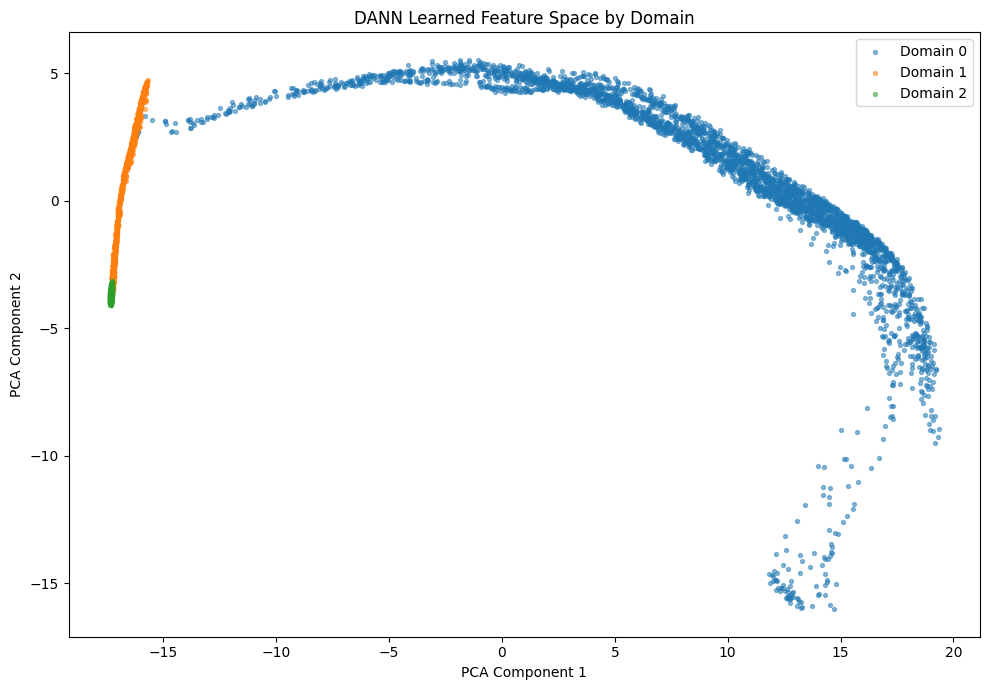

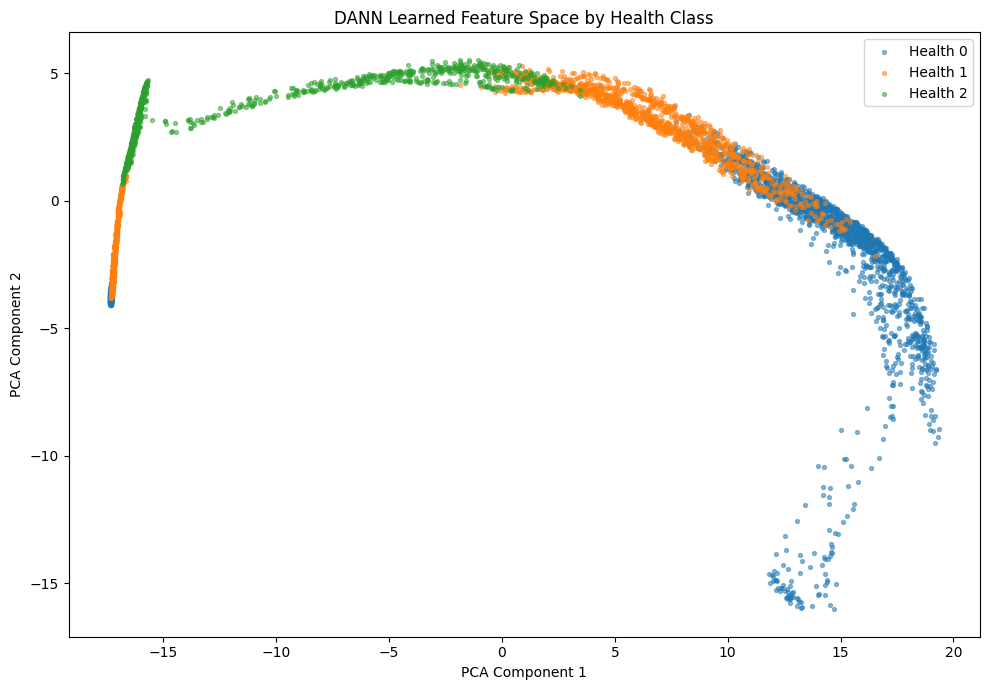

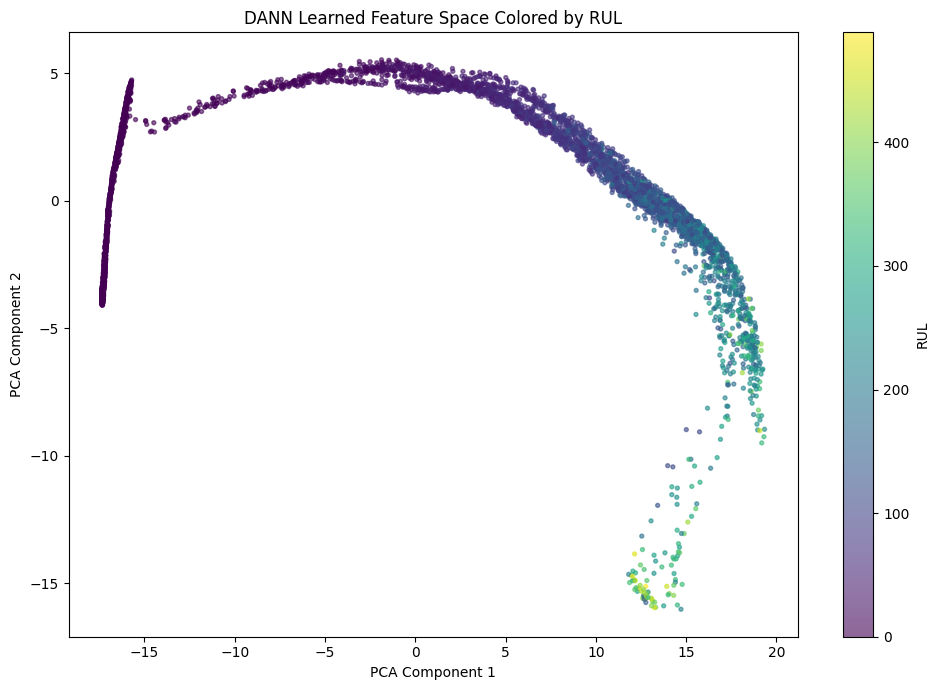


DOMAIN CENTROID ANALYSIS

Domain centroid distances:
Domain 0 ↔ Domain 1: 25.725883
Domain 0 ↔ Domain 2: 26.79759
Domain 1 ↔ Domain 2: 7.1906495

DOMAIN STATISTICS
   domain_id   domain_name  samples  health_0  health_1  health_2    mean_RUL  \
0          0  NASA C-MAPSS     3285      1612      1183       490  111.795433   
1          1     UCI Naval      949         1       513       435    0.000000   
2          2      NASA IMS      766       766         0         0    0.000000   

     std_RUL  min_RUL  max_RUL  
0  81.381897      0.0    489.0  
1   0.000000      0.0      0.0  
2   0.000000      0.0      0.0  


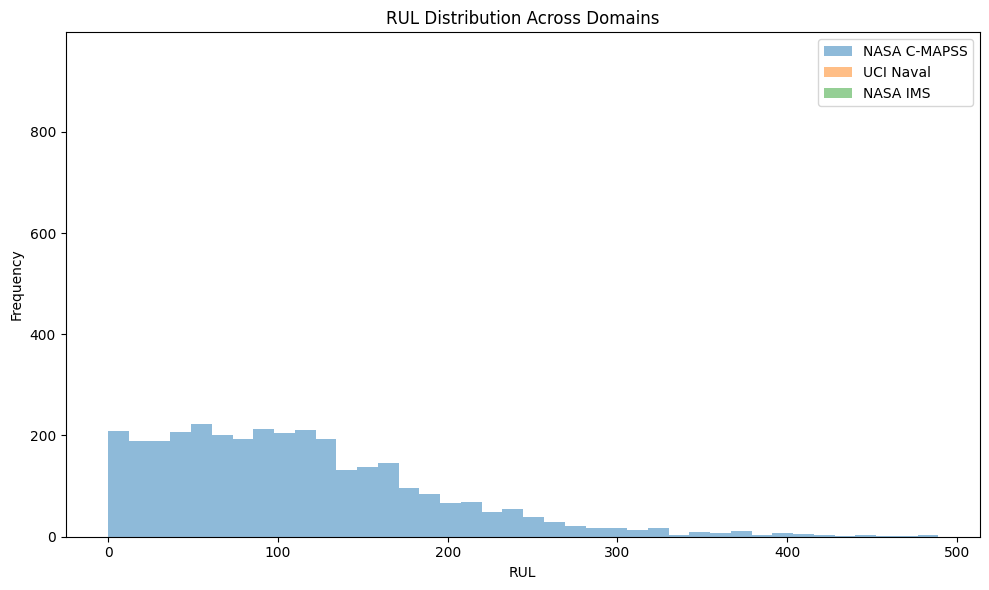


✅ PHASE 7A COMPLETED
Learned feature shape: (5000, 64)
Visualization samples: 5000

Files saved:
1. dann_feature_domain_pca.png
2. dann_feature_health_pca.png
3. dann_feature_rul_pca.png
4. rul_distribution_domains.png
5. domain_summary.csv
6. dann_learned_features.csv

Output directory:
/kaggle/working/DANN_ANALYSIS


In [ ]:
# ================================================================
# PHASE 7A — DANN DOMAIN ADAPTATION ANALYSIS
# ================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("PHASE 7A — DANN DOMAIN ADAPTATION ANALYSIS")
print("=" * 70)

# ------------------------------------------------
# PATHS
# ------------------------------------------------

BASE_DIR = "/kaggle/working"

SEQ_DIR = f"{BASE_DIR}/DANN_MULTIDOMAIN_SEQUENCES"
MODEL_DIR = f"{BASE_DIR}/DANN_MODELS"
XAI_DIR = f"{BASE_DIR}/DANN_XAI"

MODEL_PATH = f"{MODEL_DIR}/FINAL_DANN_MODEL.keras"

OUTPUT_DIR = f"{BASE_DIR}/DANN_ANALYSIS"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------

print("\nLoading sequence data...")

X = np.load(f"{SEQ_DIR}/X_sequences.npy")
y_rul = np.load(f"{SEQ_DIR}/y_rul.npy")
y_health = np.load(f"{SEQ_DIR}/y_health.npy")
domain_labels = np.load(f"{SEQ_DIR}/domain_labels.npy")

print("X:", X.shape)
print("RUL:", y_rul.shape)
print("Health:", y_health.shape)
print("Domain:", domain_labels.shape)

# ------------------------------------------------
# LOAD MODEL
# ------------------------------------------------

print("\nLoading DANN model...")

class GradientReversal(tf.keras.layers.Layer):

    def __init__(self, lambda_=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_ = lambda_

    def call(self, x):
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "lambda_": self.lambda_
        })
        return config


model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "GradientReversal": GradientReversal
    },
    compile=False
)

print("✅ Model loaded")

print("\nModel outputs:")

for i, output in enumerate(model.outputs):

    print(
        f"Output {i}:",
        output.shape
    )

# ================================================================
# CREATE FEATURE EXTRACTOR
# ================================================================

print("\n" + "=" * 70)
print("EXTRACTING DANN FEATURES")
print("=" * 70)

# Find useful intermediate representation

feature_layer = None

for layer in reversed(model.layers):

    try:

        output_shape = layer.output.shape

        if len(output_shape) == 2:

            if output_shape[-1] >= 32:

                feature_layer = layer
                break

    except:

        continue


if feature_layer is None:

    raise ValueError(
        "Could not identify feature extraction layer."
    )


print(
    "Feature layer:",
    feature_layer.name
)

print(
    "Feature shape:",
    feature_layer.output.shape
)

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=feature_layer.output
)

# ------------------------------------------------
# SAMPLE FOR VISUALIZATION
# ------------------------------------------------

MAX_SAMPLES = 5000

np.random.seed(42)

if len(X) > MAX_SAMPLES:

    indices = np.random.choice(
        len(X),
        MAX_SAMPLES,
        replace=False
    )

else:

    indices = np.arange(len(X))


X_sample = X[indices]

domain_sample = domain_labels[indices]

health_sample = y_health[indices]

rul_sample = y_rul[indices]

print(
    "\nVisualization samples:",
    len(X_sample)
)

# ------------------------------------------------
# EXTRACT FEATURES
# ------------------------------------------------

print("\nExtracting learned features...")

features = feature_model.predict(
    X_sample,
    batch_size=128,
    verbose=1
)

print(
    "Learned feature shape:",
    features.shape
)

# ================================================================
# PCA OF LEARNED FEATURES
# ================================================================

print("\n" + "=" * 70)
print("PCA — LEARNED DANN FEATURES")
print("=" * 70)

pca = PCA(
    n_components=2,
    random_state=42
)

features_pca = pca.fit_transform(features)

print(
    "PC1 variance:",
    pca.explained_variance_ratio_[0]
)

print(
    "PC2 variance:",
    pca.explained_variance_ratio_[1]
)

print(
    "Total:",
    pca.explained_variance_ratio_.sum()
)

# ------------------------------------------------
# DOMAIN VISUALIZATION
# ------------------------------------------------

plt.figure(figsize=(10, 7))

for domain in np.unique(domain_sample):

    mask = domain_sample == domain

    plt.scatter(
        features_pca[mask, 0],
        features_pca[mask, 1],
        s=8,
        alpha=0.5,
        label=f"Domain {domain}"
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "DANN Learned Feature Space by Domain"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/dann_feature_domain_pca.png",
    dpi=300
)

plt.show()

# ================================================================
# HEALTH VISUALIZATION
# ================================================================

plt.figure(figsize=(10, 7))

for health in np.unique(health_sample):

    mask = health_sample == health

    plt.scatter(
        features_pca[mask, 0],
        features_pca[mask, 1],
        s=8,
        alpha=0.5,
        label=f"Health {health}"
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "DANN Learned Feature Space by Health Class"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/dann_feature_health_pca.png",
    dpi=300
)

plt.show()

# ================================================================
# RUL VISUALIZATION
# ================================================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    features_pca[:, 0],
    features_pca[:, 1],
    c=rul_sample,
    s=8,
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="RUL"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "DANN Learned Feature Space Colored by RUL"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/dann_feature_rul_pca.png",
    dpi=300
)

plt.show()

# ================================================================
# DOMAIN CENTROID ANALYSIS
# ================================================================

print("\n" + "=" * 70)
print("DOMAIN CENTROID ANALYSIS")
print("=" * 70)

centroids = {}

for domain in np.unique(domain_sample):

    mask = domain_sample == domain

    centroid = features[mask].mean(axis=0)

    centroids[int(domain)] = centroid


domain_ids = sorted(centroids.keys())

print("\nDomain centroid distances:")

for i in range(len(domain_ids)):

    for j in range(i + 1, len(domain_ids)):

        d1 = domain_ids[i]
        d2 = domain_ids[j]

        distance = np.linalg.norm(
            centroids[d1] - centroids[d2]
        )

        print(
            f"Domain {d1} ↔ Domain {d2}:",
            distance
        )

# ================================================================
# DOMAIN STATISTICS
# ================================================================

print("\n" + "=" * 70)
print("DOMAIN STATISTICS")
print("=" * 70)

domain_names = {
    0: "NASA C-MAPSS",
    1: "UCI Naval",
    2: "NASA IMS"
}

domain_summary = []

for domain in sorted(np.unique(domain_sample)):

    mask = domain_sample == domain

    domain_summary.append({

        "domain_id": int(domain),

        "domain_name": domain_names.get(
            int(domain),
            str(domain)
        ),

        "samples": int(mask.sum()),

        "health_0": int(
            np.sum(
                health_sample[mask] == 0
            )
        ),

        "health_1": int(
            np.sum(
                health_sample[mask] == 1
            )
        ),

        "health_2": int(
            np.sum(
                health_sample[mask] == 2
            )
        ),

        "mean_RUL": float(
            np.mean(rul_sample[mask])
        ),

        "std_RUL": float(
            np.std(rul_sample[mask])
        ),

        "min_RUL": float(
            np.min(rul_sample[mask])
        ),

        "max_RUL": float(
            np.max(rul_sample[mask])
        )

    })


domain_summary_df = pd.DataFrame(
    domain_summary
)

print(
    domain_summary_df
)

domain_summary_df.to_csv(
    f"{OUTPUT_DIR}/domain_summary.csv",
    index=False
)

# ================================================================
# RUL DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

for domain in sorted(np.unique(domain_sample)):

    mask = domain_sample == domain

    plt.hist(
        rul_sample[mask],
        bins=40,
        alpha=0.5,
        label=domain_names.get(
            int(domain),
            str(domain)
        )
    )

plt.xlabel("RUL")

plt.ylabel("Frequency")

plt.title(
    "RUL Distribution Across Domains"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/rul_distribution_domains.png",
    dpi=300
)

plt.show()

# ================================================================
# SAVE LEARNED FEATURES
# ================================================================

feature_df = pd.DataFrame(
    features
)

feature_df["domain"] = domain_sample

feature_df["health"] = health_sample

feature_df["RUL"] = rul_sample

feature_df.to_csv(
    f"{OUTPUT_DIR}/dann_learned_features.csv",
    index=False
)

# ================================================================
# FINAL SUMMARY
# ================================================================

print("\n" + "=" * 70)

print("✅ PHASE 7A COMPLETED")

print("=" * 70)

print(
    "Learned feature shape:",
    features.shape
)

print(
    "Visualization samples:",
    len(features)
)

print(
    "\nFiles saved:"
)

print(
    "1. dann_feature_domain_pca.png"
)

print(
    "2. dann_feature_health_pca.png"
)

print(
    "3. dann_feature_rul_pca.png"
)

print(
    "4. rul_distribution_domains.png"
)

print(
    "5. domain_summary.csv"
)

print(
    "6. dann_learned_features.csv"
)

print(
    "\nOutput directory:"
)

print(OUTPUT_DIR)

PHASE 8A — FINAL PREDICTIVE MAINTENANCE SYSTEM

CHECKING REQUIRED FILES
✅ DANN Model: FOUND
✅ X sequences: FOUND
✅ RUL labels: FOUND
✅ Health labels: FOUND
✅ Domain labels: FOUND
✅ Feature list: FOUND

LOADING DATA
X shape: (60891, 30, 115)
RUL shape: (60891,)
Health shape: (60891,)
Domain shape: (60891,)
Number of features: 115

LOADING DANN MODEL
✅ DANN model loaded successfully

MODEL OUTPUTS
Output 0: (None, 3) keras_tensor_93
Output 1: (None, 1) keras_tensor_95
Output 2: (None, 3) keras_tensor_97

TESTING FINAL PREDICTION ENGINE

PREDICTION RESULT
Health Status: DEGRADED
Health Confidence: 96.68%
Predicted RUL: 60.93 cycles
Detected Domain: NASA C-MAPSS
Domain Confidence: 100.00%
Recommendation: SCHEDULE PREVENTIVE MAINTENANCE

Health Probabilities:
HEALTHY   : 2.91%
DEGRADED  : 96.68%
CRITICAL  : 0.41%

Domain Probabilities:
NASA C-MAPSS      : 100.00%
UCI NAVAL         : 0.00%
NASA IMS          : 0.00%


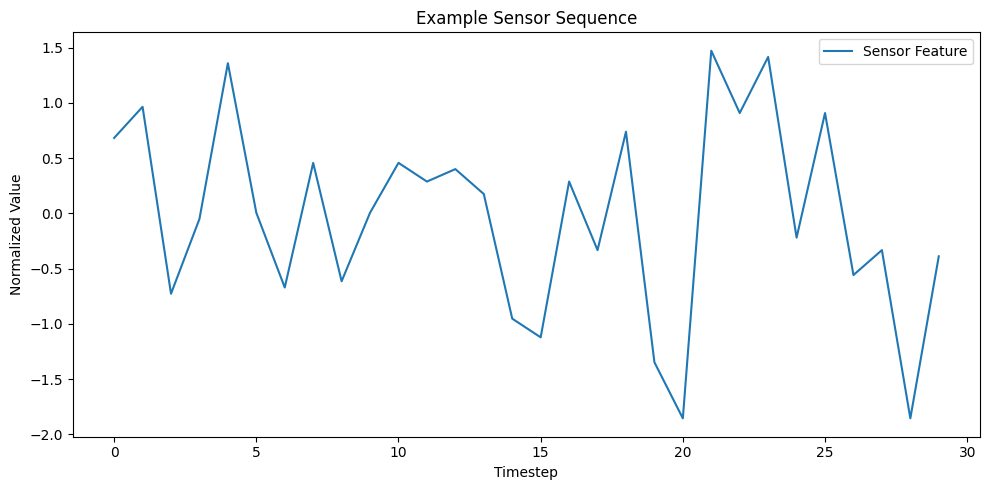


✅ PHASE 8A COMPLETED
Prediction engine is ready.
Input: 30 timesteps × 115 features
Output 1: Health classification
Output 2: RUL prediction
Output 3: Domain classification
Output 4: Maintenance recommendation

Saved to:
/kaggle/working/FINAL_PREDICTION_SYSTEM

Files:
1. final_prediction.csv
2. test_sensor_sequence.png


In [ ]:
# ================================================================
# PHASE 8A — FINAL PREDICTIVE MAINTENANCE SYSTEM
# ================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("PHASE 8A — FINAL PREDICTIVE MAINTENANCE SYSTEM")
print("=" * 70)


# ================================================================
# 1. PATHS
# ================================================================

MODEL_PATH = "/kaggle/working/DANN_MODELS/FINAL_DANN_MODEL.keras"

DATA_PATH = "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/X_sequences.npy"
RUL_PATH = "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/y_rul.npy"
HEALTH_PATH = "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/y_health.npy"
DOMAIN_PATH = "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/domain_labels.npy"

FEATURE_PATH = (
    "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/feature_list.csv"
)

OUTPUT_DIR = "/kaggle/working/FINAL_PREDICTION_SYSTEM"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ================================================================
# 2. CHECK FILES
# ================================================================

print("\n" + "=" * 70)
print("CHECKING REQUIRED FILES")
print("=" * 70)

required_files = {
    "DANN Model": MODEL_PATH,
    "X sequences": DATA_PATH,
    "RUL labels": RUL_PATH,
    "Health labels": HEALTH_PATH,
    "Domain labels": DOMAIN_PATH,
    "Feature list": FEATURE_PATH
}

for name, path in required_files.items():

    if os.path.exists(path):
        print(f"✅ {name}: FOUND")
    else:
        print(f"❌ {name}: NOT FOUND")


# ================================================================
# 3. LOAD DATA
# ================================================================

print("\n" + "=" * 70)
print("LOADING DATA")
print("=" * 70)

X = np.load(DATA_PATH)
y_rul = np.load(RUL_PATH)
y_health = np.load(HEALTH_PATH)
domain_labels = np.load(DOMAIN_PATH)

feature_df = pd.read_csv(FEATURE_PATH)

feature_names = feature_df["feature"].tolist()

print("X shape:", X.shape)
print("RUL shape:", y_rul.shape)
print("Health shape:", y_health.shape)
print("Domain shape:", domain_labels.shape)

print("Number of features:", len(feature_names))


# ================================================================
# 4. LOAD MODEL
# ================================================================

print("\n" + "=" * 70)
print("LOADING DANN MODEL")
print("=" * 70)


class GradientReversal(tf.keras.layers.Layer):

    def __init__(self, lambda_=1.0, **kwargs):

        super().__init__(**kwargs)

        self.lambda_ = lambda_

    def call(self, inputs):

        return inputs

    def get_config(self):

        config = super().get_config()

        config.update({
            "lambda_": self.lambda_
        })

        return config


model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "GradientReversal": GradientReversal
    },
    compile=False
)

print("✅ DANN model loaded successfully")


# ================================================================
# 5. DISPLAY MODEL OUTPUTS
# ================================================================

print("\n" + "=" * 70)
print("MODEL OUTPUTS")
print("=" * 70)

for i, output in enumerate(model.outputs):

    print(
        f"Output {i}:",
        output.shape,
        output.name
    )


# ================================================================
# 6. LABEL DEFINITIONS
# ================================================================

HEALTH_NAMES = {
    0: "HEALTHY",
    1: "DEGRADED",
    2: "CRITICAL"
}

DOMAIN_NAMES = {
    0: "NASA C-MAPSS",
    1: "UCI NAVAL",
    2: "NASA IMS"
}


# ================================================================
# 7. PREDICTION FUNCTION
# ================================================================

def predict_maintenance(sequence):

    """
    sequence shape:
        (30, 115)

    or:

        (1, 30, 115)
    """

    sequence = np.asarray(
        sequence,
        dtype=np.float32
    )

    if sequence.ndim == 2:

        sequence = np.expand_dims(
            sequence,
            axis=0
        )

    if sequence.shape[1] != 30:

        raise ValueError(
            f"Expected 30 timesteps, "
            f"received {sequence.shape[1]}"
        )

    if sequence.shape[2] != len(feature_names):

        raise ValueError(
            f"Expected {len(feature_names)} features, "
            f"received {sequence.shape[2]}"
        )


    # ------------------------------------------------------------
    # MODEL PREDICTION
    # ------------------------------------------------------------

    predictions = model.predict(
        sequence,
        verbose=0
    )

    health_pred = predictions[0]
    rul_pred = predictions[1]
    domain_pred = predictions[2]


    # ------------------------------------------------------------
    # HEALTH
    # ------------------------------------------------------------

    health_probabilities = health_pred[0]

    health_class = int(
        np.argmax(
            health_probabilities
        )
    )

    health_confidence = float(
        np.max(
            health_probabilities
        )
    )


    # ------------------------------------------------------------
    # RUL
    # ------------------------------------------------------------

    rul_value = float(
        np.squeeze(
            rul_pred[0]
        )
    )

    rul_value = max(
        0,
        rul_value
    )


    # ------------------------------------------------------------
    # DOMAIN
    # ------------------------------------------------------------

    domain_probabilities = domain_pred[0]

    domain_class = int(
        np.argmax(
            domain_probabilities
        )
    )

    domain_confidence = float(
        np.max(
            domain_probabilities
        )
    )


    # ------------------------------------------------------------
    # MAINTENANCE RECOMMENDATION
    # ------------------------------------------------------------

    if rul_value <= 20 or health_class == 2:

        recommendation = (
            "URGENT MAINTENANCE REQUIRED"
        )

    elif rul_value <= 60 or health_class == 1:

        recommendation = (
            "SCHEDULE PREVENTIVE MAINTENANCE"
        )

    else:

        recommendation = (
            "SYSTEM OPERATING NORMALLY"
        )


    return {

        "health_class":
            health_class,

        "health_status":
            HEALTH_NAMES[health_class],

        "health_confidence":
            health_confidence,

        "health_probabilities":
            health_probabilities,

        "predicted_rul":
            rul_value,

        "domain_class":
            domain_class,

        "domain":
            DOMAIN_NAMES[domain_class],

        "domain_confidence":
            domain_confidence,

        "domain_probabilities":
            domain_probabilities,

        "recommendation":
            recommendation
    }


# ================================================================
# 8. TEST USING REAL DATA
# ================================================================

print("\n" + "=" * 70)
print("TESTING FINAL PREDICTION ENGINE")
print("=" * 70)


TEST_INDEX = 100


test_sequence = X[TEST_INDEX]


result = predict_maintenance(
    test_sequence
)


print("\n" + "=" * 70)
print("PREDICTION RESULT")
print("=" * 70)

print(
    "Health Status:",
    result["health_status"]
)

print(
    "Health Confidence:",
    f"{result['health_confidence'] * 100:.2f}%"
)

print(
    "Predicted RUL:",
    f"{result['predicted_rul']:.2f} cycles"
)

print(
    "Detected Domain:",
    result["domain"]
)

print(
    "Domain Confidence:",
    f"{result['domain_confidence'] * 100:.2f}%"
)

print(
    "Recommendation:",
    result["recommendation"]
)


# ================================================================
# 9. HEALTH PROBABILITIES
# ================================================================

print("\nHealth Probabilities:")

for i, probability in enumerate(
    result["health_probabilities"]
):

    print(
        f"{HEALTH_NAMES[i]:10s}: "
        f"{probability * 100:.2f}%"
    )


# ================================================================
# 10. DOMAIN PROBABILITIES
# ================================================================

print("\nDomain Probabilities:")

for i, probability in enumerate(
    result["domain_probabilities"]
):

    print(
        f"{DOMAIN_NAMES[i]:18s}: "
        f"{probability * 100:.2f}%"
    )


# ================================================================
# 11. RUL VISUALIZATION
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    test_sequence[:, 0],
    label="Sensor Feature"
)

plt.title(
    "Example Sensor Sequence"
)

plt.xlabel(
    "Timestep"
)

plt.ylabel(
    "Normalized Value"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/test_sensor_sequence.png",
    dpi=200
)

plt.show()


# ================================================================
# 12. SAVE PREDICTION
# ================================================================

prediction_record = {

    "test_index":
        TEST_INDEX,

    "health_status":
        result["health_status"],

    "health_confidence":
        result["health_confidence"],

    "predicted_rul":
        result["predicted_rul"],

    "domain":
        result["domain"],

    "domain_confidence":
        result["domain_confidence"],

    "recommendation":
        result["recommendation"]
}


prediction_df = pd.DataFrame(
    [prediction_record]
)

prediction_df.to_csv(
    f"{OUTPUT_DIR}/final_prediction.csv",
    index=False
)


# ================================================================
# 13. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("✅ PHASE 8A COMPLETED")
print("=" * 70)

print(
    "Prediction engine is ready."
)

print(
    "Input:",
    "30 timesteps × 115 features"
)

print(
    "Output 1:",
    "Health classification"
)

print(
    "Output 2:",
    "RUL prediction"
)

print(
    "Output 3:",
    "Domain classification"
)

print(
    "Output 4:",
    "Maintenance recommendation"
)

print("\nSaved to:")

print(OUTPUT_DIR)

print("\nFiles:")

print("1. final_prediction.csv")
print("2. test_sensor_sequence.png")

In [ ]:
# ================================================================
# PHASE 8B — CREATE FINAL STREAMLIT PREDICTIVE MAINTENANCE APP
# ================================================================

import os

APP_DIR = "/kaggle/working/FINAL_PREDICTION_SYSTEM"

os.makedirs(APP_DIR, exist_ok=True)

print("=" * 70)
print("PHASE 8B — STREAMLIT APPLICATION")
print("=" * 70)

print("\nApplication directory:")
print(APP_DIR)

PHASE 8B — STREAMLIT APPLICATION

Application directory:
/kaggle/working/FINAL_PREDICTION_SYSTEM


In [ ]:
# ================================================================
# CREATE app.py
# ================================================================

app_code = r'''
import streamlit as st
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt


# ================================================================
# PAGE CONFIGURATION
# ================================================================

st.set_page_config(
    page_title="AI Predictive Maintenance",
    page_icon="⚙️",
    layout="wide"
)


# ================================================================
# PATHS
# ================================================================

MODEL_PATH = (
    "/kaggle/working/DANN_MODELS/"
    "FINAL_DANN_MODEL.keras"
)

FEATURE_PATH = (
    "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/"
    "feature_list.csv"
)

X_PATH = (
    "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/"
    "X_sequences.npy"
)

XAI_PATH = (
    "/kaggle/working/DANN_XAI/"
    "combined_feature_importance.csv"
)


# ================================================================
# CUSTOM GRADIENT REVERSAL
# ================================================================

class GradientReversal(tf.keras.layers.Layer):

    def __init__(self, lambda_=1.0, **kwargs):

        super().__init__(**kwargs)

        self.lambda_ = lambda_

    def call(self, inputs):

        return inputs

    def get_config(self):

        config = super().get_config()

        config.update({
            "lambda_": self.lambda_
        })

        return config


# ================================================================
# LOAD MODEL
# ================================================================

@st.cache_resource
def load_dann_model():

    model = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            "GradientReversal":
                GradientReversal
        },
        compile=False
    )

    return model


# ================================================================
# LOAD FEATURES
# ================================================================

@st.cache_data
def load_feature_names():

    df = pd.read_csv(
        FEATURE_PATH
    )

    return df["feature"].tolist()


# ================================================================
# LOAD XAI
# ================================================================

@st.cache_data
def load_xai():

    if os.path.exists(XAI_PATH):

        return pd.read_csv(
            XAI_PATH
        )

    return None


# ================================================================
# LABELS
# ================================================================

HEALTH_NAMES = {
    0: "HEALTHY",
    1: "DEGRADED",
    2: "CRITICAL"
}


DOMAIN_NAMES = {
    0: "NASA C-MAPSS",
    1: "UCI NAVAL",
    2: "NASA IMS"
}


# ================================================================
# RECOMMENDATION
# ================================================================

def get_recommendation(
    health_class,
    rul
):

    if health_class == 2 or rul <= 20:

        return (
            "URGENT MAINTENANCE REQUIRED"
        )

    elif health_class == 1 or rul <= 60:

        return (
            "SCHEDULE PREVENTIVE MAINTENANCE"
        )

    else:

        return (
            "SYSTEM OPERATING NORMALLY"
        )


# ================================================================
# PREDICTION
# ================================================================

def predict(sequence, model):

    sequence = np.asarray(
        sequence,
        dtype=np.float32
    )

    if sequence.ndim == 2:

        sequence = np.expand_dims(
            sequence,
            axis=0
        )

    predictions = model.predict(
        sequence,
        verbose=0
    )

    health_output = predictions[0][0]

    rul_output = predictions[1][0]

    domain_output = predictions[2][0]


    health_class = int(
        np.argmax(
            health_output
        )
    )

    health_confidence = float(
        np.max(
            health_output
        )
    )


    rul = float(
        np.squeeze(
            rul_output
        )
    )

    rul = max(
        0,
        rul
    )


    domain_class = int(
        np.argmax(
            domain_output
        )
    )

    domain_confidence = float(
        np.max(
            domain_output
        )
    )


    recommendation = get_recommendation(
        health_class,
        rul
    )


    return {

        "health_class":
            health_class,

        "health":
            HEALTH_NAMES[
                health_class
            ],

        "health_confidence":
            health_confidence,

        "health_probabilities":
            health_output,

        "rul":
            rul,

        "domain_class":
            domain_class,

        "domain":
            DOMAIN_NAMES[
                domain_class
            ],

        "domain_confidence":
            domain_confidence,

        "domain_probabilities":
            domain_output,

        "recommendation":
            recommendation
    }


# ================================================================
# HEADER
# ================================================================

st.title(
    "⚙️ AI Predictive Maintenance System"
)

st.markdown(
    """
### DANN-Based Multi-Domain Predictive Maintenance

The system predicts:

- 🏥 Machine Health
- ⏳ Remaining Useful Life (RUL)
- 🌐 Operating Domain
- 🔍 Explainable AI Features
- 🛠️ Maintenance Recommendation
"""
)


# ================================================================
# SIDEBAR
# ================================================================

st.sidebar.header(
    "System Information"
)

st.sidebar.write(
    "Sequence Length: 30"
)

st.sidebar.write(
    "Features per timestep: 115"
)

st.sidebar.write(
    "Health Classes: 3"
)

st.sidebar.write(
    "Domains: 3"
)

st.sidebar.success(
    "DANN Model Ready"
)


# ================================================================
# LOAD MODEL
# ================================================================

try:

    model = load_dann_model()

    feature_names = load_feature_names()

    xai_df = load_xai()

except Exception as e:

    st.error(
        f"Model loading error: {e}"
    )

    st.stop()


# ================================================================
# CSV UPLOAD
# ================================================================

st.header(
    "📁 Upload Sensor Data"
)

uploaded_file = st.file_uploader(
    "Upload CSV sensor data",
    type=["csv"]
)


# ================================================================
# DEMO MODE
# ================================================================

st.subheader(
    "Demo Mode"
)

demo = st.checkbox(
    "Use a sample sequence from the trained dataset"
)


if demo:

    try:

        X_demo = np.load(
            X_PATH,
            mmap_mode="r"
        )

        demo_index = st.slider(
            "Select sample",
            0,
            min(
                1000,
                len(X_demo) - 1
            ),
            100
        )

        sequence = X_demo[
            demo_index
        ]

        st.info(
            f"Using sample sequence #{demo_index}"
        )

    except Exception as e:

        st.error(
            f"Demo data error: {e}"
        )

        st.stop()


elif uploaded_file is not None:

    df = pd.read_csv(
        uploaded_file
    )

    st.success(
        f"CSV loaded: {df.shape[0]} rows × "
        f"{df.shape[1]} columns"
    )


    # ------------------------------------------------------------
    # CHECK FEATURES
    # ------------------------------------------------------------

    missing_features = [

        feature

        for feature in feature_names

        if feature not in df.columns

    ]


    if missing_features:

        st.error(
            "Missing required features:"
        )

        st.write(
            missing_features
        )

        st.stop()


    # ------------------------------------------------------------
    # SELECT FEATURES
    # ------------------------------------------------------------

    sensor_df = df[
        feature_names
    ].copy()


    # ------------------------------------------------------------
    # CLEAN DATA
    # ------------------------------------------------------------

    sensor_df = sensor_df.apply(
        pd.to_numeric,
        errors="coerce"
    )

    sensor_df = sensor_df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    sensor_df = sensor_df.fillna(
        sensor_df.median()
    )

    sensor_df = sensor_df.fillna(0)


    # ------------------------------------------------------------
    # REQUIRE 30 TIMESTEPS
    # ------------------------------------------------------------

    if len(sensor_df) < 30:

        st.error(
            "CSV must contain at least "
            "30 timesteps."
        )

        st.stop()


    # ------------------------------------------------------------
    # TAKE LATEST 30 TIMESTEPS
    # ------------------------------------------------------------

    sequence = sensor_df.tail(
        30
    ).values.astype(
        np.float32
    )


    st.info(
        "Latest 30 timesteps selected "
        "for prediction."
    )


else:

    st.info(
        "Upload a CSV or enable Demo Mode."
    )

    st.stop()


# ================================================================
# PREDICT BUTTON
# ================================================================

st.divider()

if st.button(
    "🚀 RUN PREDICTION",
    use_container_width=True
):

    with st.spinner(
        "Running DANN prediction..."
    ):

        result = predict(
            sequence,
            model
        )


    # ============================================================
    # RESULT HEADER
    # ============================================================

    st.header(
        "📊 Prediction Result"
    )


    # ============================================================
    # MAIN METRICS
    # ============================================================

    col1, col2, col3, col4 = st.columns(4)


    with col1:

        st.metric(
            "Health Status",
            result["health"]
        )


    with col2:

        st.metric(
            "Health Confidence",
            f"{result['health_confidence'] * 100:.2f}%"
        )


    with col3:

        st.metric(
            "Predicted RUL",
            f"{result['rul']:.2f} cycles"
        )


    with col4:

        st.metric(
            "Detected Domain",
            result["domain"]
        )


    # ============================================================
    # MAINTENANCE STATUS
    # ============================================================

    st.subheader(
        "🛠️ Maintenance Recommendation"
    )

    if result["health_class"] == 2:

        st.error(
            result["recommendation"]
        )

    elif result["health_class"] == 1:

        st.warning(
            result["recommendation"]
        )

    else:

        st.success(
            result["recommendation"]
        )


    # ============================================================
    # HEALTH PROBABILITIES
    # ============================================================

    st.subheader(
        "🏥 Health Classification"
    )

    health_df = pd.DataFrame({

        "Health State": [
            HEALTH_NAMES[i]
            for i in range(3)
        ],

        "Probability (%)":
            result[
                "health_probabilities"
            ] * 100

    })


    st.dataframe(
        health_df,
        use_container_width=True
    )


    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    ax.bar(
        health_df[
            "Health State"
        ],
        health_df[
            "Probability (%)"
        ]
    )

    ax.set_ylabel(
        "Probability (%)"
    )

    ax.set_title(
        "Health Prediction"
    )

    st.pyplot(fig)


    # ============================================================
    # DOMAIN PROBABILITIES
    # ============================================================

    st.subheader(
        "🌐 Domain Classification"
    )

    domain_df = pd.DataFrame({

        "Domain": [
            DOMAIN_NAMES[i]
            for i in range(3)
        ],

        "Probability (%)":
            result[
                "domain_probabilities"
            ] * 100

    })


    st.dataframe(
        domain_df,
        use_container_width=True
    )


    # ============================================================
    # SENSOR TREND
    # ============================================================

    st.subheader(
        "📈 Sensor Sequence"
    )

    fig, ax = plt.subplots(
        figsize=(10, 4)
    )

    ax.plot(
        sequence[:, 0]
    )

    ax.set_xlabel(
        "Timestep"
    )

    ax.set_ylabel(
        feature_names[0]
    )

    ax.set_title(
        "Selected Sensor Feature"
    )

    st.pyplot(fig)


    # ============================================================
    # XAI
    # ============================================================

    st.subheader(
        "🔍 Explainable AI"
    )

    if xai_df is not None:

        if (
            "feature"
            in xai_df.columns
            and
            "overall_importance"
            in xai_df.columns
        ):

            top_features = (
                xai_df
                .sort_values(
                    "overall_importance",
                    ascending=False
                )
                .head(10)
            )

            st.dataframe(
                top_features,
                use_container_width=True
            )


            fig, ax = plt.subplots(
                figsize=(10, 5)
            )

            ax.barh(
                top_features[
                    "feature"
                ][::-1],

                top_features[
                    "overall_importance"
                ][::-1]
            )

            ax.set_xlabel(
                "Importance"
            )

            ax.set_title(
                "Top 10 Important Features"
            )

            st.pyplot(fig)


    # ============================================================
    # FINAL REPORT
    # ============================================================

    report = pd.DataFrame([{

        "Health":
            result["health"],

        "Health Confidence (%)":
            result[
                "health_confidence"
            ] * 100,

        "Predicted RUL":
            result["rul"],

        "Domain":
            result["domain"],

        "Domain Confidence (%)":
            result[
                "domain_confidence"
            ] * 100,

        "Maintenance Recommendation":
            result[
                "recommendation"
            ]

    }])


    st.subheader(
        "📄 Prediction Report"
    )

    st.dataframe(
        report,
        use_container_width=True
    )


    csv_data = report.to_csv(
        index=False
    )


    st.download_button(
        "⬇️ Download Prediction Report",
        csv_data,
        "predictive_maintenance_report.csv",
        "text/csv"
    )


# ================================================================
# FOOTER
# ================================================================

st.divider()

st.caption(
    "DANN-Based Multi-Domain Predictive Maintenance "
    "with Explainable AI"
)
'''


APP_PATH = f"{APP_DIR}/app.py"

with open(
    APP_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(app_code)


print("\n✅ Streamlit app created:")
print(APP_PATH)

print("\nFile size:")
print(
    os.path.getsize(APP_PATH),
    "bytes"
)


✅ Streamlit app created:
/kaggle/working/FINAL_PREDICTION_SYSTEM/app.py

File size:
15443 bytes


In [ ]:
import os

print(
    os.path.exists(
        "/kaggle/working/FINAL_PREDICTION_SYSTEM/app.py"
    )
)

print(
    os.listdir(
        "/kaggle/working/FINAL_PREDICTION_SYSTEM"
    )
)

False
['test_sensor_sequence.png', 'final_prediction.csv']


In [ ]:
app_code = r'''
import streamlit as st
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import label_binarize


# ================================================================
# PAGE CONFIG
# ================================================================

st.set_page_config(
    page_title="AI Predictive Maintenance",
    page_icon=None,
    layout="wide",
    initial_sidebar_state="expanded"
)


# ================================================================
# PATHS
# ================================================================

MODEL_PATH = (
    "/kaggle/working/DANN_MODELS/"
    "FINAL_DANN_MODEL.keras"
)

FEATURE_PATH = (
    "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/"
    "feature_list.csv"
)

X_PATH = (
    "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/"
    "X_sequences.npy"
)

RUL_PATH = (
    "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/"
    "y_rul.npy"
)

HEALTH_PATH = (
    "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/"
    "y_health.npy"
)

DOMAIN_PATH = (
    "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/"
    "domain_labels.npy"
)

XAI_PATH = (
    "/kaggle/working/DANN_XAI/"
    "combined_feature_importance.csv"
)


# ================================================================
# LIGHT THEME CSS
# ================================================================

st.markdown(
"""
<style>

.stApp {
    background: #f6f8fc;
    color: #1e293b;
}

.main {
    background: #f6f8fc;
}

[data-testid="stSidebar"] {
    background: #ffffff;
    border-right: 1px solid #dbe3ef;
}

[data-testid="stSidebar"] * {
    color: #1e293b !important;
}

.main-title {
    font-size: 40px;
    font-weight: 800;
    color: #172554;
    margin-bottom: 5px;
}

.subtitle {
    font-size: 17px;
    color: #64748b;
    margin-bottom: 25px;
}

.section-title {
    font-size: 25px;
    font-weight: 750;
    color: #172554;
    margin-top: 25px;
    margin-bottom: 15px;
}

.metric-card {
    background: #ffffff;
    border: 1px solid #dbe3ef;
    border-radius: 16px;
    padding: 22px;
    min-height: 125px;
    box-shadow: 0 4px 14px rgba(15,23,42,0.06);
}

.metric-title {
    color: #64748b;
    font-size: 13px;
    font-weight: 700;
    text-transform: uppercase;
}

.metric-value {
    font-size: 26px;
    font-weight: 800;
    color: #172554;
    margin-top: 10px;
}

.card-blue {
    border-top: 5px solid #2563eb;
}

.card-green {
    border-top: 5px solid #16a34a;
}

.card-orange {
    border-top: 5px solid #f59e0b;
}

.card-purple {
    border-top: 5px solid #7c3aed;
}

.info-box {
    background: #ffffff;
    border-left: 5px solid #2563eb;
    border-radius: 12px;
    padding: 18px;
    margin: 12px 0;
    box-shadow: 0 3px 12px rgba(15,23,42,0.05);
}

.success-box {
    background: #ecfdf5;
    border-left: 5px solid #16a34a;
    border-radius: 12px;
    padding: 18px;
    margin: 12px 0;
}

.warning-box {
    background: #fffbeb;
    border-left: 5px solid #f59e0b;
    border-radius: 12px;
    padding: 18px;
    margin: 12px 0;
}

.critical-box {
    background: #fef2f2;
    border-left: 5px solid #dc2626;
    border-radius: 12px;
    padding: 18px;
    margin: 12px 0;
}

.rul-card {
    background: linear-gradient(
        135deg,
        #eff6ff,
        #ffffff
    );
    border: 1px solid #bfdbfe;
    border-radius: 16px;
    padding: 20px;
    text-align: center;
}

.rul-number {
    font-size: 38px;
    font-weight: 850;
    color: #1d4ed8;
}

.rul-label {
    color: #64748b;
    font-weight: 600;
}

.nav-title {
    color: #1d4ed8;
    text-align: center;
    font-size: 24px;
    font-weight: 800;
}

.stButton > button {
    border-radius: 10px;
    border: none;
    background: linear-gradient(
        90deg,
        #2563eb,
        #7c3aed
    );
    color: white;
    font-weight: 700;
    padding: 11px;
}

.stButton > button:hover {
    background: linear-gradient(
        90deg,
        #1d4ed8,
        #6d28d9
    );
    color: white;
}

.stDownloadButton > button {
    border-radius: 10px;
    font-weight: 700;
}

div[data-testid="stFileUploader"] {
    background: #ffffff;
    border: 1px solid #dbe3ef;
    border-radius: 12px;
    padding: 10px;
}

div[data-baseweb="select"] > div {
    background: #ffffff;
}

.footer {
    text-align: center;
    color: #94a3b8;
    padding: 30px;
    font-size: 13px;
}

</style>
""",
unsafe_allow_html=True
)


# ================================================================
# LABELS
# ================================================================

HEALTH_NAMES = {
    0: "HEALTHY",
    1: "DEGRADED",
    2: "CRITICAL"
}

DOMAIN_NAMES = {
    0: "NASA C-MAPSS",
    1: "UCI NAVAL",
    2: "NASA IMS"
}


# ================================================================
# CUSTOM GRADIENT REVERSAL
# ================================================================

class GradientReversal(tf.keras.layers.Layer):

    def __init__(self, lambda_=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_ = lambda_

    def call(self, inputs):
        return inputs

    def get_config(self):

        config = super().get_config()

        config.update({
            "lambda_": self.lambda_
        })

        return config


# ================================================================
# LOAD MODEL
# ================================================================

@st.cache_resource
def load_dann_model():

    return tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            "GradientReversal": GradientReversal
        },
        compile=False
    )


# ================================================================
# LOAD FEATURE NAMES
# ================================================================

@st.cache_data
def load_feature_names():

    df = pd.read_csv(
        FEATURE_PATH
    )

    return df["feature"].tolist()


# ================================================================
# LOAD XAI
# ================================================================

@st.cache_data
def load_xai():

    if os.path.exists(XAI_PATH):

        return pd.read_csv(
            XAI_PATH
        )

    return None


# ================================================================
# LOAD EVALUATION DATA
# ================================================================

@st.cache_data
def load_evaluation_data():

    X = np.load(
        X_PATH,
        mmap_mode="r"
    )

    y_rul = np.load(
        RUL_PATH
    )

    y_health = np.load(
        HEALTH_PATH
    )

    domain_labels = np.load(
        DOMAIN_PATH
    )

    return (
        X,
        y_rul,
        y_health,
        domain_labels
    )


# ================================================================
# RECOMMENDATION ENGINE
# ================================================================

def get_recommendation(
    health_class,
    rul
):

    if health_class == 2 or rul <= 20:

        return {
            "level": "CRITICAL",
            "title": "URGENT MAINTENANCE REQUIRED",
            "type": "critical",
            "actions": [
                "Inspect the equipment immediately.",
                "Check high-risk vibration indicators.",
                "Inspect turbine and compressor condition.",
                "Check abnormal temperature and pressure behavior.",
                "Identify degraded components.",
                "Avoid continued operation if unsafe."
            ]
        }

    elif health_class == 1 or rul <= 60:

        return {
            "level": "WARNING",
            "title": "PREVENTIVE MAINTENANCE RECOMMENDED",
            "type": "warning",
            "actions": [
                "Schedule preventive maintenance.",
                "Increase condition monitoring frequency.",
                "Monitor vibration RMS and crest factor.",
                "Monitor turbine exit temperature.",
                "Inspect compressor degradation indicators.",
                "Plan maintenance before RUL reaches critical range."
            ]
        }

    else:

        return {
            "level": "NORMAL",
            "title": "SYSTEM OPERATING NORMALLY",
            "type": "success",
            "actions": [
                "Continue normal operation.",
                "Maintain routine inspection intervals.",
                "Continue collecting sensor measurements.",
                "Track long-term degradation trends.",
                "Avoid unnecessary component replacement.",
                "Continue AI-based condition monitoring."
            ]
        }


# ================================================================
# RUL IMPROVEMENT ENGINE
# ================================================================

def get_rul_improvement_actions(rul):

    if rul <= 20:

        return [
            "Immediate corrective maintenance",
            "Inspect turbine and compressor components",
            "Investigate abnormal vibration signatures",
            "Check temperature and pressure abnormalities",
            "Replace severely degraded components",
            "Perform detailed inspection before restart"
        ]

    elif rul <= 60:

        return [
            "Schedule preventive maintenance",
            "Monitor vibration RMS and crest factor",
            "Monitor turbine exit temperature",
            "Inspect compressor health indicators",
            "Increase sensor monitoring frequency",
            "Perform component-level inspection"
        ]

    elif rul <= 120:

        return [
            "Continue condition-based monitoring",
            "Track sensor degradation trends",
            "Monitor vibration indicators",
            "Keep operating conditions stable",
            "Optimize maintenance intervals",
            "Continue collecting high-quality sensor data"
        ]

    else:

        return [
            "Continue routine preventive maintenance",
            "Maintain continuous sensor monitoring",
            "Keep operating parameters within recommended ranges",
            "Track long-term degradation trends",
            "Avoid unnecessary maintenance",
            "Continue AI-based predictive monitoring"
        ]


# ================================================================
# SINGLE PREDICTION
# ================================================================

def predict(
    sequence,
    model
):

    sequence = np.asarray(
        sequence,
        dtype=np.float32
    )

    if sequence.ndim == 2:

        sequence = np.expand_dims(
            sequence,
            axis=0
        )

    predictions = model.predict(
        sequence,
        verbose=0
    )

    health_output = np.asarray(
        predictions[0][0]
    )

    rul_output = np.asarray(
        predictions[1][0]
    )

    domain_output = np.asarray(
        predictions[2][0]
    )

    health_class = int(
        np.argmax(
            health_output
        )
    )

    health_confidence = float(
        np.max(
            health_output
        )
    )

    rul = float(
        np.squeeze(
            rul_output
        )
    )

    rul = max(
        0,
        rul
    )

    domain_class = int(
        np.argmax(
            domain_output
        )
    )

    domain_confidence = float(
        np.max(
            domain_output
        )
    )

    recommendation = get_recommendation(
        health_class,
        rul
    )

    return {

        "health_class":
            health_class,

        "health":
            HEALTH_NAMES[
                health_class
            ],

        "health_confidence":
            health_confidence,

        "health_probabilities":
            health_output,

        "rul":
            rul,

        "domain_class":
            domain_class,

        "domain":
            DOMAIN_NAMES[
                domain_class
            ],

        "domain_confidence":
            domain_confidence,

        "domain_probabilities":
            domain_output,

        "recommendation":
            recommendation
    }


# ================================================================
# ROLLING RUL PREDICTION
# ================================================================

def rolling_rul_prediction(
    dataframe,
    feature_names,
    model
):

    sensor_df = dataframe[
        feature_names
    ].copy()

    sensor_df = sensor_df.apply(
        pd.to_numeric,
        errors="coerce"
    )

    sensor_df = sensor_df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    sensor_df = sensor_df.fillna(
        sensor_df.median()
    )

    sensor_df = sensor_df.fillna(0)

    values = sensor_df.values.astype(
        np.float32
    )

    if len(values) < 30:

        return None

    sequences = []

    window_numbers = []

    for end in range(
        30,
        len(values) + 1
    ):

        start = end - 30

        sequences.append(
            values[start:end]
        )

        window_numbers.append(
            end
        )

    sequences = np.asarray(
        sequences,
        dtype=np.float32
    )

    predictions = model.predict(
        sequences,
        verbose=0,
        batch_size=64
    )

    rul_predictions = np.asarray(
        predictions[1]
    ).reshape(-1)

    rul_predictions = np.maximum(
        rul_predictions,
        0
    )

    result = pd.DataFrame({

        "Window_End":
            window_numbers,

        "Predicted_RUL":
            rul_predictions

    })

    return result


# ================================================================
# LOAD RESOURCES
# ================================================================

try:

    model = load_dann_model()

    feature_names = load_feature_names()

    xai_df = load_xai()

except Exception as e:

    st.error(
        f"Unable to load model resources: {e}"
    )

    st.stop()


# ================================================================
# SIDEBAR
# ================================================================

st.sidebar.markdown(
"""
<div class="nav-title">
AI-PM
</div>

<div style="
text-align:center;
color:#64748b;
margin-bottom:15px;
">
AI Predictive Maintenance
</div>
""",
unsafe_allow_html=True
)

st.sidebar.divider()

page = st.sidebar.radio(
    "NAVIGATION",
    [
        "Dashboard",
        "Prediction",
        "XAI & Maintenance",
        "Model Evaluation"
    ]
)

st.sidebar.divider()

st.sidebar.markdown(
"""
### Model Configuration

DANN Multi-Domain Model

Sequence Length: 30
Features: 115
Health Classes: 3
Domains: 3

### Prediction Tasks

Health Classification
RUL Prediction
Domain Detection
Explainable AI
"""
)


# ================================================================
# DASHBOARD
# ================================================================

if page == "Dashboard":

    st.markdown(
        '<div class="main-title">'
        'AI Predictive Maintenance'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="subtitle">'
        'DANN-Based Multi-Domain Intelligent '
        'Condition Monitoring Platform'
        '</div>',
        unsafe_allow_html=True
    )

    c1, c2, c3, c4 = st.columns(4)

    with c1:

        st.markdown(
        """
        <div class="metric-card card-blue">
        <div class="metric-title">
        MODEL
        </div>
        <div class="metric-value">
        DANN READY
        </div>
        </div>
        """,
        unsafe_allow_html=True
        )

    with c2:

        st.markdown(
        """
        <div class="metric-card card-green">
        <div class="metric-title">
        INPUT
        </div>
        <div class="metric-value">
        30 × 115
        </div>
        </div>
        """,
        unsafe_allow_html=True
        )

    with c3:

        st.markdown(
        """
        <div class="metric-card card-orange">
        <div class="metric-title">
        DOMAINS
        </div>
        <div class="metric-value">
        3
        </div>
        </div>
        """,
        unsafe_allow_html=True
        )

    with c4:

        st.markdown(
        """
        <div class="metric-card card-purple">
        <div class="metric-title">
        XAI
        </div>
        <div class="metric-value">
        ENABLED
        </div>
        </div>
        """,
        unsafe_allow_html=True
        )

    st.markdown(
        '<div class="section-title">'
        'Model Performance'
        '</div>',
        unsafe_allow_html=True
    )

    p1, p2, p3 = st.columns(3)

    with p1:
        st.metric(
            "Health Accuracy",
            "91.22%"
        )

    with p2:
        st.metric(
            "RUL R²",
            "87.52%"
        )

    with p3:
        st.metric(
            "Domain Accuracy",
            "99.91%"
        )

    st.markdown(
    """
    <div class="info-box">

    <b>DANN Architecture</b><br><br>

    Sensor Sequence → Feature Extraction →
    Domain Adversarial Neural Network →
    Health Classification + RUL Regression +
    Domain Classification →
    Explainable Maintenance Decision

    </div>
    """,
    unsafe_allow_html=True
    )

    st.markdown(
        '<div class="section-title">'
        'Supported Domains'
        '</div>',
        unsafe_allow_html=True
    )

    d1, d2, d3 = st.columns(3)

    with d1:
        st.info(
            "NASA C-MAPSS\n\n"
            "Aero-engine degradation"
        )

    with d2:
        st.info(
            "UCI NAVAL\n\n"
            "Gas turbine condition"
        )

    with d3:
        st.info(
            "NASA IMS\n\n"
            "Industrial machinery"
        )


# ================================================================
# PREDICTION PAGE
# ================================================================

elif page == "Prediction":

    st.markdown(
        '<div class="main-title">'
        'Machine Prediction'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="subtitle">'
        'Upload sensor data and analyze machine health, '
        'RUL and degradation trends'
        '</div>',
        unsafe_allow_html=True
    )

    uploaded_file = st.file_uploader(
        "Upload sensor CSV",
        type=["csv"]
    )

    st.markdown(
        '<div class="section-title">'
        'Demo Dataset'
        '</div>',
        unsafe_allow_html=True
    )

    demo = st.checkbox(
        "Use a sample from the trained dataset"
    )

    sequence = None
    uploaded_df = None

    if demo:

        X_demo = np.load(
            X_PATH,
            mmap_mode="r"
        )

        demo_index = st.slider(
            "Select sample",
            0,
            min(
                1000,
                len(X_demo) - 1
            ),
            100
        )

        sequence = X_demo[
            demo_index
        ]

        st.success(
            f"Dataset sequence {demo_index} selected."
        )

    elif uploaded_file is not None:

        uploaded_df = pd.read_csv(
            uploaded_file
        )

        st.success(
            f"CSV loaded successfully: "
            f"{uploaded_df.shape[0]} rows × "
            f"{uploaded_df.shape[1]} columns"
        )

        missing_features = [
            f
            for f in feature_names
            if f not in uploaded_df.columns
        ]

        if missing_features:

            st.error(
                "Required features are missing."
            )

            st.write(
                missing_features
            )

            st.stop()

        sensor_df = uploaded_df[
            feature_names
        ].copy()

        sensor_df = sensor_df.apply(
            pd.to_numeric,
            errors="coerce"
        )

        sensor_df = sensor_df.replace(
            [np.inf, -np.inf],
            np.nan
        )

        sensor_df = sensor_df.fillna(
            sensor_df.median()
        )

        sensor_df = sensor_df.fillna(0)

        if len(sensor_df) < 30:

            st.error(
                "At least 30 timesteps are required."
            )

            st.stop()

        sequence = sensor_df.tail(
            30
        ).values.astype(
            np.float32
        )

        st.info(
            "The latest 30 timesteps are used "
            "for the current prediction."
        )

    else:

        st.info(
            "Upload a CSV or enable Demo Dataset."
        )

        st.stop()

    st.divider()

    if st.button(
        "RUN AI PREDICTION",
        use_container_width=True
    ):

        with st.spinner(
            "Analyzing machine condition..."
        ):

            result = predict(
                sequence,
                model
            )

        st.session_state[
            "prediction_result"
        ] = result

        st.session_state[
            "prediction_sequence"
        ] = sequence

        st.session_state[
            "uploaded_df"
        ] = uploaded_df


    if (
        "prediction_result"
        in st.session_state
    ):

        result = st.session_state[
            "prediction_result"
        ]

        sequence = st.session_state[
            "prediction_sequence"
        ]

        uploaded_df = st.session_state.get(
            "uploaded_df",
            None
        )

        st.markdown(
            '<div class="section-title">'
            'Prediction Result'
            '</div>',
            unsafe_allow_html=True
        )

        c1, c2, c3, c4 = st.columns(4)

        with c1:
            st.metric(
                "Health",
                result["health"]
            )

        with c2:
            st.metric(
                "Health Confidence",
                f"{result['health_confidence']*100:.2f}%"
            )

        with c3:
            st.metric(
                "Predicted RUL",
                f"{result['rul']:.2f} cycles"
            )

        with c4:
            st.metric(
                "Domain",
                result["domain"]
            )

        # --------------------------------------------------------
        # RUL CARD
        # --------------------------------------------------------

        st.markdown(
            '<div class="section-title">'
            'Remaining Useful Life'
            '</div>',
            unsafe_allow_html=True
        )

        st.markdown(
            f"""
            <div class="rul-card">

            <div class="rul-number">
            {result["rul"]:.2f}
            </div>

            <div class="rul-label">
            Predicted Remaining Useful Life (cycles)
            </div>

            </div>
            """,
            unsafe_allow_html=True
        )

        rul = result["rul"]

        if rul <= 20:

            st.error(
                f"Critical RUL: {rul:.2f} cycles"
            )

        elif rul <= 60:

            st.warning(
                f"Warning RUL: {rul:.2f} cycles"
            )

        elif rul <= 120:

            st.info(
                f"Moderate RUL: {rul:.2f} cycles"
            )

        else:

            st.success(
                f"Healthy RUL: {rul:.2f} cycles"
            )

        # --------------------------------------------------------
        # RECOMMENDATION
        # --------------------------------------------------------

        rec = result[
            "recommendation"
        ]

        st.markdown(
            '<div class="section-title">'
            'Maintenance Recommendation'
            '</div>',
            unsafe_allow_html=True
        )

        if rec["type"] == "critical":

            st.markdown(
                f"""
                <div class="critical-box">

                <h3>
                {rec["title"]}
                </h3>

                <ul>

                {"".join(
                    f"<li>{x}</li>"
                    for x in rec["actions"]
                )}

                </ul>

                </div>
                """,
                unsafe_allow_html=True
            )

        elif rec["type"] == "warning":

            st.markdown(
                f"""
                <div class="warning-box">

                <h3>
                {rec["title"]}
                </h3>

                <ul>

                {"".join(
                    f"<li>{x}</li>"
                    for x in rec["actions"]
                )}

                </ul>

                </div>
                """,
                unsafe_allow_html=True
            )

        else:

            st.markdown(
                f"""
                <div class="success-box">

                <h3>
                {rec["title"]}
                </h3>

                <ul>

                {"".join(
                    f"<li>{x}</li>"
                    for x in rec["actions"]
                )}

                </ul>

                </div>
                """,
                unsafe_allow_html=True
            )

        # --------------------------------------------------------
        # HEALTH PROBABILITY
        # --------------------------------------------------------

        st.markdown(
            '<div class="section-title">'
            'Health Classification'
            '</div>',
            unsafe_allow_html=True
        )

        health_df = pd.DataFrame({

            "Health State": [
                HEALTH_NAMES[i]
                for i in range(3)
            ],

            "Probability (%)":
                result[
                    "health_probabilities"
                ] * 100

        })

        st.dataframe(
            health_df,
            use_container_width=True
        )

        fig, ax = plt.subplots(
            figsize=(8, 4)
        )

        ax.bar(
            health_df["Health State"],
            health_df["Probability (%)"]
        )

        ax.set_ylabel(
            "Probability (%)"
        )

        ax.set_title(
            "Machine Health Prediction"
        )

        st.pyplot(
            fig,
            clear_figure=True
        )

        # --------------------------------------------------------
        # DOMAIN
        # --------------------------------------------------------

        st.markdown(
            '<div class="section-title">'
            'Domain Detection'
            '</div>',
            unsafe_allow_html=True
        )

        domain_df = pd.DataFrame({

            "Domain": [
                DOMAIN_NAMES[i]
                for i in range(3)
            ],

            "Probability (%)":
                result[
                    "domain_probabilities"
                ] * 100

        })

        st.dataframe(
            domain_df,
            use_container_width=True
        )

        # --------------------------------------------------------
        # SENSOR TREND
        # --------------------------------------------------------

        st.markdown(
            '<div class="section-title">'
            'Sensor Trend and RUL Analysis'
            '</div>',
            unsafe_allow_html=True
        )

        sensor_number = st.selectbox(
            "Select sensor feature",
            range(
                len(feature_names)
            ),
            format_func=lambda x:
                feature_names[x]
        )

        selected_feature = feature_names[
            sensor_number
        ]

        sensor_values = sequence[
            :,
            sensor_number
        ]

        col_a, col_b = st.columns(2)

        with col_a:

            st.markdown(
                f"""
                <div class="info-box">

                <b>Selected Feature</b><br>

                {selected_feature}

                </div>
                """,
                unsafe_allow_html=True
            )

        with col_b:

            st.markdown(
                f"""
                <div class="rul-card">

                <div class="rul-number">
                {result["rul"]:.2f}
                </div>

                <div class="rul-label">
                Current Sequence RUL
                </div>

                </div>
                """,
                unsafe_allow_html=True
            )

        fig, ax = plt.subplots(
            figsize=(11, 4)
        )

        ax.plot(
            range(
                1,
                len(sensor_values) + 1
            ),
            sensor_values,
            linewidth=2
        )

        ax.set_xlabel(
            "Timestep"
        )

        ax.set_ylabel(
            selected_feature
        )

        ax.set_title(
            f"30-Timestep Trend: {selected_feature}"
        )

        ax.grid(
            alpha=0.25
        )

        st.pyplot(
            fig,
            clear_figure=True
        )

        # --------------------------------------------------------
        # SENSOR IMPORTANCE
        # --------------------------------------------------------

        if xai_df is not None:

            feature_row = xai_df[
                xai_df["feature"]
                == selected_feature
            ]

            if not feature_row.empty:

                importance = float(
                    feature_row[
                        "overall_importance"
                    ].iloc[0]
                )

                st.info(
                    f"Overall XAI importance of "
                    f"{selected_feature}: "
                    f"{importance:.6f}"
                )

        # --------------------------------------------------------
        # ROLLING RUL
        # --------------------------------------------------------

        if uploaded_df is not None:

            st.markdown(
                '<div class="section-title">'
                'Rolling RUL Prediction'
                '</div>',
                unsafe_allow_html=True
            )

            if len(uploaded_df) >= 30:

                rolling_result = rolling_rul_prediction(
                    uploaded_df,
                    feature_names,
                    model
                )

                if rolling_result is not None:

                    fig, ax = plt.subplots(
                        figsize=(11, 4)
                    )

                    ax.plot(
                        rolling_result[
                            "Window_End"
                        ],
                        rolling_result[
                            "Predicted_RUL"
                        ],
                        linewidth=2
                    )

                    ax.set_xlabel(
                        "Timestep / Window End"
                    )

                    ax.set_ylabel(
                        "Predicted RUL"
                    )

                    ax.set_title(
                        "RUL Evolution Across Sensor Windows"
                    )

                    ax.grid(
                        alpha=0.25
                    )

                    st.pyplot(
                        fig,
                        clear_figure=True
                    )

                    latest_rul = rolling_result[
                        "Predicted_RUL"
                    ].iloc[-1]

                    first_rul = rolling_result[
                        "Predicted_RUL"
                    ].iloc[0]

                    rul_change = (
                        latest_rul -
                        first_rul
                    )

                    if rul_change < 0:

                        st.warning(
                            f"RUL decreased by "
                            f"{abs(rul_change):.2f} cycles "
                            f"across the uploaded sequence."
                        )

                    elif rul_change > 0:

                        st.success(
                            f"RUL increased by "
                            f"{rul_change:.2f} cycles "
                            f"across the uploaded sequence."
                        )

                    else:

                        st.info(
                            "RUL remained approximately stable "
                            "across the uploaded sequence."
                        )

                    st.dataframe(
                        rolling_result.tail(20),
                        use_container_width=True
                    )

            else:

                st.info(
                    "Rolling RUL requires more than "
                    "30 timesteps in the uploaded CSV."
                )

        else:

            st.info(
                "Upload a CSV containing multiple "
                "timesteps to visualize RUL evolution."
            )

        # --------------------------------------------------------
        # REPORT
        # --------------------------------------------------------

        report = pd.DataFrame([{

            "Health":
                result["health"],

            "Health Confidence (%)":
                result[
                    "health_confidence"
                ] * 100,

            "Predicted RUL":
                result["rul"],

            "Domain":
                result["domain"],

            "Domain Confidence (%)":
                result[
                    "domain_confidence"
                ] * 100,

            "Maintenance":
                rec["title"]

        }])

        st.markdown(
            '<div class="section-title">'
            'Prediction Report'
            '</div>',
            unsafe_allow_html=True
        )

        st.dataframe(
            report,
            use_container_width=True
        )

        st.download_button(
            "DOWNLOAD PREDICTION REPORT",
            report.to_csv(
                index=False
            ),
            "AI_predictive_maintenance_report.csv",
            "text/csv"
        )


# ================================================================
# XAI & MAINTENANCE
# ================================================================

elif page == "XAI & Maintenance":

    st.markdown(
        '<div class="main-title">'
        'Explainable AI & Maintenance'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="subtitle">'
        'Understand which features influence machine '
        'health and remaining useful life'
        '</div>',
        unsafe_allow_html=True
    )

    if xai_df is not None:

        if (
            "overall_importance"
            in xai_df.columns
        ):

            top_features = (
                xai_df
                .sort_values(
                    "overall_importance",
                    ascending=False
                )
                .head(15)
            )

            st.markdown(
                '<div class="section-title">'
                'Top Important Features'
                '</div>',
                unsafe_allow_html=True
            )

            st.dataframe(
                top_features,
                use_container_width=True
            )

            fig, ax = plt.subplots(
                figsize=(11, 6)
            )

            ax.barh(
                top_features[
                    "feature"
                ][::-1],

                top_features[
                    "overall_importance"
                ][::-1]
            )

            ax.set_xlabel(
                "Overall Importance"
            )

            ax.set_title(
                "Top Features Influencing Predictions"
            )

            st.pyplot(
                fig,
                clear_figure=True
            )

    else:

        st.warning(
            "XAI feature importance file not found."
        )

    st.divider()

    st.markdown(
        '<div class="section-title">'
        'RUL Improvement Advisor'
        '</div>',
        unsafe_allow_html=True
    )

    rul_input = st.slider(
        "Current Estimated RUL",
        0,
        495,
        100
    )

    st.markdown(
        f"""
        <div class="rul-card">

        <div class="rul-number">
        {rul_input}
        </div>

        <div class="rul-label">
        Current Estimated RUL
        </div>

        </div>
        """,
        unsafe_allow_html=True
    )

    actions = get_rul_improvement_actions(
        rul_input
    )

    for action in actions:

        st.markdown(
            f"""
            <div class="info-box">
            {action}
            </div>
            """,
            unsafe_allow_html=True
        )

    st.markdown(
        '<div class="section-title">'
        'Maintenance Strategy'
        '</div>',
        unsafe_allow_html=True
    )

    strategy_df = pd.DataFrame({

        "RUL Range": [
            "> 120 cycles",
            "61–120 cycles",
            "21–60 cycles",
            "0–20 cycles"
        ],

        "Condition": [
            "Healthy",
            "Monitor",
            "Degraded",
            "Critical"
        ],

        "Recommended Action": [
            "Routine maintenance",
            "Condition monitoring",
            "Preventive maintenance",
            "Immediate inspection"
        ]

    })

    st.dataframe(
        strategy_df,
        use_container_width=True
    )

    st.success(
        "The objective is to detect degradation early, "
        "optimize maintenance timing and reduce unexpected "
        "equipment failure."
    )


# ================================================================
# MODEL EVALUATION
# ================================================================

elif page == "Model Evaluation":

    st.markdown(
        '<div class="main-title">'
        'Model Evaluation'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="subtitle">'
        'Classification reports, ROC curves and RUL regression metrics'
        '</div>',
        unsafe_allow_html=True
    )

    st.info(
        "Evaluation uses the complete trained sequence dataset. "
        "This page is separate from the live prediction interface."
    )

    run_evaluation = st.button(
        "RUN MODEL EVALUATION",
        use_container_width=True
    )

    if run_evaluation:

        with st.spinner(
            "Running model evaluation..."
        ):

            try:

                X_eval = np.asarray(
                    np.load(
                        X_PATH,
                        mmap_mode="r"
                    )
                )

                y_rul_eval = np.asarray(
                    np.load(
                        RUL_PATH
                    )
                ).reshape(-1)

                y_health_eval = np.asarray(
                    np.load(
                        HEALTH_PATH
                    )
                ).reshape(-1)

                y_domain_eval = np.asarray(
                    np.load(
                        DOMAIN_PATH
                    )
                ).reshape(-1)

                predictions = model.predict(
                    X_eval,
                    verbose=1,
                    batch_size=128
                )

                health_prob = np.asarray(
                    predictions[0]
                )

                rul_pred = np.asarray(
                    predictions[1]
                ).reshape(-1)

                domain_prob = np.asarray(
                    predictions[2]
                )

                health_pred = np.argmax(
                    health_prob,
                    axis=1
                )

                domain_pred = np.argmax(
                    domain_prob,
                    axis=1
                )

                # =================================================
                # HEALTH CLASSIFICATION REPORT
                # =================================================

                st.markdown(
                    '<div class="section-title">'
                    'Health Classification Report'
                    '</div>',
                    unsafe_allow_html=True
                )

                health_report = classification_report(
                    y_health_eval,
                    health_pred,
                    labels=[0, 1, 2],
                    target_names=[
                        "HEALTHY",
                        "DEGRADED",
                        "CRITICAL"
                    ],
                    output_dict=True,
                    zero_division=0
                )

                health_report_df = pd.DataFrame(
                    health_report
                ).transpose()

                st.dataframe(
                    health_report_df,
                    use_container_width=True
                )

                health_accuracy = np.mean(
                    y_health_eval
                    == health_pred
                )

                st.metric(
                    "Health Accuracy",
                    f"{health_accuracy*100:.2f}%"
                )

                # =================================================
                # HEALTH CONFUSION MATRIX
                # =================================================

                st.markdown(
                    '<div class="section-title">'
                    'Health Confusion Matrix'
                    '</div>',
                    unsafe_allow_html=True
                )

                cm_health = confusion_matrix(
                    y_health_eval,
                    health_pred,
                    labels=[0, 1, 2]
                )

                cm_df = pd.DataFrame(
                    cm_health,
                    index=[
                        "Actual Healthy",
                        "Actual Degraded",
                        "Actual Critical"
                    ],
                    columns=[
                        "Pred Healthy",
                        "Pred Degraded",
                        "Pred Critical"
                    ]
                )

                st.dataframe(
                    cm_df,
                    use_container_width=True
                )

                # =================================================
                # HEALTH ROC
                # =================================================

                st.markdown(
                    '<div class="section-title">'
                    'Health ROC Curves'
                    '</div>',
                    unsafe_allow_html=True
                )

                y_health_binary = label_binarize(
                    y_health_eval,
                    classes=[0, 1, 2]
                )

                fig, ax = plt.subplots(
                    figsize=(9, 6)
                )

                for i in range(3):

                    fpr, tpr, _ = roc_curve(
                        y_health_binary[:, i],
                        health_prob[:, i]
                    )

                    roc_auc = auc(
                        fpr,
                        tpr
                    )

                    ax.plot(
                        fpr,
                        tpr,
                        linewidth=2,
                        label=
                        f"{HEALTH_NAMES[i]} "
                        f"(AUC = {roc_auc:.3f})"
                    )

                ax.plot(
                    [0, 1],
                    [0, 1],
                    linestyle="--"
                )

                ax.set_xlabel(
                    "False Positive Rate"
                )

                ax.set_ylabel(
                    "True Positive Rate"
                )

                ax.set_title(
                    "Health One-vs-Rest ROC Curves"
                )

                ax.legend()

                ax.grid(
                    alpha=0.25
                )

                st.pyplot(
                    fig,
                    clear_figure=True
                )

                try:

                    health_macro_auc = roc_auc_score(
                        y_health_binary,
                        health_prob,
                        average="macro",
                        multi_class="ovr"
                    )

                    st.success(
                        f"Health Macro ROC-AUC: "
                        f"{health_macro_auc:.4f}"
                    )

                except Exception:

                    st.warning(
                        "Unable to calculate macro ROC-AUC."
                    )

                # =================================================
                # DOMAIN CLASSIFICATION REPORT
                # =================================================

                st.markdown(
                    '<div class="section-title">'
                    'Domain Classification Report'
                    '</div>',
                    unsafe_allow_html=True
                )

                domain_report = classification_report(
                    y_domain_eval,
                    domain_pred,
                    labels=[0, 1, 2],
                    target_names=[
                        "NASA C-MAPSS",
                        "UCI NAVAL",
                        "NASA IMS"
                    ],
                    output_dict=True,
                    zero_division=0
                )

                domain_report_df = pd.DataFrame(
                    domain_report
                ).transpose()

                st.dataframe(
                    domain_report_df,
                    use_container_width=True
                )

                domain_accuracy = np.mean(
                    y_domain_eval
                    == domain_pred
                )

                st.metric(
                    "Domain Accuracy",
                    f"{domain_accuracy*100:.2f}%"
                )

                # =================================================
                # DOMAIN ROC
                # =================================================

                st.markdown(
                    '<div class="section-title">'
                    'Domain ROC Curves'
                    '</div>',
                    unsafe_allow_html=True
                )

                y_domain_binary = label_binarize(
                    y_domain_eval,
                    classes=[0, 1, 2]
                )

                fig, ax = plt.subplots(
                    figsize=(9, 6)
                )

                for i in range(3):

                    fpr, tpr, _ = roc_curve(
                        y_domain_binary[:, i],
                        domain_prob[:, i]
                    )

                    roc_auc = auc(
                        fpr,
                        tpr
                    )

                    ax.plot(
                        fpr,
                        tpr,
                        linewidth=2,
                        label=
                        f"{DOMAIN_NAMES[i]} "
                        f"(AUC = {roc_auc:.3f})"
                    )

                ax.plot(
                    [0, 1],
                    [0, 1],
                    linestyle="--"
                )

                ax.set_xlabel(
                    "False Positive Rate"
                )

                ax.set_ylabel(
                    "True Positive Rate"
                )

                ax.set_title(
                    "Domain One-vs-Rest ROC Curves"
                )

                ax.legend()

                ax.grid(
                    alpha=0.25
                )

                st.pyplot(
                    fig,
                    clear_figure=True
                )

                try:

                    domain_macro_auc = roc_auc_score(
                        y_domain_binary,
                        domain_prob,
                        average="macro",
                        multi_class="ovr"
                    )

                    st.success(
                        f"Domain Macro ROC-AUC: "
                        f"{domain_macro_auc:.4f}"
                    )

                except Exception:

                    st.warning(
                        "Unable to calculate domain macro ROC-AUC."
                    )

                # =================================================
                # RUL EVALUATION
                # =================================================

                st.markdown(
                    '<div class="section-title">'
                    'RUL Regression Evaluation'
                    '</div>',
                    unsafe_allow_html=True
                )

                mae = mean_absolute_error(
                    y_rul_eval,
                    rul_pred
                )

                rmse = np.sqrt(
                    mean_squared_error(
                        y_rul_eval,
                        rul_pred
                    )
                )

                r2 = r2_score(
                    y_rul_eval,
                    rul_pred
                )

                r1, r2_col, r3 = st.columns(3)

                with r1:

                    st.metric(
                        "RUL MAE",
                        f"{mae:.4f}"
                    )

                with r2_col:

                    st.metric(
                        "RUL RMSE",
                        f"{rmse:.4f}"
                    )

                with r3:

                    st.metric(
                        "RUL R²",
                        f"{r2:.4f}"
                    )

                rul_eval_df = pd.DataFrame({

                    "Metric": [
                        "MAE",
                        "RMSE",
                        "R²"
                    ],

                    "Value": [
                        mae,
                        rmse,
                        r2
                    ]

                })

                st.dataframe(
                    rul_eval_df,
                    use_container_width=True
                )

                # =================================================
                # RUL ACTUAL VS PREDICTED
                # =================================================

                st.markdown(
                    '<div class="section-title">'
                    'Actual vs Predicted RUL'
                    '</div>',
                    unsafe_allow_html=True
                )

                sample_count = min(
                    1000,
                    len(y_rul_eval)
                )

                fig, ax = plt.subplots(
                    figsize=(11, 5)
                )

                ax.plot(
                    y_rul_eval[
                        :sample_count
                    ],
                    label="Actual RUL",
                    linewidth=2
                )

                ax.plot(
                    rul_pred[
                        :sample_count
                    ],
                    label="Predicted RUL",
                    linewidth=2
                )

                ax.set_xlabel(
                    "Sample"
                )

                ax.set_ylabel(
                    "RUL"
                )

                ax.set_title(
                    "Actual vs Predicted RUL"
                )

                ax.legend()

                ax.grid(
                    alpha=0.25
                )

                st.pyplot(
                    fig,
                    clear_figure=True
                )

                # =================================================
                # SAVE REPORTS
                # =================================================

                evaluation_dir = (
                    "/kaggle/working/"
                    "FINAL_PREDICTION_SYSTEM/"
                    "MODEL_EVALUATION"
                )

                os.makedirs(
                    evaluation_dir,
                    exist_ok=True
                )

                health_report_df.to_csv(
                    f"{evaluation_dir}/"
                    "health_classification_report.csv"
                )

                domain_report_df.to_csv(
                    f"{evaluation_dir}/"
                    "domain_classification_report.csv"
                )

                rul_eval_df.to_csv(
                    f"{evaluation_dir}/"
                    "rul_regression_report.csv",
                    index=False
                )

                st.success(
                    "Model evaluation completed successfully."
                )

                st.info(
                    "Evaluation reports were saved to: "
                    + evaluation_dir
                )

            except Exception as e:

                st.error(
                    f"Evaluation error: {e}"
                )


# ================================================================
# FOOTER
# ================================================================

st.markdown(
"""
<div class="footer">

AI Predictive Maintenance System

<br><br>

DANN-Based Multi-Domain Learning |
RUL Prediction |
Health Classification |
Domain Adaptation |
Explainable AI

<br><br>

NASA C-MAPSS |
UCI Naval |
NASA IMS

</div>
""",
unsafe_allow_html=True
)
'''


# ================================================================
# WRITE APP
# ================================================================

APP_PATH = (
    "/kaggle/working/"
    "FINAL_PREDICTION_SYSTEM/"
    "app.py"
)

os.makedirs(
    os.path.dirname(APP_PATH),
    exist_ok=True
)

with open(
    APP_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(app_code)


print("=" * 70)
print("CREATIVE LIGHT-THEME STREAMLIT APP CREATED")
print("=" * 70)

print()
print("App:")
print(APP_PATH)

print()
print("Navigation:")
print("1. Dashboard")
print("2. Prediction")
print("3. XAI & Maintenance")
print("4. Model Evaluation")

print()
print("New features:")
print("Light theme")
print("No unnecessary icons")
print("Rolling RUL prediction")
print("Sensor trend analysis")
print("Health classification report")
print("Health ROC curves")
print("Domain classification report")
print("Domain ROC curves")
print("RUL MAE")
print("RUL RMSE")
print("RUL R2")
print("Actual vs Predicted RUL")
print("RUL improvement advisor")

print()
print("App saved successfully.")

CREATIVE LIGHT-THEME STREAMLIT APP CREATED

App:
/kaggle/working/FINAL_PREDICTION_SYSTEM/app.py

Navigation:
1. Dashboard
2. Prediction
3. XAI & Maintenance
4. Model Evaluation

New features:
Light theme
No unnecessary icons
Rolling RUL prediction
Sensor trend analysis
Health classification report
Health ROC curves
Domain classification report
Domain ROC curves
RUL MAE
RUL RMSE
RUL R2
Actual vs Predicted RUL
RUL improvement advisor

App saved successfully.


In [ ]:
pip install pyngrok

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pyngrok import ngrok

NGROK_TOKEN = "3Iabwoy5QrIpPec0FPpJ70wq3G3_83iLBojwo9znm1iM98b6B"

ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(8501)

print("=" * 70)
print("STREAMLIT APP URL")
print("=" * 70)
print(public_url)

STREAMLIT APP URL
NgrokTunnel: "https://bakeshop-sketch-hut.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 65.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 100.8 MB/s eta 0:00:0000:010:01


In [ ]:
import os

APP_DIR = "/kaggle/working/FINAL_PREDICTION_SYSTEM"

print(os.listdir(APP_DIR))

['test_sensor_sequence.png', 'final_prediction.csv', 'app.py']


In [ ]:
#!streamlit run /kaggle/working/FINAL_PREDICTION_SYSTEM/app.py \
#    --server.address 0.0.0.0 \
#    --server.port 8501



2026-09-01 13:05:23.236 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://136.65.81.81:8501

^C
  Stopping...


In [ ]:
from pyngrok import ngrok

NGROK_TOKEN = "3Iabwoy5QrIpPec0FPpJ70wq3G3_83iLBojwo9znm1iM98b6B"

ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(8501)

print("=" * 70)
print("STREAMLIT APP URL")
print("=" * 70)
print(public_url)

STREAMLIT APP URL
NgrokTunnel: "https://bakeshop-sketch-hut.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!pkill -f streamlit

In [ ]:
#!streamlit run /kaggle/working/FINAL_PREDICTION_SYSTEM/app.py \
   # --server.address 0.0.0.0 \
   # --server.port 8501



2026-08-29 12:21:04.610 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://34.26.8.67:8501

^C
  Stopping...


In [ ]:
from pyngrok import ngrok
import subprocess
import time

APP_PATH = "/kaggle/working/FINAL_PREDICTION_SYSTEM/app.py"

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        APP_PATH,
        "--server.address", "0.0.0.0",
        "--server.port", "8501",
    ]
)

time.sleep(5)

public_url = ngrok.connect(8501)

print("=" * 70)
print("STREAMLIT APPLICATION")
print("=" * 70)
print(public_url)

2026-09-01 13:08:01.988 Uvicorn server started on 0.0.0.0:8501



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://136.65.81.81:8501

STREAMLIT APPLICATION
NgrokTunnel: "https://bakeshop-sketch-hut.ngrok-free.dev" -> "http://localhost:8501"


I0000 00:00:1788268105.186644    1702 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11580 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788268105.188933    1702 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
import numpy as np
import pandas as pd
import os

# ============================================================
# CREATE SAMPLE SENSOR DATA FOR PHASE 8B
# ============================================================

SEQUENCE_DIR = "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES"
OUTPUT_DIR = "/kaggle/working/FINAL_PREDICTION_SYSTEM"

X_PATH = os.path.join(SEQUENCE_DIR, "X_sequences.npy")
FEATURE_PATH = os.path.join(SEQUENCE_DIR, "feature_list.csv")

print("=" * 70)
print("CREATING SAMPLE SENSOR DATA")
print("=" * 70)

# Load sequences
X = np.load(X_PATH)

print("X shape:", X.shape)

# Load feature names
feature_df = pd.read_csv(FEATURE_PATH)

feature_names = feature_df["feature"].tolist()

print("Number of features:", len(feature_names))

# Check
if len(feature_names) != X.shape[2]:
    raise ValueError(
        f"Feature mismatch: feature list has {len(feature_names)} "
        f"but X has {X.shape[2]} features."
    )

# ------------------------------------------------------------
# Select one sequence
# ------------------------------------------------------------

TEST_INDEX = 0

sample = X[TEST_INDEX]

print("Selected sequence:", TEST_INDEX)
print("Sample shape:", sample.shape)

# ------------------------------------------------------------
# Convert 30 x 115 sequence to CSV
# ------------------------------------------------------------

sample_df = pd.DataFrame(
    sample,
    columns=feature_names
)

# Add timestep column
sample_df.insert(
    0,
    "timestep",
    np.arange(1, 31)
)

# Save
OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "sample_sensor_data.csv"
)

sample_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\n" + "=" * 70)
print("✅ SAMPLE SENSOR FILE CREATED")
print("=" * 70)

print("File:")
print(OUTPUT_PATH)

print("Shape:", sample_df.shape)

print("\nFirst 5 rows:")
display(sample_df.head())

print("\nUpload this file into your Streamlit application.")

CREATING SAMPLE SENSOR DATA
X shape: (60891, 30, 115)
Number of features: 115
Selected sequence: 0
Sample shape: (30, 115)

✅ SAMPLE SENSOR FILE CREATED
File:
/kaggle/working/FINAL_PREDICTION_SYSTEM/sample_sensor_data.csv
Shape: (30, 116)

First 5 rows:


,timestep,operational_setting_1,operational_setting_2,operational_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,...,channel8_vibration_spectral_energy,channel8_vibration_std,cmapss_sensor_mean,cmapss_sensor_std,naval_sensor_mean,naval_sensor_std,vibration_rms_mean,vibration_rms_std,compressor_degradation,turbine_degradation
0,1,-0.388326,-1.668466,0.0,-1.702883,0.118200,-0.704994,0.105436,-0.240276,-1.034548,...,-0.054466,-0.07868,-0.705782,-0.733534,-0.095855,-0.118635,-0.188812,0.186759,-5.574341e-16,-5.470139e-16
1,2,1.078479,-1.253876,0.0,-0.929341,0.512189,-0.384080,-0.168003,-0.450370,-1.164117,...,-0.054466,-0.07868,-0.813433,-1.052860,-0.095855,-0.118635,-0.188812,0.186759,-5.574341e-16,-5.470139e-16
2,3,-2.419286,1.233665,0.0,-0.460527,-0.199594,-0.250156,0.060610,-0.030182,-0.622009,...,-0.054466,-0.07868,-0.652922,-0.653527,-0.095855,-0.118635,-0.188812,0.186759,-5.574341e-16,-5.470139e-16
3,4,0.401492,-0.010106,0.0,-0.460527,-1.165984,-0.544537,0.145780,0.284959,-0.833473,...,-0.054466,-0.07868,-0.853602,-0.763635,-0.095855,-0.118635,-0.188812,0.186759,-5.574341e-16,-5.470139e-16
4,5,-1.065313,-0.839286,0.0,-0.413646,-1.154834,0.005059,-0.055938,-0.240276,-0.486940,...,-0.054466,-0.07868,-0.596807,-0.571125,-0.095855,-0.118635,-0.188812,0.186759,-5.574341e-16,-5.470139e-16



Upload this file into your Streamlit application.


In [ ]:
# ================================================================
# PHASE 8B — CREATE 30 DIVERSE DEMO SENSOR SAMPLES
# ================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

# ------------------------------------------------
# PATHS
# ------------------------------------------------

SEQUENCE_DIR = "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES"
MODEL_PATH = "/kaggle/working/DANN_MODELS/FINAL_DANN_MODEL.keras"
OUTPUT_DIR = "/kaggle/working/FINAL_PREDICTION_SYSTEM/DEMO_SAMPLES"

os.makedirs(OUTPUT_DIR, exist_ok=True)

X_PATH = os.path.join(SEQUENCE_DIR, "X_sequences.npy")
FEATURE_PATH = os.path.join(SEQUENCE_DIR, "feature_list.csv")

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------

print("=" * 70)
print("PHASE 8B — GENERATING DIVERSE DEMO SAMPLES")
print("=" * 70)

X = np.load(X_PATH)

feature_df = pd.read_csv(FEATURE_PATH)
feature_names = feature_df["feature"].tolist()

print("X shape:", X.shape)
print("Features:", len(feature_names))

# ------------------------------------------------
# LOAD MODEL
# ------------------------------------------------

print("\nLoading DANN model...")

# Your GradientReversal class must already exist
# in the notebook from Phase 6/8.

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False,
    custom_objects={
        "GradientReversal": GradientReversal
    }
)

print("✅ Model loaded")

# ------------------------------------------------
# PREDICT
# ------------------------------------------------

print("\nRunning predictions...")

# To avoid memory problems, use a subset if required
MAX_SAMPLES = min(60891, len(X))

X_predict = X[:MAX_SAMPLES]

predictions = model.predict(
    X_predict,
    batch_size=128,
    verbose=1
)

health_pred = predictions[0]
rul_pred = predictions[1].reshape(-1)
domain_pred = predictions[2]

health_class = np.argmax(
    health_pred,
    axis=1
)

domain_class = np.argmax(
    domain_pred,
    axis=1
)

print("✅ Predictions completed")

# ------------------------------------------------
# CREATE RESULT TABLE
# ------------------------------------------------

results = pd.DataFrame({
    "index": np.arange(MAX_SAMPLES),
    "predicted_rul": rul_pred,
    "health_class": health_class,
    "health_confidence": np.max(health_pred, axis=1),
    "domain_class": domain_class,
    "domain_confidence": np.max(domain_pred, axis=1)
})

# Remove invalid predictions
results = results.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# ------------------------------------------------
# CREATE RUL BINS
# ------------------------------------------------

def rul_range(rul):

    if rul <= 20:
        return "CRITICAL_0_20"

    elif rul <= 40:
        return "CRITICAL_20_40"

    elif rul <= 60:
        return "DEGRADED_40_60"

    elif rul <= 80:
        return "DEGRADED_60_80"

    elif rul <= 120:
        return "MODERATE_80_120"

    elif rul <= 160:
        return "HEALTHY_120_160"

    elif rul <= 220:
        return "HEALTHY_160_220"

    else:
        return "HEALTHY_220_PLUS"


results["rul_range"] = results["predicted_rul"].apply(
    rul_range
)

# ------------------------------------------------
# SELECT DIVERSE SAMPLES
# ------------------------------------------------

print("\nSelecting diverse samples...")

selected = []

# Desired ranges
target_ranges = [
    "CRITICAL_0_20",
    "CRITICAL_20_40",
    "DEGRADED_40_60",
    "DEGRADED_60_80",
    "MODERATE_80_120",
    "HEALTHY_120_160",
    "HEALTHY_160_220",
    "HEALTHY_220_PLUS"
]

# Number desired from each range
samples_per_range = {
    "CRITICAL_0_20": 4,
    "CRITICAL_20_40": 4,
    "DEGRADED_40_60": 4,
    "DEGRADED_60_80": 4,
    "MODERATE_80_120": 4,
    "HEALTHY_120_160": 4,
    "HEALTHY_160_220": 3,
    "HEALTHY_220_PLUS": 3
}

for category in target_ranges:

    category_df = results[
        results["rul_range"] == category
    ].copy()

    if len(category_df) == 0:
        print("⚠️ No samples found:", category)
        continue

    n = min(
        samples_per_range[category],
        len(category_df)
    )

    # Spread selections across the range
    category_df = category_df.sort_values(
        "predicted_rul"
    )

    positions = np.linspace(
        0,
        len(category_df) - 1,
        n
    ).astype(int)

    selected.append(
        category_df.iloc[positions]
    )

# Combine
selected_df = pd.concat(
    selected,
    ignore_index=True
)

# ------------------------------------------------
# IF LESS THAN 30, FILL WITH DIVERSE SAMPLES
# ------------------------------------------------

if len(selected_df) < 30:

    remaining = results[
        ~results["index"].isin(
            selected_df["index"]
        )
    ].copy()

    remaining = remaining.sort_values(
        "predicted_rul"
    )

    needed = 30 - len(selected_df)

    if len(remaining) > 0:

        positions = np.linspace(
            0,
            len(remaining) - 1,
            min(needed, len(remaining))
        ).astype(int)

        extra = remaining.iloc[positions]

        selected_df = pd.concat(
            [selected_df, extra],
            ignore_index=True
        )

# Limit to 30
selected_df = selected_df.head(30)

# ------------------------------------------------
# SAVE INDIVIDUAL CSV FILES
# ------------------------------------------------

print("\nCreating individual sensor files...")

summary = []

for sample_number, (_, row) in enumerate(
    selected_df.iterrows(),
    start=1
):

    original_index = int(row["index"])

    sequence = X_predict[original_index]

    # 30 × 115
    sample_data = pd.DataFrame(
        sequence,
        columns=feature_names
    )

    sample_data.insert(
        0,
        "timestep",
        np.arange(1, 31)
    )

    filename = (
        f"sample_{sample_number:02d}.csv"
    )

    filepath = os.path.join(
        OUTPUT_DIR,
        filename
    )

    sample_data.to_csv(
        filepath,
        index=False
    )

    # Health name
    health_names = {
        0: "HEALTHY",
        1: "DEGRADED",
        2: "CRITICAL"
    }

    # Domain name
    domain_names = {
        0: "NASA C-MAPSS",
        1: "UCI NAVAL",
        2: "NASA IMS"
    }

    summary.append({
        "sample": filename,
        "original_index": original_index,
        "predicted_rul": round(
            float(row["predicted_rul"]),
            2
        ),
        "health_status": health_names.get(
            int(row["health_class"]),
            "UNKNOWN"
        ),
        "health_confidence": round(
            float(row["health_confidence"]) * 100,
            2
        ),
        "domain": domain_names.get(
            int(row["domain_class"]),
            "UNKNOWN"
        ),
        "domain_confidence": round(
            float(row["domain_confidence"]) * 100,
            2
        ),
        "rul_range": row["rul_range"]
    })

# ------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------

summary_df = pd.DataFrame(summary)

summary_path = os.path.join(
    OUTPUT_DIR,
    "demo_samples_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

# ------------------------------------------------
# FINAL OUTPUT
# ------------------------------------------------

print("\n" + "=" * 70)
print("✅ 30 DEMO SENSOR SAMPLES CREATED")
print("=" * 70)

print(
    "Number of samples:",
    len(summary_df)
)

print(
    "Each sample:",
    "30 timesteps × 115 features"
)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nSummary:")
display(summary_df)

print("\nFiles:")
for file in sorted(os.listdir(OUTPUT_DIR)):
    print(file)

print("\n" + "=" * 70)
print("READY FOR STREAMLIT TESTING")
print("=" * 70)

PHASE 8B — GENERATING DIVERSE DEMO SAMPLES
X shape: (60891, 30, 115)
Features: 115

Loading DANN model...
✅ Model loaded

Running predictions...
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
✅ Predictions completed

Selecting diverse samples...

Creating individual sensor files...

✅ 30 DEMO SENSOR SAMPLES CREATED
Number of samples: 30
Each sample: 30 timesteps × 115 features

Output directory:
/kaggle/working/FINAL_PREDICTION_SYSTEM/DEMO_SAMPLES

Summary:


,sample,original_index,predicted_rul,health_status,health_confidence,domain,domain_confidence,rul_range
0,sample_01.csv,58976,0.02,HEALTHY,100.00,NASA IMS,100.00,CRITICAL_0_20
1,sample_02.csv,50270,0.06,DEGRADED,99.86,UCI NAVAL,100.00,CRITICAL_0_20
2,sample_03.csv,46833,0.14,DEGRADED,76.08,UCI NAVAL,99.96,CRITICAL_0_20
3,sample_04.csv,21277,20.00,CRITICAL,94.94,NASA C-MAPSS,100.00,CRITICAL_0_20
4,sample_05.csv,27664,20.00,CRITICAL,95.96,NASA C-MAPSS,100.00,CRITICAL_20_40
5,sample_06.csv,15104,26.74,CRITICAL,71.20,NASA C-MAPSS,100.00,CRITICAL_20_40
6,sample_07.csv,988,33.52,DEGRADED,73.41,NASA C-MAPSS,100.00,CRITICAL_20_40
7,sample_08.csv,14172,40.00,DEGRADED,94.09,NASA C-MAPSS,100.00,CRITICAL_20_40
8,sample_09.csv,5027,40.00,DEGRADED,90.82,NASA C-MAPSS,100.00,DEGRADED_40_60
9,sample_10.csv,3085,46.72,DEGRADED,96.80,NASA C-MAPSS,100.00,DEGRADED_40_60



Files:
demo_samples_summary.csv
sample_01.csv
sample_02.csv
sample_03.csv
sample_04.csv
sample_05.csv
sample_06.csv
sample_07.csv
sample_08.csv
sample_09.csv
sample_10.csv
sample_11.csv
sample_12.csv
sample_13.csv
sample_14.csv
sample_15.csv
sample_16.csv
sample_17.csv
sample_18.csv
sample_19.csv
sample_20.csv
sample_21.csv
sample_22.csv
sample_23.csv
sample_24.csv
sample_25.csv
sample_26.csv
sample_27.csv
sample_28.csv
sample_29.csv
sample_30.csv

READY FOR STREAMLIT TESTING


In [ ]:
import os
import zipfile

# ================================================================
# PHASE 8B — ZIP DEMO SENSOR SAMPLES
# ================================================================

DEMO_DIR = "/kaggle/working/FINAL_PREDICTION_SYSTEM/DEMO_SAMPLES"
ZIP_PATH = "/kaggle/working/DEMO_SENSOR_SAMPLES_30.zip"

print("=" * 70)
print("CREATING ZIP FILE")
print("=" * 70)

# Check folder
if not os.path.exists(DEMO_DIR):
    raise FileNotFoundError(f"Demo folder not found: {DEMO_DIR}")

files = [
    f for f in os.listdir(DEMO_DIR)
    if os.path.isfile(os.path.join(DEMO_DIR, f))
]

print("Files found:", len(files))

# Create ZIP
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for filename in files:
        filepath = os.path.join(DEMO_DIR, filename)
        zipf.write(filepath, arcname=filename)

print("\n" + "=" * 70)
print("✅ ZIP FILE CREATED")
print("=" * 70)

print("Number of files:", len(files))
print("ZIP file:")
print(ZIP_PATH)

print("\nFiles included:")
for f in sorted(files):
    print(" -", f)

print("\nZIP size:")
print(round(os.path.getsize(ZIP_PATH) / (1024 * 1024), 2), "MB")

CREATING ZIP FILE
Files found: 31

✅ ZIP FILE CREATED
Number of files: 31
ZIP file:
/kaggle/working/DEMO_SENSOR_SAMPLES_30.zip

Files included:
 - demo_samples_summary.csv
 - sample_01.csv
 - sample_02.csv
 - sample_03.csv
 - sample_04.csv
 - sample_05.csv
 - sample_06.csv
 - sample_07.csv
 - sample_08.csv
 - sample_09.csv
 - sample_10.csv
 - sample_11.csv
 - sample_12.csv
 - sample_13.csv
 - sample_14.csv
 - sample_15.csv
 - sample_16.csv
 - sample_17.csv
 - sample_18.csv
 - sample_19.csv
 - sample_20.csv
 - sample_21.csv
 - sample_22.csv
 - sample_23.csv
 - sample_24.csv
 - sample_25.csv
 - sample_26.csv
 - sample_27.csv
 - sample_28.csv
 - sample_29.csv
 - sample_30.csv

ZIP size:
0.13 MB


In [ ]:
import os
import shutil

# ================================================================
# CREATE ZIP OF ENTIRE /kaggle/working DIRECTORY
# ================================================================

SOURCE_DIR = "/kaggle/working"
ZIP_PATH = "/kaggle/working/AI_PREDICTIVE_MAINTENANCE_ALL_FILES"

print("=" * 70)
print("CREATING ZIP FILE")
print("=" * 70)

# Remove old zip if it exists
old_zip = ZIP_PATH + ".zip"

if os.path.exists(old_zip):
    os.remove(old_zip)

# Create ZIP
shutil.make_archive(
    ZIP_PATH,
    "zip",
    SOURCE_DIR
)

print("\n✅ ZIP CREATED")
print("=" * 70)

print("ZIP FILE:")
print(old_zip)

print("\nSIZE:")
print(
    round(os.path.getsize(old_zip) / (1024 * 1024), 2),
    "MB"
)

CREATING ZIP FILE


OSError: [Errno 28] No space left on device

2026-09-01 13:48:44.870 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-01 13:48:45.093 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-01 13:48:45.865 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-01 13:48:45.869 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-01 13:49:31.201 

476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


2026-09-01 13:50:49.395 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-01 13:50:49.400 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-01 13:50:49.914 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-01 13:50:50.364 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


In [ ]:
from IPython.display import FileLink

FileLink(
    "/kaggle/working/AI_PREDICTIVE_MAINTENANCE_ALL_FILES.zip"
)

In [ ]:
# ================================================================
# PHASE 9A — LSTM BASELINE FOR IEEE COMPARISON
# ================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("PHASE 9A — LSTM BASELINE")
print("=" * 70)


# ================================================================
# PATHS
# ================================================================

BASE_DIR = "/kaggle/working"

DATA_DIR = (
    f"{BASE_DIR}/DANN_MULTIDOMAIN_SEQUENCES"
)

OUTPUT_DIR = (
    f"{BASE_DIR}/LSTM_BASELINE"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

X_PATH = f"{DATA_DIR}/X_sequences.npy"

RUL_PATH = f"{DATA_DIR}/y_rul.npy"

HEALTH_PATH = f"{DATA_DIR}/y_health.npy"


# ================================================================
# CHECK FILES
# ================================================================

print("\nChecking required files...")

for path in [
    X_PATH,
    RUL_PATH,
    HEALTH_PATH
]:

    print(
        "✅" if os.path.exists(path) else "❌",
        path
    )


# ================================================================
# LOAD DATA
# ================================================================

print("\n" + "=" * 70)
print("LOADING DATA")
print("=" * 70)

X = np.load(X_PATH)

y_rul = np.load(RUL_PATH)

y_health = np.load(HEALTH_PATH)


print("\nX shape:")
print(X.shape)

print("\nRUL shape:")
print(y_rul.shape)

print("\nHealth shape:")
print(y_health.shape)


# ================================================================
# DATA INFORMATION
# ================================================================

N_SAMPLES = X.shape[0]

TIME_STEPS = X.shape[1]

N_FEATURES = X.shape[2]

print("\nSamples      :", N_SAMPLES)
print("Timesteps    :", TIME_STEPS)
print("Features     :", N_FEATURES)


# ================================================================
# CLEAN DATA
# ================================================================

X = np.asarray(
    X,
    dtype=np.float32
)

y_rul = np.asarray(
    y_rul,
    dtype=np.float32
)

y_health = np.asarray(
    y_health,
    dtype=np.int32
)


# ================================================================
# HANDLE NaN / INF
# ================================================================

X = np.nan_to_num(
    X,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

y_rul = np.nan_to_num(
    y_rul,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


# ================================================================
# TRAIN / TEST SPLIT
# ================================================================

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

indices = np.arange(
    N_SAMPLES
)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y_health
)


X_train = X[
    train_idx
]

X_test = X[
    test_idx
]


y_rul_train = y_rul[
    train_idx
]

y_rul_test = y_rul[
    test_idx
]


y_health_train = y_health[
    train_idx
]

y_health_test = y_health[
    test_idx
]


print(
    "\nTraining samples:",
    len(train_idx)
)

print(
    "Testing samples :",
    len(test_idx)
)


# ================================================================
# LSTM MODEL
# ================================================================

print("\n" + "=" * 70)
print("BUILDING LSTM MODEL")
print("=" * 70)


inputs = Input(
    shape=(
        TIME_STEPS,
        N_FEATURES
    ),
    name="sensor_sequence"
)


x = LSTM(
    128,
    return_sequences=True,
    name="lstm_1"
)(inputs)


x = Dropout(
    0.30
)(x)


x = LSTM(
    64,
    return_sequences=False,
    name="lstm_2"
)(x)


x = BatchNormalization()(x)


x = Dense(
    64,
    activation="relu"
)(x)


x = Dropout(
    0.25
)(x)


# ================================================================
# HEALTH OUTPUT
# ================================================================

health_output = Dense(
    3,
    activation="softmax",
    name="health"
)(x)


# ================================================================
# RUL OUTPUT
# ================================================================

rul_output = Dense(
    1,
    activation="linear",
    name="rul"
)(x)


# ================================================================
# MODEL
# ================================================================

lstm_model = Model(
    inputs=inputs,
    outputs=[
        health_output,
        rul_output
    ],
    name="LSTM_Predictive_Maintenance"
)


# ================================================================
# COMPILE
# ================================================================

lstm_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss={
        "health":
            "sparse_categorical_crossentropy",

        "rul":
            "mse"
    },

    loss_weights={
        "health": 1.0,
        "rul": 1.0
    },

    metrics={
        "health":
            ["accuracy"],

        "rul":
            [
                tf.keras.metrics.MeanAbsoluteError(
                    name="mae"
                )
            ]
    }
)


print("\n✅ LSTM model created")

lstm_model.summary()


# ================================================================
# CALLBACKS
# ================================================================

checkpoint_path = (
    f"{OUTPUT_DIR}/best_lstm_model.keras"
)


callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]


# ================================================================
# TRAINING
# ================================================================

print("\n" + "=" * 70)
print("TRAINING LSTM")
print("=" * 70)


history = lstm_model.fit(

    X_train,

    {
        "health":
            y_health_train,

        "rul":
            y_rul_train
    },

    validation_split=0.10,

    epochs=40,

    batch_size=128,

    callbacks=callbacks,

    verbose=1
)


print("\n✅ LSTM training completed")


# ================================================================
# SAVE FINAL MODEL
# ================================================================

final_model_path = (
    f"{OUTPUT_DIR}/LSTM_FINAL_MODEL.keras"
)

lstm_model.save(
    final_model_path
)

print(
    "\nModel saved:",
    final_model_path
)


# ================================================================
# PREDICTION
# ================================================================

print("\n" + "=" * 70)
print("LSTM TEST PREDICTION")
print("=" * 70)


predictions = lstm_model.predict(
    X_test,
    batch_size=128,
    verbose=1
)


health_prob = predictions[0]

rul_pred = predictions[1].reshape(-1)


health_pred = np.argmax(
    health_prob,
    axis=1
)


# ================================================================
# HEALTH METRICS
# ================================================================

health_accuracy = accuracy_score(
    y_health_test,
    health_pred
)


health_precision = precision_score(
    y_health_test,
    health_pred,
    average="weighted",
    zero_division=0
)


health_recall = recall_score(
    y_health_test,
    health_pred,
    average="weighted",
    zero_division=0
)


health_f1 = f1_score(
    y_health_test,
    health_pred,
    average="weighted",
    zero_division=0
)


# ================================================================
# RUL METRICS
# ================================================================

rul_mae = mean_absolute_error(
    y_rul_test,
    rul_pred
)


rul_rmse = np.sqrt(
    mean_squared_error(
        y_rul_test,
        rul_pred
    )
)


rul_r2 = r2_score(
    y_rul_test,
    rul_pred
)


# ================================================================
# PRINT RESULTS
# ================================================================

print("\n" + "=" * 70)
print("LSTM RESULTS")
print("=" * 70)

print("\nHEALTH CLASSIFICATION")

print(
    f"Accuracy  : {health_accuracy:.4f}"
)

print(
    f"Precision : {health_precision:.4f}"
)

print(
    f"Recall    : {health_recall:.4f}"
)

print(
    f"F1 Score  : {health_f1:.4f}"
)


print("\nRUL REGRESSION")

print(
    f"MAE       : {rul_mae:.4f}"
)

print(
    f"RMSE      : {rul_rmse:.4f}"
)

print(
    f"R²        : {rul_r2:.4f}"
)


# ================================================================
# CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

report_text = classification_report(
    y_health_test,
    health_pred,
    target_names=[
        "HEALTHY",
        "DEGRADED",
        "CRITICAL"
    ],
    zero_division=0
)

print(
    report_text
)


with open(
    f"{OUTPUT_DIR}/lstm_classification_report.txt",
    "w"
) as f:

    f.write(
        report_text
    )


# ================================================================
# CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_health_test,
    health_pred
)


plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "LSTM Health Classification Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    [0, 1, 2],
    [
        "HEALTHY",
        "DEGRADED",
        "CRITICAL"
    ]
)

plt.yticks(
    [0, 1, 2],
    [
        "HEALTHY",
        "DEGRADED",
        "CRITICAL"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

for i in range(3):

    for j in range(3):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()

cm_path = (
    f"{OUTPUT_DIR}/lstm_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# RUL ACTUAL VS PREDICTED
# ================================================================

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    y_rul_test,
    rul_pred,
    alpha=0.4
)

min_value = min(
    y_rul_test.min(),
    rul_pred.min()
)

max_value = max(
    y_rul_test.max(),
    rul_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual RUL"
)

plt.ylabel(
    "Predicted RUL"
)

plt.title(
    "LSTM — Actual vs Predicted RUL"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

rul_plot_path = (
    f"{OUTPUT_DIR}/lstm_actual_vs_predicted_rul.png"
)

plt.savefig(
    rul_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# RUL ERROR DISTRIBUTION
# ================================================================

rul_error = (
    rul_pred -
    y_rul_test
)


plt.figure(
    figsize=(9, 5)
)

plt.hist(
    rul_error,
    bins=50
)

plt.xlabel(
    "Prediction Error"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "LSTM RUL Prediction Error Distribution"
)

plt.tight_layout()

error_path = (
    f"{OUTPUT_DIR}/lstm_rul_error_distribution.png"
)

plt.savefig(
    error_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# TRAINING CURVES
# ================================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "LSTM Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

training_path = (
    f"{OUTPUT_DIR}/lstm_training_curve.png"
)

plt.savefig(
    training_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# SAVE RESULTS
# ================================================================

results = pd.DataFrame([{

    "Model":
        "LSTM",

    "Health Accuracy":
        health_accuracy,

    "Health Precision":
        health_precision,

    "Health Recall":
        health_recall,

    "Health F1":
        health_f1,

    "RUL MAE":
        rul_mae,

    "RUL RMSE":
        rul_rmse,

    "RUL R2":
        rul_r2

}])


results_path = (
    f"{OUTPUT_DIR}/lstm_results.csv"
)

results.to_csv(
    results_path,
    index=False
)


# ================================================================
# SAVE PREDICTIONS
# ================================================================

prediction_df = pd.DataFrame({

    "Actual_Health":
        y_health_test,

    "Predicted_Health":
        health_pred,

    "Actual_RUL":
        y_rul_test,

    "Predicted_RUL":
        rul_pred

})


prediction_path = (
    f"{OUTPUT_DIR}/lstm_test_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)


# ================================================================
# FINAL SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("✅ PHASE 9A — LSTM BASELINE COMPLETED")
print("=" * 70)

print("\nHEALTH")

print(
    f"Accuracy : {health_accuracy*100:.2f}%"
)

print(
    f"Precision: {health_precision*100:.2f}%"
)

print(
    f"Recall   : {health_recall*100:.2f}%"
)

print(
    f"F1 Score : {health_f1*100:.2f}%"
)


print("\nRUL")

print(
    f"MAE      : {rul_mae:.4f}"
)

print(
    f"RMSE     : {rul_rmse:.4f}"
)

print(
    f"R²       : {rul_r2:.4f}"
)


print("\nSaved files:")

print(
    "1.",
    final_model_path
)

print(
    "2.",
    results_path
)

print(
    "3.",
    prediction_path
)

print(
    "4.",
    f"{OUTPUT_DIR}/lstm_classification_report.txt"
)

print(
    "5.",
    cm_path
)

print(
    "6.",
    rul_plot_path
)

print(
    "7.",
    error_path
)

print(
    "8.",
    training_path
)

print("\nOutput directory:")

print(
    OUTPUT_DIR
)

PHASE 9A — LSTM BASELINE


OSError: [Errno 28] No space left on device: '/kaggle/working/LSTM_BASELINE'

In [ ]:
import os

print("=" * 70)
print("KAGGLE WORKING DIRECTORY — FILE SIZES")
print("=" * 70)

total = 0

for root, dirs, files in os.walk("/kaggle/working"):

    for file in files:

        path = os.path.join(root, file)

        try:
            size = os.path.getsize(path)

            total += size

            print(
                f"{size / (1024**3):8.2f} GB  {path}"
            )

        except:
            pass

print("\n" + "=" * 70)

print(
    f"TOTAL: {total / (1024**3):.2f} GB"
)



KAGGLE WORKING DIRECTORY — FILE SIZES
    0.01 GB  /kaggle/working/NASA_IMS_Vibration_Features.csv
    0.10 GB  /kaggle/working/FINAL_CLEANED_DATASET.csv
    0.02 GB  /kaggle/working/Unified_NASA_CMAPSS_UCI_Naval_IMS.csv
    0.02 GB  /kaggle/working/FINAL_NASA_NAVAL_IMS_DATASET.csv
    0.00 GB  /kaggle/working/DEMO_SENSOR_SAMPLES_30.zip
    8.78 GB  /kaggle/working/AI_PREDICTIVE_MAINTENANCE_ALL_FILES.zip
    0.10 GB  /kaggle/working/FINAL_COMMON_FEATURE_DATASET.csv
    1.00 GB  /kaggle/working/IMS_Bearings.zip
    0.03 GB  /kaggle/working/FINAL_PCA_FEATURE_DATASET.csv
    0.02 GB  /kaggle/working/FINAL_NASA_NAVAL_IMS_DATASET_CORRECTED.csv
    0.00 GB  /kaggle/working/DANN_ANALYSIS/dann_feature_health_pca.png
    0.00 GB  /kaggle/working/DANN_ANALYSIS/domain_summary.csv
    0.00 GB  /kaggle/working/DANN_ANALYSIS/rul_distribution_domains.png
    0.00 GB  /kaggle/working/DANN_ANALYSIS/dann_learned_features.csv
    0.00 GB  /kaggle/working/DANN_ANALYSIS/dann_feature_domain_pca.png
    0.00

In [ ]:
import os

print("=" * 70)
print("LARGEST DIRECTORIES IN /kaggle/working")
print("=" * 70)

folder_sizes = []

for root, dirs, files in os.walk("/kaggle/working"):
    total_size = 0

    for file in files:
        path = os.path.join(root, file)

        try:
            total_size += os.path.getsize(path)
        except:
            pass

    folder_sizes.append((total_size, root))

for size, folder in sorted(folder_sizes, reverse=True)[:30]:

    print(
        f"{size / (1024**3):8.2f} GB  {folder}"
    )

LARGEST DIRECTORIES IN /kaggle/working
   10.09 GB  /kaggle/working
    3.26 GB  /kaggle/working/IMS_Bearings/rar_extracted/3rd_test/4th_test/txt
    2.31 GB  /kaggle/working/IMS_Bearings/rar_extracted/1st_test/1st_test
    1.00 GB  /kaggle/working/IMS_Bearings/4. Bearings
    0.99 GB  /kaggle/working/IMS_Bearings/extracted
    0.79 GB  /kaggle/working/DANN_MULTIDOMAIN_SEQUENCES
    0.52 GB  /kaggle/working/DANN_SEQUENCES
    0.51 GB  /kaggle/working/IMS_Bearings/rar_extracted/2nd_test/2nd_test
    0.00 GB  /kaggle/working/DANN_MODELS
    0.00 GB  /kaggle/working/DANN_ANALYSIS
    0.00 GB  /kaggle/working/FINAL_PREDICTION_SYSTEM/DEMO_SAMPLES
    0.00 GB  /kaggle/working/DANN_XAI
    0.00 GB  /kaggle/working/FINAL_PREDICTION_SYSTEM
    0.00 GB  /kaggle/working/.virtual_documents
    0.00 GB  /kaggle/working/FINAL_PREDICTION_SYSTEM/MODEL_EVALUATION
    0.00 GB  /kaggle/working/IMS_Bearings/rar_extracted/3rd_test/4th_test
    0.00 GB  /kaggle/working/IMS_Bearings/rar_extracted/3rd_test
  

In [ ]:
import os

print("=" * 80)
print("LARGEST FILES IN /kaggle/working")
print("=" * 80)

file_sizes = []

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        path = os.path.join(root, file)

        try:
            size = os.path.getsize(path)
            file_sizes.append((size, path))
        except:
            pass

for size, path in sorted(file_sizes, reverse=True)[:30]:
    print(f"{size / (1024**3):8.3f} GB  {path}")

print("=" * 80)
print(
    "TOTAL:",
    sum(x[0] for x in file_sizes) / (1024**3),
    "GB"
)

LARGEST FILES IN /kaggle/working
   8.782 GB  /kaggle/working/AI_PREDICTIVE_MAINTENANCE_ALL_FILES.zip
   1.002 GB  /kaggle/working/IMS_Bearings.zip
   1.001 GB  /kaggle/working/IMS_Bearings/4. Bearings/IMS.7z
   0.783 GB  /kaggle/working/DANN_MULTIDOMAIN_SEQUENCES/X_sequences.npy
   0.567 GB  /kaggle/working/IMS_Bearings/extracted/3rd_test.rar
   0.508 GB  /kaggle/working/DANN_SEQUENCES/X_sequences.npy
   0.341 GB  /kaggle/working/IMS_Bearings/extracted/1st_test.rar
   0.099 GB  /kaggle/working/FINAL_COMMON_FEATURE_DATASET.csv
   0.096 GB  /kaggle/working/FINAL_CLEANED_DATASET.csv
   0.080 GB  /kaggle/working/IMS_Bearings/extracted/2nd_test.rar
   0.028 GB  /kaggle/working/FINAL_PCA_FEATURE_DATASET.csv
   0.025 GB  /kaggle/working/FINAL_NASA_NAVAL_IMS_DATASET.csv
   0.025 GB  /kaggle/working/Unified_NASA_CMAPSS_UCI_Naval_IMS.csv
   0.024 GB  /kaggle/working/FINAL_NASA_NAVAL_IMS_DATASET_CORRECTED.csv
   0.007 GB  /kaggle/working/NASA_IMS_Vibration_Features.csv
   0.005 GB  /kaggle/worki

In [ ]:
import os

files_to_delete = [
    "/kaggle/working/AI_PREDICTIVE_MAINTENANCE_ALL_FILES.zip"
]

for file in files_to_delete:
    if os.path.exists(file):
        os.remove(file)
        print("Deleted:", file)

print("✅ 8.78 GB ZIP removed")

Deleted: /kaggle/working/AI_PREDICTIVE_MAINTENANCE_ALL_FILES.zip
✅ 8.78 GB ZIP removed


In [ ]:
import shutil
import os

OLD_DIR = "/kaggle/working/DANN_SEQUENCES"

if os.path.exists(OLD_DIR):
    shutil.rmtree(OLD_DIR)
    print("✅ Old DANN_SEQUENCES removed")
else:
    print("Already removed")

✅ Old DANN_SEQUENCES removed


In [ ]:
import os

ims_archives = [
    "/kaggle/working/IMS_Bearings.zip",
    "/kaggle/working/IMS_Bearings/4. Bearings/IMS.7z",
    "/kaggle/working/IMS_Bearings/extracted/3rd_test.rar",
    "/kaggle/working/IMS_Bearings/extracted/1st_test.rar",
    "/kaggle/working/IMS_Bearings/extracted/2nd_test.rar"
]

for file in ims_archives:

    if os.path.exists(file):

        try:
            os.remove(file)
            print("Deleted:", file)

        except Exception as e:
            print("Could not delete:", file, e)

print("\n✅ IMS archive cleanup completed")

Deleted: /kaggle/working/IMS_Bearings.zip
Deleted: /kaggle/working/IMS_Bearings/4. Bearings/IMS.7z
Deleted: /kaggle/working/IMS_Bearings/extracted/3rd_test.rar
Deleted: /kaggle/working/IMS_Bearings/extracted/1st_test.rar
Deleted: /kaggle/working/IMS_Bearings/extracted/2nd_test.rar

✅ IMS archive cleanup completed


In [ ]:
import os

total = 0

for root, dirs, files in os.walk("/kaggle/working"):

    for file in files:

        path = os.path.join(root, file)

        try:
            total += os.path.getsize(path)

        except:
            pass

print(
    f"Current /kaggle/working usage: "
    f"{total / (1024**3):.2f} GB"
)

Current /kaggle/working usage: 7.19 GB


In [ ]:
# ================================================================
# PHASE 9A — LSTM BASELINE FOR RUL PREDICTION
# ================================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("PHASE 9A — LSTM BASELINE")
print("=" * 70)


# ================================================================
# PATHS
# ================================================================

BASE_DIR = "/kaggle/working/DANN_MULTIDOMAIN_SEQUENCES"

X_PATH = os.path.join(
    BASE_DIR,
    "X_sequences.npy"
)

RUL_PATH = os.path.join(
    BASE_DIR,
    "y_rul.npy"
)

OUTPUT_DIR = "/kaggle/working/LSTM_BASELINE"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ================================================================
# LOAD DATA
# ================================================================

print("\nLoading X sequences...")

X = np.load(
    X_PATH,
    mmap_mode="r"
)

print("X shape:", X.shape)


print("\nLoading RUL labels...")

y = np.load(
    RUL_PATH
).astype(np.float32)

print("RUL shape:", y.shape)


# ================================================================
# DATA SPLIT
# ================================================================

N = len(X)

train_end = int(N * 0.8)

X_train = X[:train_end]
X_test = X[train_end:]

y_train = y[:train_end]
y_test = y[train_end:]


print("\n" + "=" * 70)
print("DATA SPLIT")
print("=" * 70)

print("Total samples :", N)
print("Training      :", len(X_train))
print("Testing       :", len(X_test))
print("Timesteps     :", X.shape[1])
print("Features      :", X.shape[2])


# ================================================================
# BUILD LSTM MODEL
# ================================================================

print("\n" + "=" * 70)
print("BUILDING LSTM MODEL")
print("=" * 70)

model = Sequential([

    LSTM(
        64,
        input_shape=(
            X.shape[1],
            X.shape[2]
        ),
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="linear"
    )

])


model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=["mae"]

)


model.summary()


# ================================================================
# CALLBACKS
# ================================================================

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "LSTM_RUL_MODEL.keras"
)

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True
    )

]


# ================================================================
# TRAIN
# ================================================================

print("\n" + "=" * 70)
print("TRAINING LSTM")
print("=" * 70)

history = model.fit(

    X_train,
    y_train,

    validation_split=0.1,

    epochs=30,

    batch_size=64,

    callbacks=callbacks,

    verbose=1

)


# ================================================================
# PREDICTION
# ================================================================

print("\n" + "=" * 70)
print("GENERATING LSTM PREDICTIONS")
print("=" * 70)

y_pred = model.predict(
    X_test,
    batch_size=64,
    verbose=1
).reshape(-1)


# ================================================================
# METRICS
# ================================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)


# ================================================================
# RESULTS
# ================================================================

print("\n" + "=" * 70)
print("LSTM RESULTS")
print("=" * 70)

print(
    f"MAE  : {mae:.4f}"
)

print(
    f"RMSE : {rmse:.4f}"
)

print(
    f"R²   : {r2:.4f}"
)


# ================================================================
# SAVE RESULTS
# ================================================================

results_df = pd.DataFrame({

    "Model": ["LSTM"],

    "MAE": [mae],

    "RMSE": [rmse],

    "R2": [r2]

})


RESULT_PATH = os.path.join(
    OUTPUT_DIR,
    "lstm_results.csv"
)

results_df.to_csv(
    RESULT_PATH,
    index=False
)


# ================================================================
# SAVE PREDICTIONS
# ================================================================

prediction_df = pd.DataFrame({

    "Actual_RUL": y_test,

    "Predicted_RUL": y_pred

})


PREDICTION_PATH = os.path.join(
    OUTPUT_DIR,
    "lstm_predictions.csv"
)

prediction_df.to_csv(
    PREDICTION_PATH,
    index=False
)


# ================================================================
# SAVE TRAINING HISTORY
# ================================================================

history_df = pd.DataFrame(
    history.history
)

history_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "lstm_training_history.csv"
    ),
    index=False
)


# ================================================================
# SAVE FINAL MODEL
# ================================================================

model.save(
    MODEL_PATH
)


# ================================================================
# CLEAN MEMORY
# ================================================================

del y_pred

gc.collect()


# ================================================================
# FINAL OUTPUT
# ================================================================

print("\n" + "=" * 70)
print("✅ PHASE 9A COMPLETED")
print("=" * 70)

print("\nLSTM Performance:")
print(
    f"MAE  = {mae:.4f}"
)
print(
    f"RMSE = {rmse:.4f}"
)
print(
    f"R²   = {r2:.4f}"
)

print("\nSaved files:")

for file in os.listdir(OUTPUT_DIR):

    path = os.path.join(
        OUTPUT_DIR,
        file
    )

    size = os.path.getsize(path) / (1024**2)

    print(
        f"{file:35s} "
        f"{size:.2f} MB"
    )

print("\nOutput directory:")
print(OUTPUT_DIR)

PHASE 9A — LSTM BASELINE

Loading X sequences...
X shape: (60891, 30, 115)

Loading RUL labels...
RUL shape: (60891,)

DATA SPLIT
Total samples : 60891
Training      : 48712
Testing       : 12179
Timesteps     : 30
Features      : 115

BUILDING LSTM MODEL


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        46,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,041 (230.63 KB)

 Trainable params: 59,041 (230.63 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING LSTM
Epoch 1/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 6346.9707 - mae: 48.0869 - val_loss: 1425.2015 - val_mae: 22.8052
Epoch 2/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1858.3777 - mae: 26.0475 - val_loss: 854.8596 - val_mae: 15.4517
Epoch 3/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1523.7854 - mae: 23.9631 - val_loss: 1128.6580 - val_mae: 17.9478
Epoch 4/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1408.2314 - mae: 22.8132 - val_loss: 1184.1157 - val_mae: 18.4792
Epoch 5/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1307.0801 - mae: 21.9889 - val_loss: 1728.3582 - val_mae: 25.2596
Epoch 6/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1230.9189 - mae: 21.3450 - val_loss: 1491.6587 - val_mae: 22.8770
Epoch 7/30
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1145.6093 - mae: 20.5935 - val_loss: 1108.8406 - val_mae: 19.3187

GENERATING LSTM PREDICTIONS
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

LSTM RESULTS
MAE  : 74.9810
RMSE 

PHASE 9A — FAIR LSTM BASELINE

Loading sequence data...
X shape: (60891, 30, 115)
y shape: (60891,)
Number of samples: 60891
Sequence length: 30
Number of features: 115

Valid samples: 60891

Creating train/test split...
Training samples: 48712
Testing samples : 12179

Preparing LSTM data...
X_train: (48712, 30, 115)
X_test : (12179, 30, 115)
y_train: (48712,)
y_test : (12179,)

Standardizing sensor features...
Feature scaling completed.

BUILDING LSTM MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │       124,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,449 (689.25 KB)

 Trainable params: 176,449 (689.25 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING LSTM
Epoch 1/30
320/324 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8685.1485 - mae: 56.7296
Epoch 1: val_loss improved from None to 1889.34326, saving model to /kaggle/working/LSTM_BASELINE/LSTM_RUL_MODEL.keras

Epoch 1: finished saving model to /kaggle/working/LSTM_BASELINE/LSTM_RUL_MODEL.keras
324/324 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5723.4990 - mae: 41.8312 - val_loss: 1889.3433 - val_mae: 20.8186 - learning_rate: 0.0010
Epoch 2/30
323/324 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1621.9274 - mae: 20.2537
Epoch 2: val_loss improved from 1889.34326 to 1326.47498, saving model to /kaggle/working/LSTM_BASELINE/LSTM_RUL_MODEL.keras

Epoch 2: finished saving model to /kaggle/working/LSTM_BASELINE/LSTM_RUL_MODEL.keras
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1517.0039 - mae: 19.7642 - val_loss: 1326.4750 - val_mae: 18.7015 - learning_rate: 0.0010
Epoch 3/30
321/324 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1249.9454 - mae: 18.3596
Epoch 3: val_loss improved from 132

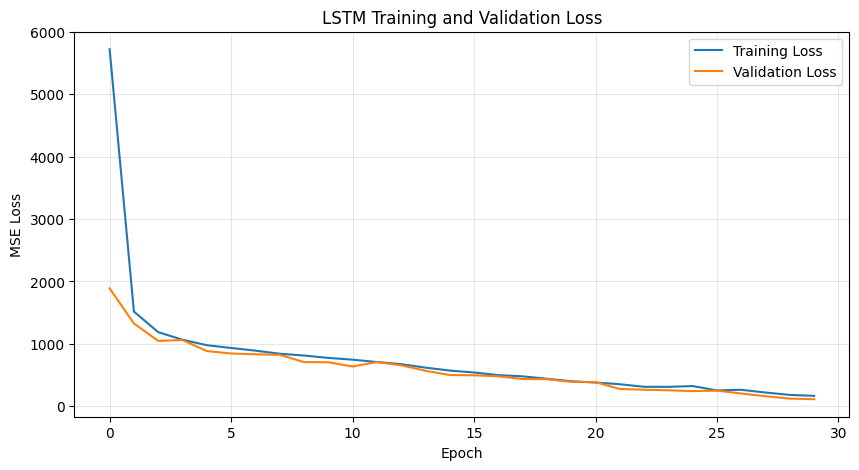

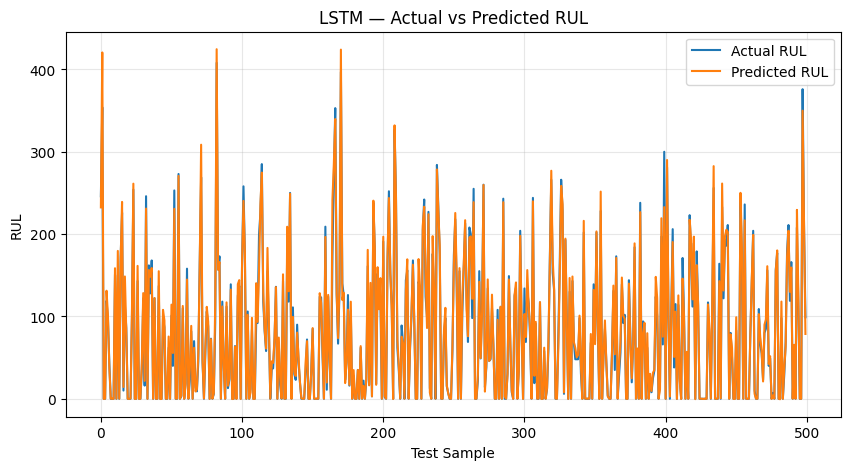

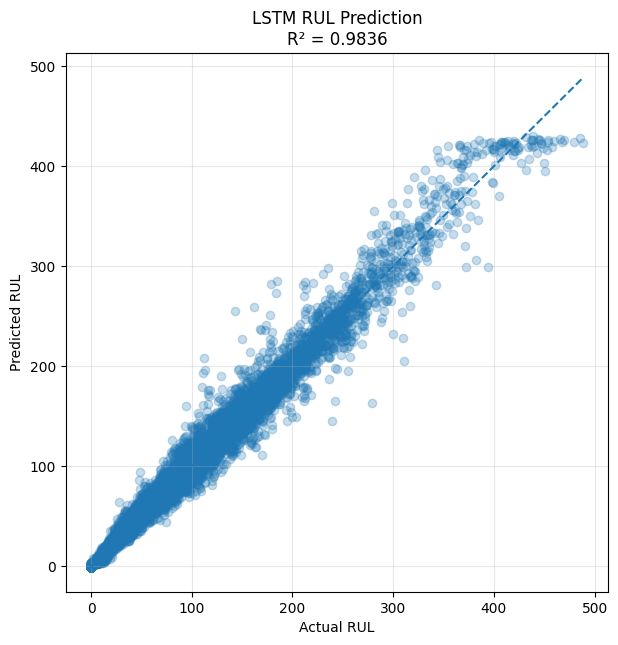


✅ PHASE 9A COMPLETED

LSTM Performance:
MAE  = 5.9349
RMSE = 10.8720
R²   = 0.9836

Saved files:
LSTM_RUL_MODEL.keras                     2.06 MB
lstm_actual_vs_predicted.png             0.28 MB
lstm_predictions.csv                     0.30 MB
lstm_results.csv                         0.00 MB
lstm_rul_scatter.png                     0.25 MB
lstm_training_curve.png                  0.08 MB
lstm_training_history.csv                0.00 MB

Memory cleanup completed.


In [ ]:
# ================================================================
# PHASE 9A — FAIR LSTM BASELINE FOR DANN COMPARISON
# ================================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 80)
print("PHASE 9A — FAIR LSTM BASELINE")
print("=" * 80)

# ================================================================
# PATHS
# ================================================================

BASE_DIR = "/kaggle/working"

X_PATH = (
    BASE_DIR +
    "/DANN_MULTIDOMAIN_SEQUENCES/X_sequences.npy"
)

Y_RUL_PATH = (
    BASE_DIR +
    "/DANN_MULTIDOMAIN_SEQUENCES/y_rul.npy"
)

OUTPUT_DIR = (
    BASE_DIR +
    "/LSTM_BASELINE"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ================================================================
# LOAD DATA
# ================================================================

print("\nLoading sequence data...")

X = np.load(X_PATH, mmap_mode="r")
y = np.load(Y_RUL_PATH)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of samples:", len(X))
print("Sequence length:", X.shape[1])
print("Number of features:", X.shape[2])

# ================================================================
# BASIC CHECK
# ================================================================

if len(X) != len(y):
    raise ValueError(
        f"X and y size mismatch: {len(X)} vs {len(y)}"
    )

# ================================================================
# CONVERT TARGET
# ================================================================

y = np.asarray(
    y,
    dtype=np.float32
).reshape(-1)

# Remove invalid target values
valid_mask = np.isfinite(y)

X_indices = np.where(valid_mask)[0]
y = y[valid_mask]

print("\nValid samples:", len(y))

# ================================================================
# FAIR TRAIN / TEST SPLIT
# ================================================================

print("\nCreating train/test split...")

indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(train_idx))
print("Testing samples :", len(test_idx))

# ================================================================
# LOAD ONLY REQUIRED DATA INTO RAM
# ================================================================

print("\nPreparing LSTM data...")

X_train = np.asarray(
    X[train_idx],
    dtype=np.float32
)

X_test = np.asarray(
    X[test_idx],
    dtype=np.float32
)

y_train = y[train_idx]
y_test = y[test_idx]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# ================================================================
# HANDLE NAN / INF
# ================================================================

X_train = np.nan_to_num(
    X_train,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

X_test = np.nan_to_num(
    X_test,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# ================================================================
# FEATURE STANDARDIZATION
# ================================================================
# Fit scaling ONLY on training data.
# This prevents test-data leakage.

print("\nStandardizing sensor features...")

feature_mean = np.mean(
    X_train,
    axis=(0, 1),
    keepdims=True
)

feature_std = np.std(
    X_train,
    axis=(0, 1),
    keepdims=True
)

feature_std[
    feature_std < 1e-8
] = 1.0

X_train = (
    X_train - feature_mean
) / feature_std

X_test = (
    X_test - feature_mean
) / feature_std

# Prevent extreme numerical values
X_train = np.clip(
    X_train,
    -10,
    10
)

X_test = np.clip(
    X_test,
    -10,
    10
)

print("Feature scaling completed.")

# ================================================================
# BUILD LSTM MODEL
# ================================================================

print("\n" + "=" * 80)
print("BUILDING LSTM MODEL")
print("=" * 80)

SEQUENCE_LENGTH = X_train.shape[1]
N_FEATURES = X_train.shape[2]

model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(
            SEQUENCE_LENGTH,
            N_FEATURES
        )
    ),

    tf.keras.layers.LSTM(
        128,
        return_sequences=True
    ),

    tf.keras.layers.Dropout(
        0.25
    ),

    tf.keras.layers.LSTM(
        64
    ),

    tf.keras.layers.Dropout(
        0.25
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="linear",
        name="rul_output"
    )
])

model.summary()

# ================================================================
# COMPILE
# ================================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        )
    ]
)

# ================================================================
# CALLBACKS
# ================================================================

checkpoint_path = (
    OUTPUT_DIR +
    "/LSTM_RUL_MODEL.keras"
)

callbacks = [

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=7,

        restore_best_weights=True,

        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=3,

        min_lr=1e-6,

        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(

        checkpoint_path,

        monitor="val_loss",

        save_best_only=True,

        verbose=1
    )
]

# ================================================================
# TRAIN
# ================================================================

print("\n" + "=" * 80)
print("TRAINING LSTM")
print("=" * 80)

history = model.fit(

    X_train,
    y_train,

    validation_split=0.15,

    epochs=30,

    batch_size=128,

    callbacks=callbacks,

    verbose=1
)

print("\n✅ LSTM TRAINING COMPLETED")

# ================================================================
# LOAD BEST MODEL
# ================================================================

model = tf.keras.models.load_model(
    checkpoint_path
)

print("\nBest LSTM model loaded.")

# ================================================================
# PREDICTION
# ================================================================

print("\n" + "=" * 80)
print("GENERATING LSTM PREDICTIONS")
print("=" * 80)

predictions = model.predict(
    X_test,
    batch_size=256,
    verbose=1
).reshape(-1)

# ================================================================
# SAFETY CHECK
# ================================================================

predictions = np.nan_to_num(
    predictions,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# ================================================================
# METRICS
# ================================================================

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\n" + "=" * 80)
print("LSTM RESULTS")
print("=" * 80)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# ================================================================
# SAVE PREDICTIONS
# ================================================================

prediction_df = pd.DataFrame({

    "Actual_RUL":
        y_test,

    "Predicted_RUL":
        predictions,

    "Absolute_Error":
        np.abs(
            y_test -
            predictions
        )

})

prediction_path = (
    OUTPUT_DIR +
    "/lstm_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

# ================================================================
# SAVE RESULTS
# ================================================================

results_df = pd.DataFrame([{

    "Model":
        "LSTM",

    "MAE":
        mae,

    "RMSE":
        rmse,

    "R2":
        r2

}])

results_path = (
    OUTPUT_DIR +
    "/lstm_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

# ================================================================
# SAVE TRAINING HISTORY
# ================================================================

history_df = pd.DataFrame(
    history.history
)

history_path = (
    OUTPUT_DIR +
    "/lstm_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

# ================================================================
# PLOT 1 — TRAINING CURVE
# ================================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "LSTM Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

training_plot = (
    OUTPUT_DIR +
    "/lstm_training_curve.png"
)

plt.savefig(
    training_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# PLOT 2 — ACTUAL VS PREDICTED
# ================================================================

plt.figure(
    figsize=(10, 5)
)

sample_count = min(
    500,
    len(y_test)
)

plt.plot(
    y_test[:sample_count],
    label="Actual RUL"
)

plt.plot(
    predictions[:sample_count],
    label="Predicted RUL"
)

plt.xlabel("Test Sample")
plt.ylabel("RUL")

plt.title(
    "LSTM — Actual vs Predicted RUL"
)

plt.legend()
plt.grid(alpha=0.3)

actual_pred_plot = (
    OUTPUT_DIR +
    "/lstm_actual_vs_predicted.png"
)

plt.savefig(
    actual_pred_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# PLOT 3 — SCATTER
# ================================================================

plt.figure(
    figsize=(7, 7)
)

plt.scatter(
    y_test,
    predictions,
    alpha=0.25
)

minimum = min(
    np.min(y_test),
    np.min(predictions)
)

maximum = max(
    np.max(y_test),
    np.max(predictions)
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual RUL"
)

plt.ylabel(
    "Predicted RUL"
)

plt.title(
    f"LSTM RUL Prediction\nR² = {r2:.4f}"
)

plt.grid(alpha=0.3)

scatter_plot = (
    OUTPUT_DIR +
    "/lstm_rul_scatter.png"
)

plt.savefig(
    scatter_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# FINAL OUTPUT
# ================================================================

print("\n" + "=" * 80)
print("✅ PHASE 9A COMPLETED")
print("=" * 80)

print("\nLSTM Performance:")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

print("\nSaved files:")

for file in sorted(
    os.listdir(OUTPUT_DIR)
):

    path = os.path.join(
        OUTPUT_DIR,
        file
    )

    size_mb = (
        os.path.getsize(path)
        / (1024 ** 2)
    )

    print(
        f"{file:40s} "
        f"{size_mb:.2f} MB"
    )

# ================================================================
# CLEAN MEMORY
# ================================================================

del X_train
del X_test

gc.collect()

print("\nMemory cleanup completed.")

PHASE 9B — FAIR GRU BASELINE

Loading sequence data...
X shape: (60891, 30, 115)
y shape: (60891,)
Sequence length: 30
Features: 115

Valid samples: 60891

Creating train/test split...
Training samples: 48712
Testing samples: 12179

Preparing GRU data...
X_train: (48712, 30, 115)
X_test: (12179, 30, 115)

Standardizing sensor features...
Standardization completed.

BUILDING GRU MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 128)        │        94,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,441 (521.25 KB)

 Trainable params: 133,441 (521.25 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING GRU
Epoch 1/30
320/324 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7881.4349 - mae: 52.4259
Epoch 1: val_loss improved from None to 1830.97302, saving model to /kaggle/working/GRU_BASELINE/GRU_RUL_MODEL.keras

Epoch 1: finished saving model to /kaggle/working/GRU_BASELINE/GRU_RUL_MODEL.keras
324/324 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5032.2451 - mae: 38.0217 - val_loss: 1830.9730 - val_mae: 22.0069 - learning_rate: 0.0010
Epoch 2/30
322/324 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1643.1905 - mae: 21.2929
Epoch 2: val_loss improved from 1830.97302 to 1229.62390, saving model to /kaggle/working/GRU_BASELINE/GRU_RUL_MODEL.keras

Epoch 2: finished saving model to /kaggle/working/GRU_BASELINE/GRU_RUL_MODEL.keras
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1462.3464 - mae: 20.4099 - val_loss: 1229.6239 - val_mae: 17.5387 - learning_rate: 0.0010
Epoch 3/30
323/324 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1218.3768 - mae: 18.9217
Epoch 3: val_loss improved from 1229.62390 t

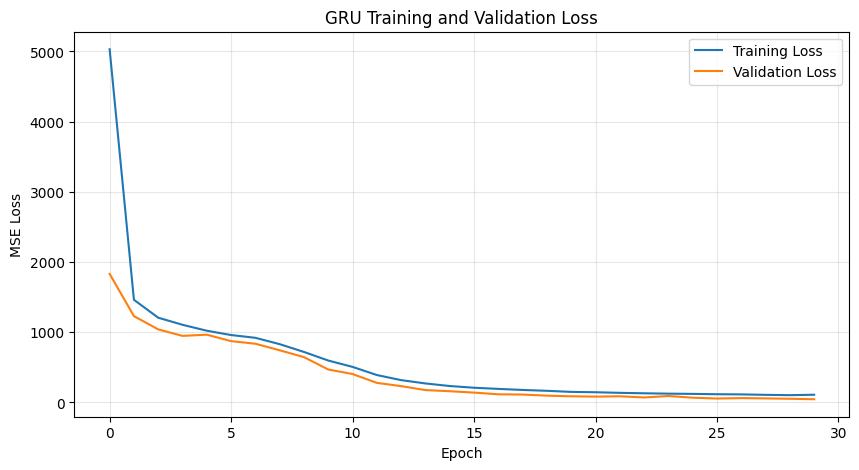

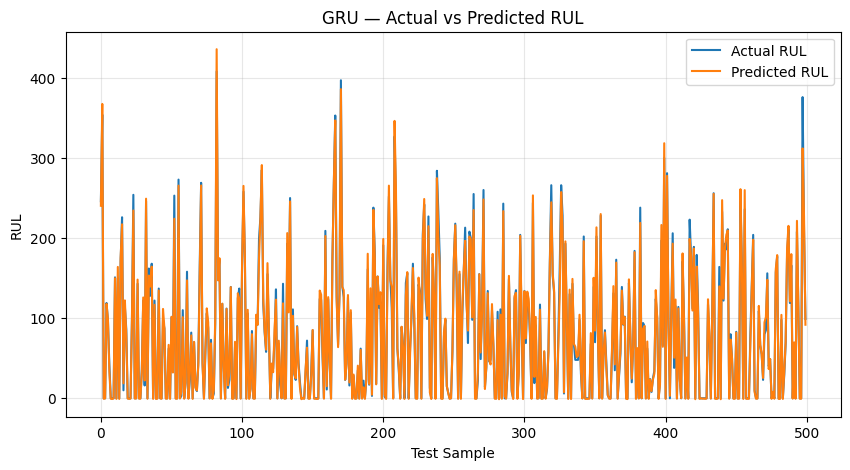

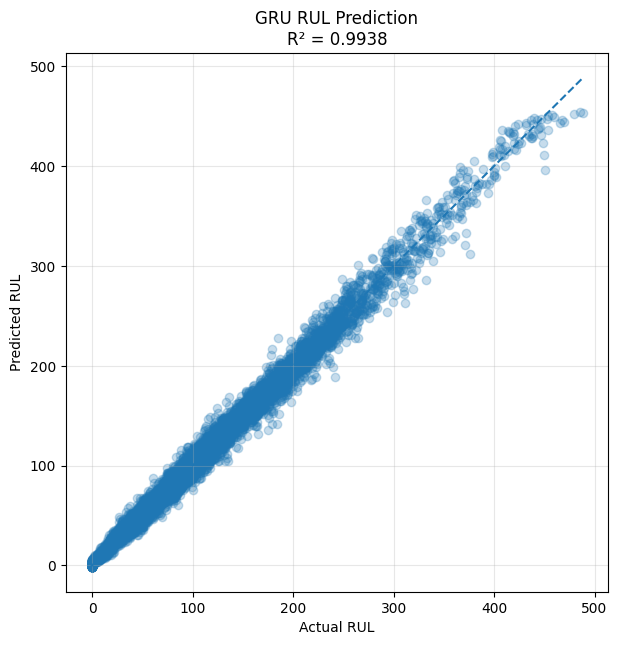

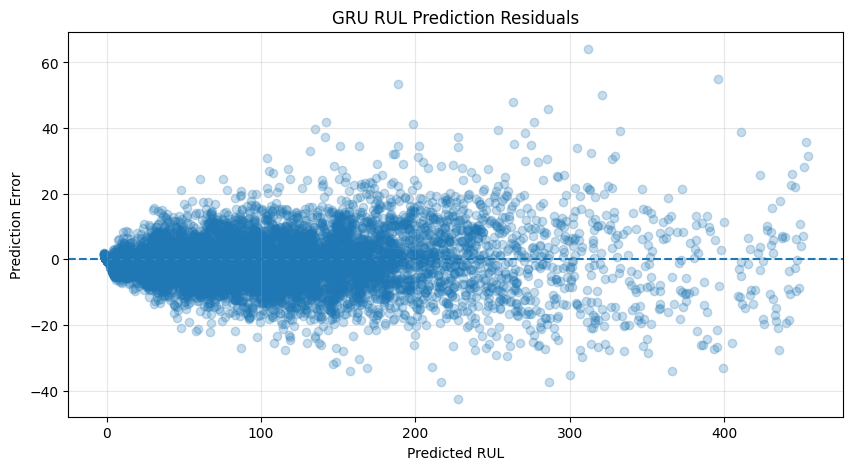


✅ PHASE 9B COMPLETED

GRU Performance:
MAE  = 4.0662
RMSE = 6.6832
R²   = 0.9938

Saved files:
GRU_RUL_MODEL.keras                     1.57 MB
gru_actual_vs_predicted.png             0.27 MB
gru_predictions.csv                     0.29 MB
gru_residual_plot.png                   0.41 MB
gru_results.csv                         0.00 MB
gru_rul_scatter.png                     0.20 MB
gru_training_curve.png                  0.08 MB
gru_training_history.csv                0.00 MB

Memory cleanup completed.


In [ ]:
# ================================================================
# PHASE 9B — FAIR GRU BASELINE
# ================================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 80)
print("PHASE 9B — FAIR GRU BASELINE")
print("=" * 80)

# ================================================================
# PATHS
# ================================================================

BASE_DIR = "/kaggle/working"

X_PATH = (
    BASE_DIR +
    "/DANN_MULTIDOMAIN_SEQUENCES/X_sequences.npy"
)

Y_RUL_PATH = (
    BASE_DIR +
    "/DANN_MULTIDOMAIN_SEQUENCES/y_rul.npy"
)

OUTPUT_DIR = (
    BASE_DIR +
    "/GRU_BASELINE"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ================================================================
# LOAD DATA
# ================================================================

print("\nLoading sequence data...")

X = np.load(
    X_PATH,
    mmap_mode="r"
)

y = np.load(
    Y_RUL_PATH
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print(
    "Sequence length:",
    X.shape[1]
)

print(
    "Features:",
    X.shape[2]
)

# ================================================================
# CHECK DATA
# ================================================================

if len(X) != len(y):

    raise ValueError(
        f"X/y mismatch: "
        f"{len(X)} vs {len(y)}"
    )

# ================================================================
# CLEAN TARGET
# ================================================================

y = np.asarray(
    y,
    dtype=np.float32
).reshape(-1)

valid_mask = np.isfinite(y)

valid_indices = np.where(
    valid_mask
)[0]

y = y[valid_mask]

print(
    "\nValid samples:",
    len(y)
)

# ================================================================
# SAME TRAIN / TEST SPLIT
# ================================================================

print("\nCreating train/test split...")

indices = np.arange(
    len(y)
)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42
)

print(
    "Training samples:",
    len(train_idx)
)

print(
    "Testing samples:",
    len(test_idx)
)

# ================================================================
# LOAD DATA
# ================================================================

print("\nPreparing GRU data...")

X_train = np.asarray(
    X[train_idx],
    dtype=np.float32
)

X_test = np.asarray(
    X[test_idx],
    dtype=np.float32
)

y_train = y[train_idx]
y_test = y[test_idx]

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

# ================================================================
# CLEAN SENSOR DATA
# ================================================================

X_train = np.nan_to_num(
    X_train,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

X_test = np.nan_to_num(
    X_test,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# ================================================================
# STANDARDIZATION
# ================================================================
# IMPORTANT:
# Fit ONLY on training data.

print(
    "\nStandardizing sensor features..."
)

feature_mean = np.mean(
    X_train,
    axis=(0, 1),
    keepdims=True
)

feature_std = np.std(
    X_train,
    axis=(0, 1),
    keepdims=True
)

feature_std[
    feature_std < 1e-8
] = 1.0

X_train = (
    X_train -
    feature_mean
) / feature_std

X_test = (
    X_test -
    feature_mean
) / feature_std

# Prevent numerical instability

X_train = np.clip(
    X_train,
    -10,
    10
)

X_test = np.clip(
    X_test,
    -10,
    10
)

print(
    "Standardization completed."
)

# ================================================================
# BUILD GRU MODEL
# ================================================================

print("\n" + "=" * 80)
print("BUILDING GRU MODEL")
print("=" * 80)

SEQUENCE_LENGTH = X_train.shape[1]

N_FEATURES = X_train.shape[2]

model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(
            SEQUENCE_LENGTH,
            N_FEATURES
        )
    ),

    # ------------------------------------------------------------
    # GRU LAYER 1
    # ------------------------------------------------------------

    tf.keras.layers.GRU(
        128,
        return_sequences=True
    ),

    tf.keras.layers.Dropout(
        0.25
    ),

    # ------------------------------------------------------------
    # GRU LAYER 2
    # ------------------------------------------------------------

    tf.keras.layers.GRU(
        64,
        return_sequences=False
    ),

    tf.keras.layers.Dropout(
        0.25
    ),

    # ------------------------------------------------------------
    # DENSE
    # ------------------------------------------------------------

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    # ------------------------------------------------------------
    # RUL OUTPUT
    # ------------------------------------------------------------

    tf.keras.layers.Dense(
        1,
        activation="linear",
        name="rul_output"
    )
])

model.summary()

# ================================================================
# COMPILE
# ================================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        )
    ]
)

# ================================================================
# CALLBACKS
# ================================================================

checkpoint_path = (
    OUTPUT_DIR +
    "/GRU_RUL_MODEL.keras"
)

callbacks = [

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=7,

        restore_best_weights=True,

        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=3,

        min_lr=1e-6,

        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(

        checkpoint_path,

        monitor="val_loss",

        save_best_only=True,

        verbose=1
    )
]

# ================================================================
# TRAIN
# ================================================================

print("\n" + "=" * 80)
print("TRAINING GRU")
print("=" * 80)

history = model.fit(

    X_train,

    y_train,

    validation_split=0.15,

    epochs=30,

    batch_size=128,

    callbacks=callbacks,

    verbose=1
)

print(
    "\n✅ GRU TRAINING COMPLETED"
)

# ================================================================
# LOAD BEST MODEL
# ================================================================

model = tf.keras.models.load_model(
    checkpoint_path
)

print(
    "Best GRU model loaded."
)

# ================================================================
# PREDICTION
# ================================================================

print("\n" + "=" * 80)
print("GENERATING GRU PREDICTIONS")
print("=" * 80)

predictions = model.predict(
    X_test,
    batch_size=256,
    verbose=1
).reshape(-1)

# ================================================================
# CLEAN PREDICTIONS
# ================================================================

predictions = np.nan_to_num(
    predictions,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# ================================================================
# METRICS
# ================================================================

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

# ================================================================
# RESULTS
# ================================================================

print("\n" + "=" * 80)
print("GRU RESULTS")
print("=" * 80)

print(
    f"MAE  : {mae:.4f}"
)

print(
    f"RMSE : {rmse:.4f}"
)

print(
    f"R²   : {r2:.4f}"
)

# ================================================================
# SAVE PREDICTIONS
# ================================================================

prediction_df = pd.DataFrame({

    "Actual_RUL":
        y_test,

    "Predicted_RUL":
        predictions,

    "Absolute_Error":
        np.abs(
            y_test -
            predictions
        )

})

prediction_path = (
    OUTPUT_DIR +
    "/gru_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

# ================================================================
# SAVE RESULTS
# ================================================================

results_df = pd.DataFrame([{

    "Model":
        "GRU",

    "MAE":
        mae,

    "RMSE":
        rmse,

    "R2":
        r2

}])

results_path = (
    OUTPUT_DIR +
    "/gru_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

# ================================================================
# SAVE TRAINING HISTORY
# ================================================================

history_df = pd.DataFrame(
    history.history
)

history_path = (
    OUTPUT_DIR +
    "/gru_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

# ================================================================
# PLOT 1 — TRAINING CURVE
# ================================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "GRU Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

training_plot = (
    OUTPUT_DIR +
    "/gru_training_curve.png"
)

plt.savefig(
    training_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# PLOT 2 — ACTUAL VS PREDICTED RUL
# ================================================================

plt.figure(
    figsize=(10, 5)
)

sample_count = min(
    500,
    len(y_test)
)

plt.plot(
    y_test[:sample_count],
    label="Actual RUL"
)

plt.plot(
    predictions[:sample_count],
    label="Predicted RUL"
)

plt.xlabel(
    "Test Sample"
)

plt.ylabel(
    "RUL"
)

plt.title(
    "GRU — Actual vs Predicted RUL"
)

plt.legend()

plt.grid(
    alpha=0.3
)

actual_pred_plot = (
    OUTPUT_DIR +
    "/gru_actual_vs_predicted.png"
)

plt.savefig(
    actual_pred_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# PLOT 3 — RUL SCATTER
# ================================================================

plt.figure(
    figsize=(7, 7)
)

plt.scatter(
    y_test,
    predictions,
    alpha=0.25
)

minimum = min(
    np.min(y_test),
    np.min(predictions)
)

maximum = max(
    np.max(y_test),
    np.max(predictions)
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual RUL"
)

plt.ylabel(
    "Predicted RUL"
)

plt.title(
    f"GRU RUL Prediction\nR² = {r2:.4f}"
)

plt.grid(
    alpha=0.3
)

scatter_plot = (
    OUTPUT_DIR +
    "/gru_rul_scatter.png"
)

plt.savefig(
    scatter_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# PLOT 4 — RESIDUAL ERROR
# ================================================================

errors = (
    y_test -
    predictions
)

plt.figure(
    figsize=(10, 5)
)

plt.scatter(
    predictions,
    errors,
    alpha=0.25
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted RUL"
)

plt.ylabel(
    "Prediction Error"
)

plt.title(
    "GRU RUL Prediction Residuals"
)

plt.grid(
    alpha=0.3
)

residual_plot = (
    OUTPUT_DIR +
    "/gru_residual_plot.png"
)

plt.savefig(
    residual_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# FINAL SUMMARY
# ================================================================

print("\n" + "=" * 80)
print("✅ PHASE 9B COMPLETED")
print("=" * 80)

print(
    "\nGRU Performance:"
)

print(
    f"MAE  = {mae:.4f}"
)

print(
    f"RMSE = {rmse:.4f}"
)

print(
    f"R²   = {r2:.4f}"
)

print(
    "\nSaved files:"
)

for file in sorted(
    os.listdir(
        OUTPUT_DIR
    )
):

    path = os.path.join(
        OUTPUT_DIR,
        file
    )

    size_mb = (
        os.path.getsize(path)
        / (1024 ** 2)
    )

    print(
        f"{file:40s}"
        f"{size_mb:.2f} MB"
    )

# ================================================================
# MEMORY CLEANUP
# ================================================================

del X_train
del X_test

gc.collect()

print(
    "\nMemory cleanup completed."
)

MODEL PERFORMANCE COMPARISON
Model     MAE    RMSE     R2
 DANN 15.4619 30.2752 0.8752
 LSTM  5.9349 10.8720 0.9836
  GRU  4.0662  6.6832 0.9938

Comparison table saved:
/kaggle/working/MODEL_COMPARISON/model_comparison.csv


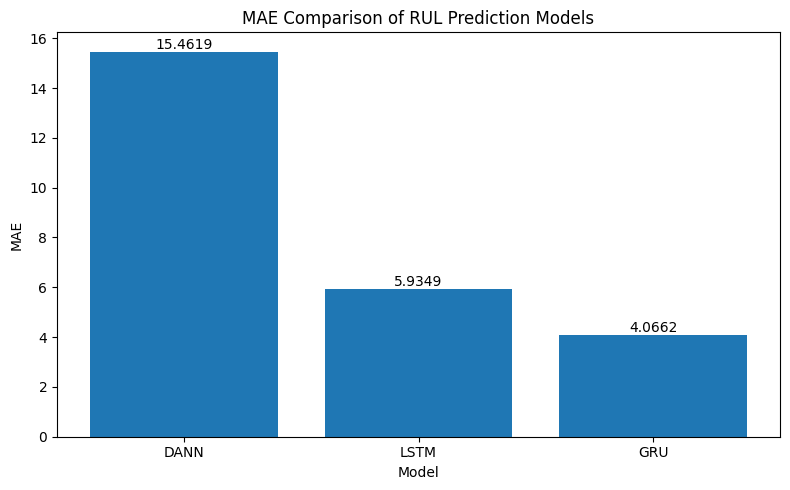

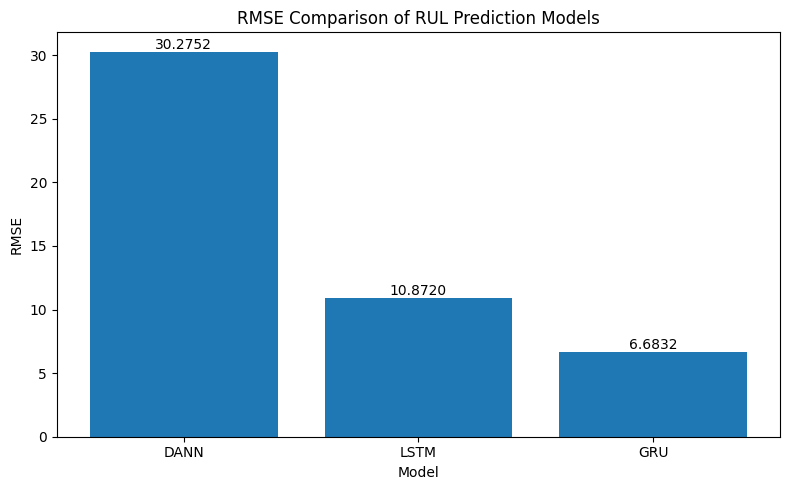

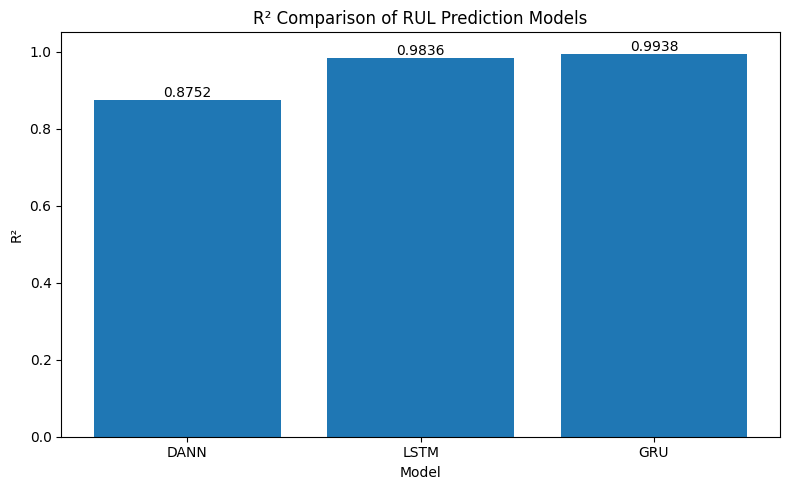

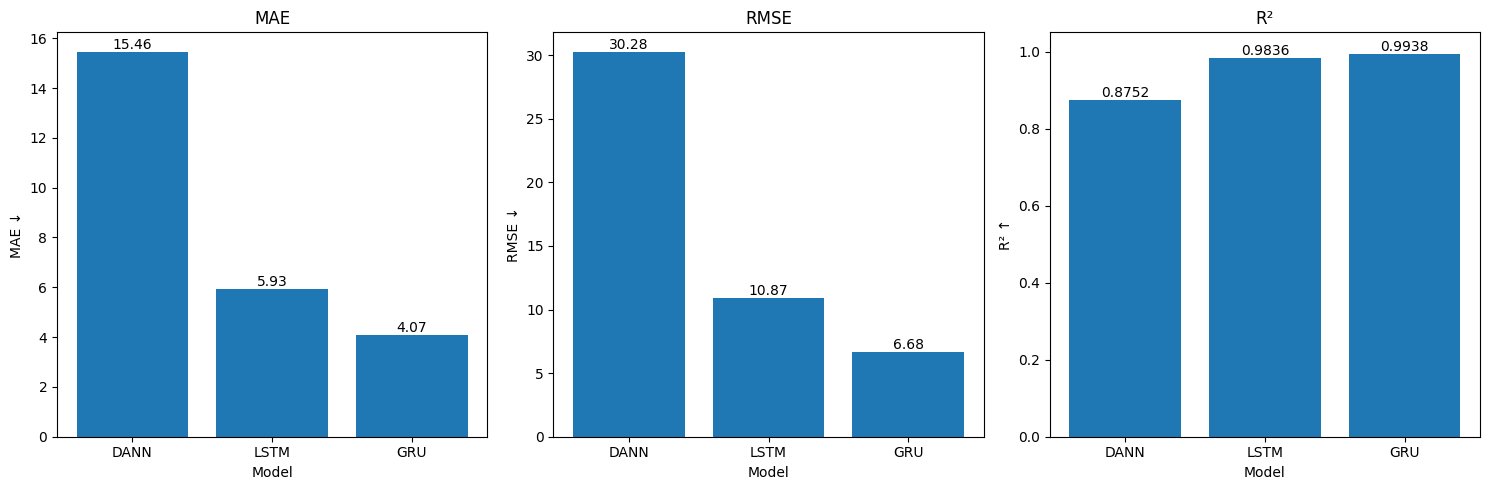


✅ MODEL COMPARISON COMPLETED

Generated files:
/kaggle/working/MODEL_COMPARISON/mae_comparison.png
/kaggle/working/MODEL_COMPARISON/r2_comparison.png
/kaggle/working/MODEL_COMPARISON/model_comparison.csv
/kaggle/working/MODEL_COMPARISON/rmse_comparison.png
/kaggle/working/MODEL_COMPARISON/complete_model_comparison.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "DANN",
        "LSTM",
        "GRU"
    ],
    "MAE": [
        15.4619,
        5.9349,
        4.0662
    ],
    "RMSE": [
        30.2752,
        10.8720,
        6.6832
    ],
    "R2": [
        0.8752,
        0.9836,
        0.9938
    ]
})

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

print(comparison.to_string(index=False))

# ============================================================
# SAVE COMPARISON TABLE
# ============================================================

OUTPUT_DIR = "/kaggle/working/MODEL_COMPARISON"

os.makedirs(OUTPUT_DIR, exist_ok=True)

comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_comparison.csv"
    ),
    index=False
)

print("\nComparison table saved:")
print(
    os.path.join(
        OUTPUT_DIR,
        "model_comparison.csv"
    )
)

# ============================================================
# MAE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("MAE Comparison of RUL Prediction Models")

for i, value in enumerate(comparison["MAE"]):
    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "mae_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# RMSE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of RUL Prediction Models")

for i, value in enumerate(comparison["RMSE"]):
    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "rmse_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# R2 COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.xlabel("Model")
plt.ylabel("R²")
plt.title("R² Comparison of RUL Prediction Models")

for i, value in enumerate(comparison["R2"]):
    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1.05)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "r2_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# COMBINED COMPARISON GRAPH
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# MAE
axes[0].bar(
    comparison["Model"],
    comparison["MAE"]
)

axes[0].set_title("MAE")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("MAE ↓")

for i, value in enumerate(comparison["MAE"]):
    axes[0].text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


# RMSE
axes[1].bar(
    comparison["Model"],
    comparison["RMSE"]
)

axes[1].set_title("RMSE")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("RMSE ↓")

for i, value in enumerate(comparison["RMSE"]):
    axes[1].text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


# R2
axes[2].bar(
    comparison["Model"],
    comparison["R2"]
)

axes[2].set_title("R²")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("R² ↑")
axes[2].set_ylim(0, 1.05)

for i, value in enumerate(comparison["R2"]):
    axes[2].text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "complete_model_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 80)
print("✅ MODEL COMPARISON COMPLETED")
print("=" * 80)

print("\nGenerated files:")

for file in os.listdir(OUTPUT_DIR):
    print(
        os.path.join(
            OUTPUT_DIR,
            file
        )
    )

BASELINE PARAMETER COMPARISON
            Parameter       LSTM        GRU                  DANN
           Model Type       LSTM        GRU                  DANN
Input Sequence Length YOUR_VALUE YOUR_VALUE            YOUR_VALUE
         Hidden Units YOUR_VALUE YOUR_VALUE            YOUR_VALUE
     Recurrent Layers YOUR_VALUE YOUR_VALUE            YOUR_VALUE
              Dropout YOUR_VALUE YOUR_VALUE            YOUR_VALUE
         Dense Layers YOUR_VALUE YOUR_VALUE            YOUR_VALUE
            Optimizer       Adam       Adam                  Adam
        Learning Rate      0.001      0.001                 0.001
           Batch Size YOUR_VALUE YOUR_VALUE            YOUR_VALUE
               Epochs         30         30                    30
               Output        RUL        RUL RUL + Health + Domain


PERFORMANCE COMPARISON
Model     MAE    RMSE     R2
 LSTM  5.9349 10.8720 0.9836
  GRU  4.0662  6.6832 0.9938
 DANN 15.4619 30.2752 0.8752


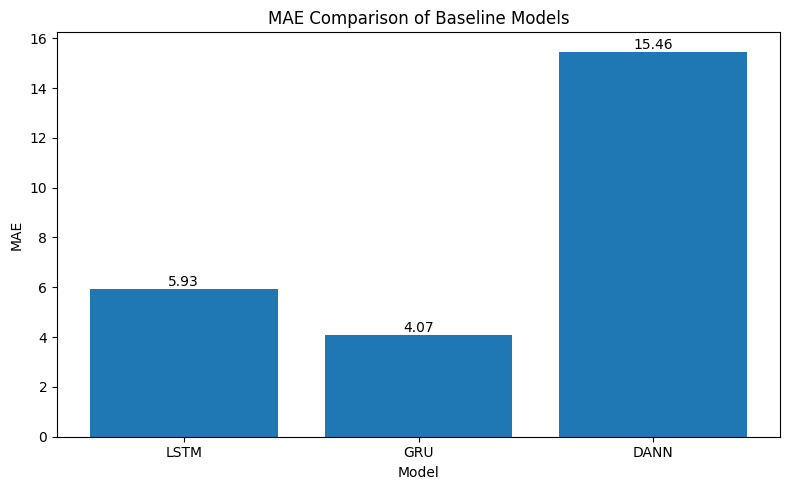

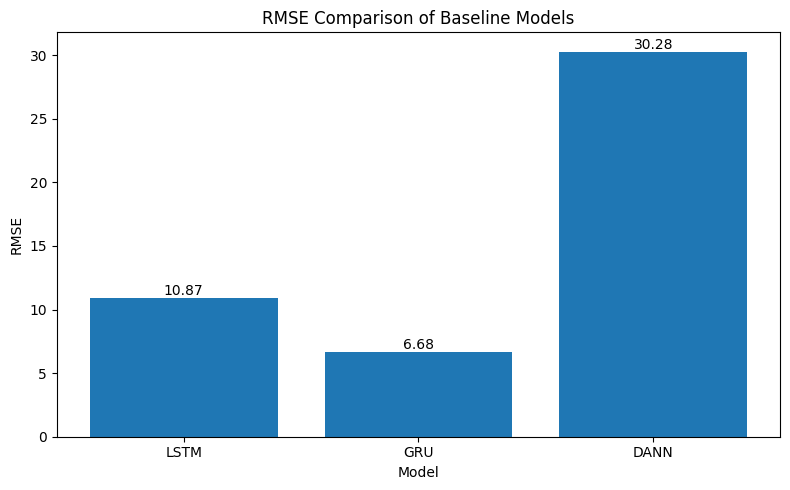

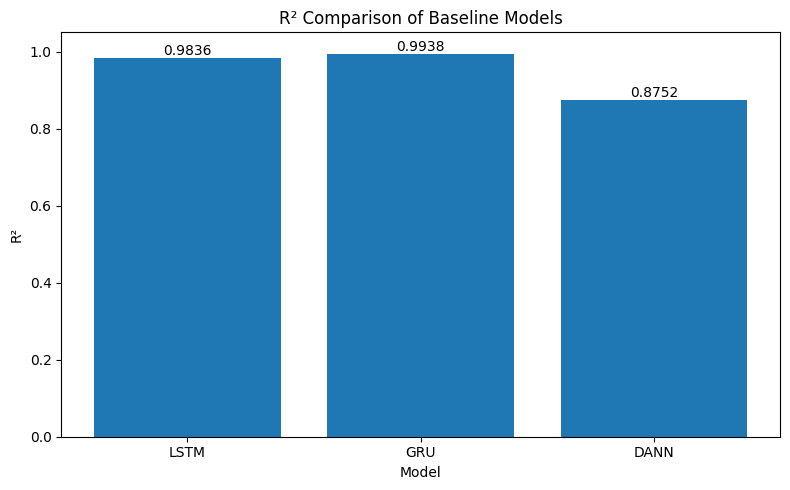

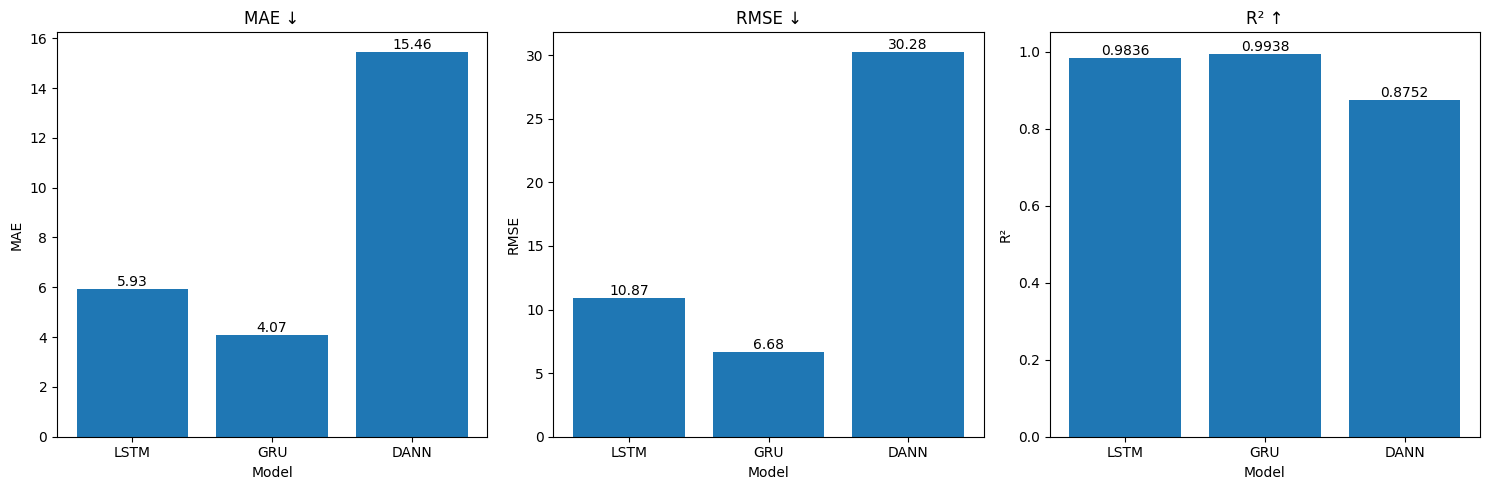



FILES GENERATED
/kaggle/working/BASELINE_COMPARISON/baseline_MAE_comparison.png
/kaggle/working/BASELINE_COMPARISON/baseline_parameter_comparison.csv
/kaggle/working/BASELINE_COMPARISON/baseline_R2_comparison.png
/kaggle/working/BASELINE_COMPARISON/complete_baseline_comparison.png
/kaggle/working/BASELINE_COMPARISON/baseline_RMSE_comparison.png
/kaggle/working/BASELINE_COMPARISON/baseline_performance_comparison.csv

✅ BASELINE COMPARISON COMPLETED


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "/kaggle/working/BASELINE_COMPARISON"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# BASELINE PARAMETER COMPARISON
# ============================================================

baseline_params = pd.DataFrame({

    "Parameter": [
        "Model Type",
        "Input Sequence Length",
        "Hidden Units",
        "Recurrent Layers",
        "Dropout",
        "Dense Layers",
        "Optimizer",
        "Learning Rate",
        "Batch Size",
        "Epochs",
        "Output"
    ],

    "LSTM": [
        "LSTM",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "Adam",
        "0.001",
        "YOUR_VALUE",
        "30",
        "RUL"
    ],

    "GRU": [
        "GRU",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "Adam",
        "0.001",
        "YOUR_VALUE",
        "30",
        "RUL"
    ],

    "DANN": [
        "DANN",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "YOUR_VALUE",
        "Adam",
        "0.001",
        "YOUR_VALUE",
        "30",
        "RUL + Health + Domain"
    ]
})


print("=" * 80)
print("BASELINE PARAMETER COMPARISON")
print("=" * 80)

print(baseline_params.to_string(index=False))


# Save parameter table

baseline_params.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "baseline_parameter_comparison.csv"
    ),
    index=False
)


# ============================================================
# PERFORMANCE TABLE
# ============================================================

performance = pd.DataFrame({

    "Model": [
        "LSTM",
        "GRU",
        "DANN"
    ],

    "MAE": [
        5.9349,
        4.0662,
        15.4619
    ],

    "RMSE": [
        10.8720,
        6.6832,
        30.2752
    ],

    "R2": [
        0.9836,
        0.9938,
        0.8752
    ]
})


print("\n")
print("=" * 80)
print("PERFORMANCE COMPARISON")
print("=" * 80)

print(performance.to_string(index=False))


performance.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "baseline_performance_comparison.csv"
    ),
    index=False
)


# ============================================================
# GRAPH 1 — MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    performance["Model"],
    performance["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("MAE Comparison of Baseline Models")

for i, value in enumerate(performance["MAE"]):

    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "baseline_MAE_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GRAPH 2 — RMSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    performance["Model"],
    performance["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Baseline Models")

for i, value in enumerate(performance["RMSE"]):

    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "baseline_RMSE_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GRAPH 3 — R²
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    performance["Model"],
    performance["R2"]
)

plt.xlabel("Model")
plt.ylabel("R²")
plt.title("R² Comparison of Baseline Models")

for i, value in enumerate(performance["R2"]):

    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1.05)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "baseline_R2_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GRAPH 4 — COMBINED PERFORMANCE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


# MAE

axes[0].bar(
    performance["Model"],
    performance["MAE"]
)

axes[0].set_title("MAE ↓")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("MAE")

for i, value in enumerate(performance["MAE"]):

    axes[0].text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


# RMSE

axes[1].bar(
    performance["Model"],
    performance["RMSE"]
)

axes[1].set_title("RMSE ↓")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("RMSE")

for i, value in enumerate(performance["RMSE"]):

    axes[1].text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


# R²

axes[2].bar(
    performance["Model"],
    performance["R2"]
)

axes[2].set_title("R² ↑")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("R²")

axes[2].set_ylim(0, 1.05)

for i, value in enumerate(performance["R2"]):

    axes[2].text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "complete_baseline_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL
# ============================================================

print("\n")
print("=" * 80)
print("FILES GENERATED")
print("=" * 80)

for file in os.listdir(OUTPUT_DIR):

    print(
        os.path.join(
            OUTPUT_DIR,
            file
        )
    )

print("\n✅ BASELINE COMPARISON COMPLETED")